# BERT Source Domain Diagnosis (v6) Dataset v9

## Objective

1. **Confirm residualization procedure**: fit on train only, apply to test (no leakage)
2. **LOSO on residualized features**
3. **Counterfactual consistency metric**
4. **Consolidated final table**:
   - 4.1 Source classifier: original vs residualized
   - 4.2 Bias classifier: original vs residualized
   - 4.3 LOSO by source (original + residualized)
   - 4.4 Baseline source-only (predict bias from source majority class) on v9

## 1. Setup and Imports

In [1]:
import subprocess
import sys

try:
    import xgboost  # noqa: F401
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost'])

In [2]:
import json
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GroupShuffleSplit,
    HalvingRandomSearchCV,
    StratifiedGroupKFold,
    cross_validate,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier


def find_root(start: Path, repo_name: str = 'attention-atlas') -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if candidate.name == repo_name:
            return candidate
    return start


_nb_file = Path(globals().get('__vsc_ipynb_file__', '') or '')
if _nb_file.exists():
    root_dir = find_root(_nb_file.parent)
else:
    root_dir = find_root(Path.cwd())
notebook_dir = root_dir / 'dataset'

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f'Root dir: {root_dir}')
print(f'Notebook dir: {notebook_dir}')

Root dir: C:\Users\anoca\Documents\GitHub\attention-atlas
Notebook dir: C:\Users\anoca\Documents\GitHub\attention-atlas\dataset


## 2. Load Dataset v9

In [3]:
dataset_path = notebook_dir / 'bias_sentences_v9.json'
with open(dataset_path, encoding='utf-8') as f:
    raw = json.load(f)

df_sentences = pd.DataFrame(raw['entries'])
df_sentences['label'] = df_sentences['has_bias'].astype(int)

SOURCE_CANONICAL = {
    'biased_corpus_only': 'biased-corpus',
    'biased_corpus_v2': 'biased-corpus',
    'gemini_only': 'gemini',
    'gemini_only_v2': 'gemini',
    'gus_only': 'gus-dataset',
    'gus_only_v2': 'gus-dataset',
}
df_sentences['source_canonical'] = (
    df_sentences['source'].map(SOURCE_CANONICAL).fillna(df_sentences['source'])
)

print(f'Dataset v9: {len(df_sentences)} entries')
print(f'Unique texts: {df_sentences["text"].nunique()} / {len(df_sentences)}')
print(f'Label distribution: {df_sentences["label"].value_counts().sort_index().to_dict()}')
print(f'Sources (canonical): {df_sentences["source_canonical"].value_counts().to_dict()}')
print(f'Roles: {df_sentences["role"].value_counts().to_dict()}')

Dataset v9: 10304 entries
Unique texts: 10304 / 10304
Label distribution: {0: 4807, 1: 5497}
Sources (canonical): {'gemini': 4440, 'biased-corpus': 3235, 'gus-dataset': 2629}
Roles: {'original': 6457, 'counterfactual': 3847}


In [4]:
# Cross-source text overlap
source_groups = df_sentences.groupby('source')['text'].apply(set)
source_names = list(source_groups.index)

print('Cross-source text overlap (should be 0):')
for i in range(len(source_names)):
    for j in range(i + 1, len(source_names)):
        overlap = source_groups[source_names[i]] & source_groups[source_names[j]]
        print(f'  {source_names[i]} vs {source_names[j]}: {len(overlap)}')

print('\nBias by source:')
print(pd.crosstab(df_sentences['source_canonical'], df_sentences['label'], margins=True))

print('\nRole distribution:')
print(pd.crosstab(df_sentences['source_canonical'], df_sentences['role'], margins=True))

Cross-source text overlap (should be 0):
  biased_corpus_only vs gemini_only: 0
  biased_corpus_only vs gus_only: 0
  gemini_only vs gus_only: 0

Bias by source:
label                0     1    All
source_canonical                   
biased-corpus     1169  2066   3235
gemini            2277  2163   4440
gus-dataset       1361  1268   2629
All               4807  5497  10304

Role distribution:
role              counterfactual  original    All
source_canonical                                 
biased-corpus                956      2279   3235
gemini                      2158      2282   4440
gus-dataset                  733      1896   2629
All                         3847      6457  10304


## 3. Load Feature Matrix

In [5]:
features_path = (
    root_dir / 'attention_app' / 'bias' / 'extracted_features'
    / 'feature_matrix_bert_v9.pkl'
)
if not features_path.exists():
    raise FileNotFoundError(
        f'Feature matrix not found: {features_path}\n'
        'Run the extraction script first.'
    )

df_features = pd.read_pickle(features_path).copy()
print(f'Feature matrix shape: {df_features.shape[0]} samples x {df_features.shape[1]} columns')

if len(df_features) != len(df_sentences):
    raise RuntimeError(
        f'Size mismatch: feature matrix has {len(df_features)} rows but '
        f'JSON dataset has {len(df_sentences)} rows.'
    )

label_match = np.array_equal(
    df_features['label'].astype(int).values, df_sentences['label'].values
)
print(f'Label alignment with JSON dataset: {label_match}')
if not label_match:
    raise RuntimeError('Feature matrix labels do not align with JSON dataset labels.')

for col in [
    'text', 'source', 'source_canonical', 'original_id',
    'role', 'topic', 'pair_id', 'sentence_id', 'edit_type',
]:
    if col in df_sentences.columns:
        df_features[col] = df_sentences[col].values

print(f'Source distribution: {df_features["source_canonical"].value_counts().to_dict()}')

Feature matrix shape: 10304 samples x 3239 columns
Label alignment with JSON dataset: True
Source distribution: {'gemini': 4440, 'biased-corpus': 3235, 'gus-dataset': 2629}


## 4. Prepare Data

In [6]:
drop_cols = [
    'label', 'id', 'text', 'source', 'source_canonical', 'original_id', 'role',
    'topic', 'pair_id', 'sentence_id', 'type', 'validated_source', 'hasbias',
    'has_bias', 'bias_type', 'bias_description', 'edit_spans', 'edit_type',
]
X = df_features.drop(columns=[c for c in drop_cols if c in df_features.columns])
y = df_features['label'].astype(int)
sources = df_features['source_canonical'].values

group_col = df_features['pair_id'].copy()
mask_no_pair = group_col.isna()
group_col[mask_no_pair] = [
    'unpaired_' + str(i) for i in range(mask_no_pair.sum())
]
groups = group_col.values

print(f'Total features: {X.shape[1]}')
print(f'Total samples:  {X.shape[0]}')
print(f'Unique groups:  {len(set(groups))}')
print(f'Label distribution: biased={int(y.sum())}, neutral={int((y == 0).sum())}')

print('\nSource distribution:')
for src, cnt in Counter(sources).most_common():
    src_labels = y[sources == src]
    print(
        f'  {src:18} {cnt:5d} '
        f'(biased={int(src_labels.sum())}, neutral={int((src_labels == 0).sum())})'
    )

print(f'\nRole distribution: {df_features["role"].value_counts().to_dict()}')

X_final = X.copy()
unique_sources = np.array(sorted(np.unique(sources)))

Total features: 3238
Total samples:  10304
Unique groups:  6460
Label distribution: biased=5497, neutral=4807

Source distribution:
  gemini              4440 (biased=2163, neutral=2277)
  biased-corpus       3235 (biased=2066, neutral=1169)
  gus-dataset         2629 (biased=1268, neutral=1361)

Role distribution: {'original': 6457, 'counterfactual': 3847}


## 4.4. Baseline: Source-Only Prediction on v9

Compute how well one can predict `has_bias` using only the majority class per source.
This is the theoretical ceiling for a source-confounding artefact.

In [7]:
print('Source-Only Baseline (v9) ')
print('Predict bias label using the majority class of each source.\n')

source_majority = {}
for src in unique_sources:
    src_mask = sources == src
    src_labels = y[src_mask]
    majority = int(src_labels.mode().iloc[0])
    source_majority[src] = majority
    n_correct = int((src_labels == majority).sum())
    n_total = int(src_mask.sum())
    print(
        f'  {src:18} majority={majority}  '
        f'correct={n_correct}/{n_total} ({n_correct/n_total:.1%})'
    )

# Overall source-only accuracy
y_source_baseline = pd.Series(sources).map(source_majority).astype(int).values
source_only_acc = accuracy_score(y, y_source_baseline)
source_only_f1 = f1_score(y, y_source_baseline, zero_division=0)
source_only_auc = roc_auc_score(y, y_source_baseline)

print(f'\nOverall source-only baseline:')
print(f'  Accuracy: {source_only_acc:.4f}')
print(f'  F1:       {source_only_f1:.4f}')
print(f'  AUC:      {source_only_auc:.4f}')
print(f'\nInterpretation: if the model cannot beat {source_only_acc:.1%} accuracy,'
      f' it may just be learning source identity.')

Source-Only Baseline (v9) 
Predict bias label using the majority class of each source.

  biased-corpus      majority=1  correct=2066/3235 (63.9%)
  gemini             majority=0  correct=2277/4440 (51.3%)
  gus-dataset        majority=0  correct=1361/2629 (51.8%)

Overall source-only baseline:
  Accuracy: 0.5536
  F1:       0.4732
  AUC:      0.5663

Interpretation: if the model cannot beat 55.4% accuracy, it may just be learning source identity.


In [8]:
# Quick check: train/test split sizes (run standalone)
import json
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import GroupShuffleSplit

root_dir = Path.cwd()
if root_dir.name != 'attention-atlas':
    for p in [root_dir, *root_dir.parents]:
        if p.name == 'attention-atlas':
            root_dir = p
            break

with open(root_dir / 'dataset' / 'bias_sentences_v9.json', encoding='utf-8') as f:
    raw = json.load(f)
df = pd.DataFrame(raw['entries'])
df['label'] = df['has_bias'].astype(int)

is_cf = (df['role'] == 'counterfactual').values
non_cf = np.where(~is_cf)[0]
cf = np.where(is_cf)[0]

nc_pids = df.iloc[non_cf]['pair_id'].copy()
mask = nc_pids.isna()
nc_pids[mask] = ['unpaired_' + str(i) for i in range(mask.sum())]

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
tr_loc, te_loc = next(gss.split(df.iloc[non_cf], df['label'].iloc[non_cf], groups=nc_pids.values))

tr_noncf = non_cf[tr_loc]
te_pos = non_cf[te_loc]

tr_pids = set(df.iloc[tr_noncf]['pair_id'].dropna())
cf_in_tr = cf[df.iloc[cf]['pair_id'].isin(tr_pids).values]

train_idx = np.concatenate([tr_noncf, cf_in_tr])
test_idx = te_pos

print(f'Train: {len(train_idx)} (originals+unpaired: {len(tr_noncf)}, CFs: {len(cf_in_tr)})')
print(f'Test:  {len(test_idx)} (originals + unpaired only)')

# edit_type breakdown
for split_name, idx in [('Train', train_idx), ('Test', test_idx)]:
    et = df.iloc[idx]['edit_type'].value_counts()
    print(f'\n{split_name} edit_type:')
    for k, v in et.items():
        print(f'  {k}: {v}')


Train: 7703 (originals+unpaired: 4842, CFs: 2861)
Test:  1615 (originals + unpaired only)

Train edit_type:
  original: 3812
  counterfactual: 2184
  strengthened: 986
  relabelled_only: 721

Test edit_type:
  original: 1282
  strengthened: 223
  relabelled_only: 110


## 5. LOSO on Original Features

In [9]:
print(f'Sources for LOSO: {list(unique_sources)}\n')

loso_results = []

for test_source in unique_sources:
    print('=' * 72)
    print(f'LOSO Fold: Test on [{test_source}]')
    print('=' * 72)

    test_mask = sources == test_source
    train_mask = ~test_mask

    X_train_l = X_final.iloc[np.where(train_mask)[0]]
    X_test_l = X_final.iloc[np.where(test_mask)[0]]
    y_train_l = y.iloc[np.where(train_mask)[0]]
    y_test_l = y.iloc[np.where(test_mask)[0]]
    groups_train_l = groups[train_mask]

    print(f'  Train: {len(X_train_l)} | Test: {len(X_test_l)}')
    print(f'  Test labels: biased={int(y_test_l.sum())}, neutral={int((y_test_l == 0).sum())}')

    pipeline = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', XGBClassifier(
            tree_method='approx',
            max_depth=8,
            n_estimators=500,
            learning_rate=0.05,
            min_child_weight=1,
            gamma=0.1,
            reg_alpha=0.1,
            reg_lambda=1.0,
            eval_metric='logloss',
            random_state=RANDOM_STATE,
        )),
    ])

    cv = StratifiedGroupKFold(n_splits=5)
    cv_scores = cross_validate(
        pipeline, X_train_l, y_train_l,
        cv=cv, scoring=['roc_auc', 'f1'], groups=groups_train_l,
    )
    print(f'  CV AUC: {cv_scores["test_roc_auc"].mean():.4f} '
          f'(+/- {cv_scores["test_roc_auc"].std():.4f})')

    pipeline.fit(X_train_l, y_train_l)
    y_pred = pipeline.predict(X_test_l)
    y_prob = pipeline.predict_proba(X_test_l)[:, 1]

    acc = accuracy_score(y_test_l, y_pred)
    prec = precision_score(y_test_l, y_pred, zero_division=0)
    rec = recall_score(y_test_l, y_pred, zero_division=0)
    f1_val = f1_score(y_test_l, y_pred, zero_division=0)
    auc = roc_auc_score(y_test_l, y_prob)
    cm = confusion_matrix(y_test_l, y_pred)

    print(f'  Acc={acc:.4f} | F1={f1_val:.4f} | AUC={auc:.4f}')
    print(classification_report(y_test_l, y_pred, zero_division=0))

    loso_results.append({
        'test_source': test_source,
        'n_train': len(X_train_l),
        'n_test': len(X_test_l),
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1_val,
        'auc': auc,
        'confusion_matrix': cm.tolist(),
    })

df_loso = pd.DataFrame(loso_results)
print('\nLOSO Summary (original features):')
print(df_loso[['test_source', 'n_test', 'accuracy', 'f1', 'auc']].to_string(index=False))
print(f'\nMean: Acc={df_loso["accuracy"].mean():.4f} | '
      f'F1={df_loso["f1"].mean():.4f} | AUC={df_loso["auc"].mean():.4f}')

Sources for LOSO: ['biased-corpus', 'gemini', 'gus-dataset']

LOSO Fold: Test on [biased-corpus]
  Train: 7069 | Test: 3235
  Test labels: biased=2066, neutral=1169
  CV AUC: 0.9562 (+/- 0.0043)
  Acc=0.7994 | F1=0.8490 | AUC=0.8760
              precision    recall  f1-score   support

           0       0.76      0.65      0.70      1169
           1       0.82      0.88      0.85      2066

    accuracy                           0.80      3235
   macro avg       0.79      0.77      0.78      3235
weighted avg       0.80      0.80      0.80      3235

LOSO Fold: Test on [gemini]
  Train: 5864 | Test: 4440
  Test labels: biased=2163, neutral=2277
  CV AUC: 0.9172 (+/- 0.0093)
  Acc=0.6293 | F1=0.5756 | AUC=0.6780
              precision    recall  f1-score   support

           0       0.62      0.74      0.67      2277
           1       0.65      0.52      0.58      2163

    accuracy                           0.63      4440
   macro avg       0.63      0.63      0.62      4440
weig

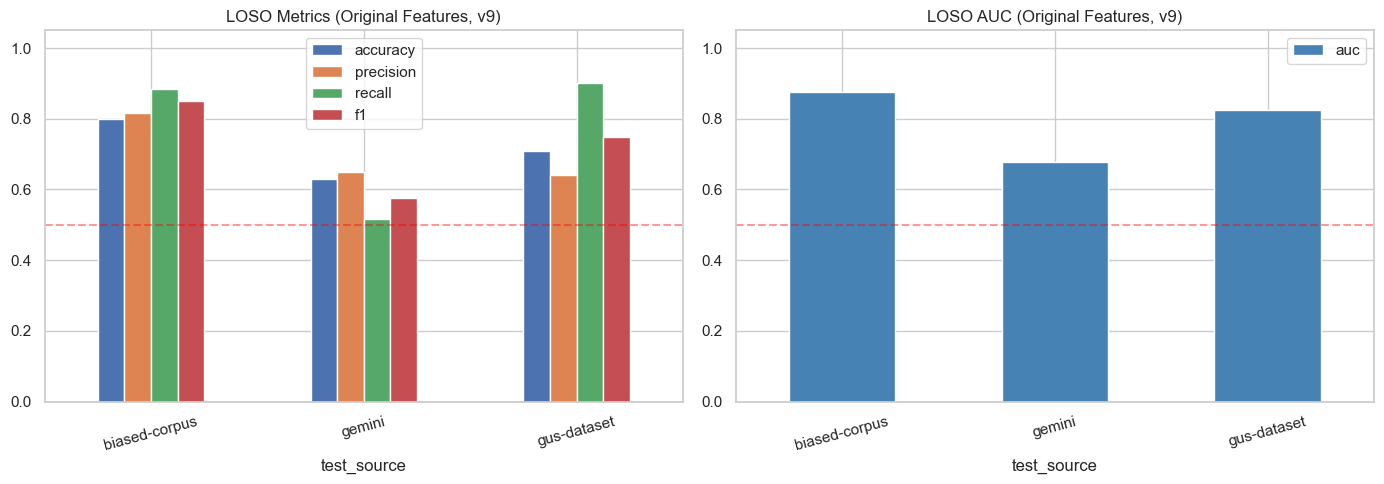

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_loso.set_index('test_source')[['accuracy', 'precision', 'recall', 'f1']].plot(
    kind='bar', ax=axes[0], rot=15
)
axes[0].set_title('LOSO Metrics (Original Features, v9)')
axes[0].set_ylim(0, 1.05)
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.4)

df_loso.set_index('test_source')[['auc']].plot(
    kind='bar', ax=axes[1], rot=15, color='steelblue'
)
axes[1].set_title('LOSO AUC (Original Features, v9)')
axes[1].set_ylim(0, 1.05)
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [11]:
import re
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier
# 1) Rebuild Gemini LOSO fold and predictions
test_source = "gemini"
test_mask = sources == test_source
train_mask = ~test_mask
X_train_l = X_final.iloc[np.where(train_mask)[0]]
X_test_l = X_final.iloc[np.where(test_mask)[0]]
y_train_l = y.iloc[np.where(train_mask)[0]]
y_test_l = y.iloc[np.where(test_mask)[0]]
gemini_loso_model = Pipeline([
    ("vt", VarianceThreshold(threshold=0.01)),
    ("s", StandardScaler()),
    ("m", XGBClassifier(
        tree_method="approx",
        max_depth=8,
        n_estimators=500,
        learning_rate=0.05,
        min_child_weight=1,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.0,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
    )),
])
gemini_loso_model.fit(X_train_l, y_train_l)
y_pred = gemini_loso_model.predict(X_test_l)
y_prob = gemini_loso_model.predict_proba(X_test_l)[:, 1]
idx_test = np.where(test_mask)[0]
df_eval = df_features.iloc[idx_test].copy()
df_eval["y_true"] = y_test_l.values
df_eval["y_pred"] = y_pred
df_eval["p_bias"] = y_prob
df_eval["is_error"] = df_eval["y_true"] != df_eval["y_pred"]
df_eval["error_type"] = np.where(
    (df_eval["y_true"] == 0) & (df_eval["y_pred"] == 1), "FP",
    np.where((df_eval["y_true"] == 1) & (df_eval["y_pred"] == 0), "FN", "OK")
)
# 2) Add linguistic/style features
hedge_pattern = re.compile(
    r"\b("
    r"maybe|perhaps|possibly|probably|likely|seems?|appears?|tends?\s+to|"
    r"i\s+think|i\s+guess|it\s+seems|it\s+appears|some|often|sometimes|generally|"
    r"talvez|possivelmente|provavelmente|parece|acho\s+que|em\s+geral|às\s+vezes|as\s+vezes"
    r")\b",
    flags=re.IGNORECASE
)
generalization_pattern = re.compile(
    r"\b(all|always|never|every|everyone|nobody|none|anyone|men|women|boys|girls|"
    r"todos|todas|sempre|nunca|ninguem|ninguém|homens|mulheres)\b",
    flags=re.IGNORECASE
)
df_eval["text"] = df_eval["text"].fillna("")
df_eval["topic"] = df_eval["topic"].fillna("unknown")
df_eval["n_tokens"] = df_eval["text"].str.split().str.len()
df_eval["is_question"] = df_eval["text"].str.contains(r"\?")
df_eval["has_hedge"] = df_eval["text"].str.contains(hedge_pattern)
df_eval["has_generalization"] = df_eval["text"].str.contains(generalization_pattern)
def formulation_type(row):
    if row["is_question"] and row["has_hedge"]:
        return "question+hedge"
    if row["is_question"]:
        return "question"
    if row["has_hedge"]:
        return "hedged statement"
    if row["has_generalization"]:
        return "explicit generalization"
    return "plain statement"
df_eval["formulation_type"] = df_eval.apply(formulation_type, axis=1)
# 3) Separate FP and FN + group errors
df_err = df_eval[df_eval["is_error"]].copy()
bins = [0, 8, 14, 22, np.inf]
labels = ["short (<=8)", "medium (9-14)", "long (15-22)", "very long (23+)"]
df_err["length_bin"] = pd.cut(df_err["n_tokens"], bins=bins, labels=labels, right=True)
len_table = df_err.groupby(["error_type", "length_bin"], observed=False).size().unstack(fill_value=0)
topic_table = (
    df_err.groupby(["error_type", "topic"])
    .size()
    .reset_index(name="n_errors")
    .sort_values(["error_type", "n_errors"], ascending=[True, False])
)
top_topics = topic_table.groupby("error_type").head(12)
form_table = df_err.groupby(["error_type", "formulation_type"]).size().unstack(fill_value=0)
flag_rates = (
    df_err.groupby("error_type")[["is_question", "has_hedge", "has_generalization"]]
    .mean()
    .rename(columns={
        "is_question": "question_rate",
        "has_hedge": "hedge_rate",
        "has_generalization": "generalization_rate",
    })
)
# 4) Pick 4 representative examples: 2 FP + 2 FN
train_topics = (
    df_features.iloc[np.where(train_mask)[0]]["topic"]
    .fillna("unknown")
    .value_counts()
    .to_dict()
)
def interpret_error(row):
    topic_seen = train_topics.get(row["topic"], 0)
    if row["error_type"] == "FP":
        if row["is_question"]:
            return "style error: factual question flagged as bias"
        if row["has_hedge"]:
            return "style error: cautious wording over-penalized"
        if topic_seen == 0:
            return "domain transfer error: unseen topic in training"
        return "lexical trigger without true bias"
    else:  # FN
        if row["has_hedge"]:
            return "hedging too subtle for the model"
        if (not row["has_generalization"]) and (not row["is_question"]):
            return "bias too implicit (low lexical salience)"
        if topic_seen == 0:
            return "domain transfer error: weak topic transfer"
        return "implicit stereotype missed"
def pick_examples(err_df, err_type, n=2):
    d = err_df[err_df["error_type"] == err_type].copy()
    if d.empty:
        return d
    picks = []
    if err_type == "FP":
        c1 = d[d["is_question"]].sort_values("p_bias", ascending=False).head(1)
        c2 = d[d["has_hedge"] & ~d.index.isin(c1.index)].sort_values("p_bias", ascending=False).head(1)
    else:
        c1 = d[d["has_hedge"]].sort_values("p_bias", ascending=True).head(1)
        c2 = d[(~d["has_generalization"]) & (~d["is_question"]) & ~d.index.isin(c1.index)].sort_values("p_bias", ascending=True).head(1)
    picks.extend([c1, c2])
    out = pd.concat([x for x in picks if len(x) > 0], axis=0)
    if len(out) < n:
        remaining = d[~d.index.isin(out.index)]
        out = pd.concat([out, remaining.head(n - len(out))], axis=0)
    return out.head(n)
fp_examples = pick_examples(df_err, "FP", 2)
fn_examples = pick_examples(df_err, "FN", 2)
examples = pd.concat([fp_examples, fn_examples], axis=0).copy()
examples["interpretation"] = examples.apply(interpret_error, axis=1)
# 5) Print concise report
cm = confusion_matrix(df_eval["y_true"], df_eval["y_pred"])
n_fp = int((df_eval["error_type"] == "FP").sum())
n_fn = int((df_eval["error_type"] == "FN").sum())
print("=== Gemini LOSO Error Analysis ===")
print("Confusion matrix [rows=true, cols=pred]:")
print(cm)
print(f"\nTotal test samples: {len(df_eval)}")
print(f"Errors: {int(df_eval['is_error'].sum())} ({df_eval['is_error'].mean():.1%}) | FP={n_fp} | FN={n_fn}")
print("\n=== Errors by sentence length ===")
print(len_table)
print("\n=== Errors by topic (top 12 per error type) ===")
print(top_topics.to_string(index=False))
print("\n=== Errors by formulation type ===")
print(form_table)
print("\n=== Linguistic marker rates within errors ===")
print((100 * flag_rates).round(1).astype(str) + "%")
print("\n=== 4 Representative Examples (2 FP + 2 FN) ===")
for i, r in examples.reset_index(drop=True).iterrows():
    print(f"\n[{i+1}] {r['error_type']} | true={r['y_true']} pred={r['y_pred']} p_bias={r['p_bias']:.3f}")
    print(f"topic={r['topic']} | n_tokens={int(r['n_tokens'])} | formulation={r['formulation_type']}")
    print(f"text: {r['text']}")
    print(f"interpretation: {r['interpretation']}")

=== Gemini LOSO Error Analysis ===
Confusion matrix [rows=true, cols=pred]:
[[1678  599]
 [1047 1116]]

Total test samples: 4440
Errors: 1646 (37.1%) | FP=599 | FN=1047

=== Errors by sentence length ===
length_bin  short (<=8)  medium (9-14)  long (15-22)  very long (23+)
error_type                                                           
FN                   85            577           342               43
FP                  505             71            23                0

=== Errors by topic (top 12 per error type) ===
error_type       topic  n_errors
        FN     general       253
        FN    everyday       191
        FN     economy       107
        FN         law        79
        FN  technology        79
        FN   education        70
        FN     culture        59
        FN      health        57
        FN    politics        55
        FN     science        55
        FN environment        22
        FN       other        17
        FP     general       195
     

## 6. Source Classifier (Original Features)

In [12]:
le = LabelEncoder()
y_source = le.fit_transform(sources)

print(f'Source labels: {list(le.classes_)}')
print(f'Random baseline: {1 / len(le.classes_):.1%}')

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_idx_src, test_idx_src = next(gss.split(X_final, y_source, groups=groups))

X_train_src = X_final.iloc[train_idx_src]
X_test_src = X_final.iloc[test_idx_src]
y_train_src = y_source[train_idx_src]
y_test_src = y_source[test_idx_src]
groups_train_src = groups[train_idx_src]

print(f'Train: {len(X_train_src)} | Test: {len(X_test_src)}')

src_models = {
    'LogReg': LogisticRegression(solver='lbfgs', max_iter=1000),
    'XGBoost': XGBClassifier(
        tree_method='approx', max_depth=8, n_estimators=500,
        learning_rate=0.05, eval_metric='mlogloss', random_state=RANDOM_STATE,
    ),
}

cv_src = StratifiedGroupKFold(n_splits=5)
best_src_acc = -1
best_src_name = None

for name, model in src_models.items():
    src_pipe = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', model),
    ])
    cv_scores = cross_validate(
        src_pipe, X_train_src, y_train_src,
        cv=cv_src, scoring='accuracy', groups=groups_train_src,
    )
    print(f'  {name:12} CV Acc: {cv_scores["test_score"].mean():.4f}')

    src_pipe.fit(X_train_src, y_train_src)
    y_pred_src = src_pipe.predict(X_test_src)
    acc = accuracy_score(y_test_src, y_pred_src)
    print(f'  {name:12} Test Acc: {acc:.4f}')

    if acc > best_src_acc:
        best_src_acc = acc
        best_src_name = name

print(f'\nBest source classifier: {best_src_name} â€” Test Accuracy: {best_src_acc:.4f}')
print(f'Random baseline: {1 / len(le.classes_):.4f}')

Source labels: ['biased-corpus', 'gemini', 'gus-dataset']
Random baseline: 33.3%
Train: 8232 | Test: 2072
  LogReg       CV Acc: 0.6845
  LogReg       Test Acc: 0.6897
  XGBoost      CV Acc: 0.6823
  XGBoost      Test Acc: 0.6805

Best source classifier: LogReg â€” Test Accuracy: 0.6897
Random baseline: 0.3333


## 7. Bias Classifier on Original Features (Pair-Aware Split)

In [13]:
#  Pair-aware split: CFs in train only, test = originals + unpaired 
"""
is_cf = (df_features['role'] == 'counterfactual').values
non_cf_positions = np.where(~is_cf)[0]
cf_positions = np.where(is_cf)[0]

print(f'Non-CF entries (originals + unpaired): {len(non_cf_positions)}')
print(f'Counterfactual entries: {len(cf_positions)}')

non_cf_pair_ids = df_features.iloc[non_cf_positions]['pair_id'].copy()
mask_no_pair = non_cf_pair_ids.isna()
non_cf_pair_ids[mask_no_pair] = [
    'unpaired_' + str(i) for i in range(mask_no_pair.sum())
]
non_cf_groups = non_cf_pair_ids.values

X_non_cf = X_final.iloc[non_cf_positions]
y_non_cf = y.iloc[non_cf_positions]

gss_bias = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_noncf_local, test_noncf_local = next(
    gss_bias.split(X_non_cf, y_non_cf, groups=non_cf_groups)
)

train_noncf_positions = non_cf_positions[train_noncf_local]
test_positions_raw = non_cf_positions[test_noncf_local]

# Keep only non-rewritten sentences in test
edit_types_test = df_features.iloc[test_positions_raw]['edit_type'].values
clean_mask = np.isin(edit_types_test, ['original'])
test_positions = test_positions_raw[clean_mask]

# Move rewritten sentences to train
rewritten_positions = test_positions_raw[~clean_mask]
train_noncf_positions = np.concatenate([train_noncf_positions, rewritten_positions])

print(f'Test: removed {(~clean_mask).sum()} rewritten sentences '
      f'(strengthened/relabelled) -> moved to train')


train_pair_ids = set(df_features.iloc[train_noncf_positions]['pair_id'].dropna())
cf_pair_ids = df_features.iloc[cf_positions]['pair_id']
cf_in_train_mask = cf_pair_ids.isin(train_pair_ids).values
cf_for_train_positions = cf_positions[cf_in_train_mask]
cf_excluded_positions = cf_positions[~cf_in_train_mask]

train_idx = np.concatenate([train_noncf_positions, cf_for_train_positions])
test_idx = test_positions

X_train = X_final.iloc[train_idx]
X_test = X_final.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

train_group_col = df_features.iloc[train_idx]['pair_id'].copy()
mask_no = train_group_col.isna()
train_group_col[mask_no] = [
    'unpaired_' + str(i) for i in range(mask_no.sum())
]
groups_train = train_group_col.values

print(f'\n Split Summary ')
print(f'Training: {X_train.shape[0]} (originals+unpaired: {len(train_noncf_positions)}, CFs: {len(cf_for_train_positions)})')
print(f'Testing:  {X_test.shape[0]} (originals + unpaired only)')
print(f'Excluded CFs (pair in test): {len(cf_excluded_positions)}')

# Leakage checks
train_texts = set(df_features.iloc[train_idx]['text'])
test_texts = set(df_features.iloc[test_idx]['text'])
assert len(train_texts & test_texts) == 0, 'LEAKAGE: overlapping texts!'

train_pairs = set(df_features.iloc[train_idx]['pair_id'].dropna())
test_pairs = set(df_features.iloc[test_idx]['pair_id'].dropna())
assert len(train_pairs & test_pairs) == 0, 'LEAKAGE: pair_id shared!'
print('Leakage checks passed (no text overlap, no pair_id overlap).')

print(f'\nLabel distribution:')
print(f'  Train: biased={int(y_train.sum())}, neutral={int((y_train == 0).sum())} ({y_train.mean():.1%} biased)')
print(f'  Test:  biased={int(y_test.sum())}, neutral={int((y_test == 0).sum())} ({y_test.mean():.1%} biased)')
# Persist split indices for exact reproducibility
split_dir = root_dir / 'attention_app' / 'bias' / 'models'
split_dir.mkdir(parents=True, exist_ok=True)

split_npz_path = split_dir / 'bert_bias_classifier_v9_split.npz'
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_fit_local, val_local = next(gss_val.split(X_train, y_train, groups=groups_train))
train_fit_idx = train_idx[train_fit_local]
val_idx = train_idx[val_local]
np.savez(
    split_npz_path,
    train_idx=train_idx.astype(np.int64),
    test_idx=test_idx.astype(np.int64),
    train_fit_idx=train_fit_idx.astype(np.int64),
    val_idx=val_idx.astype(np.int64),
    train_noncf_positions=train_noncf_positions.astype(np.int64),
    test_positions_raw=test_positions_raw.astype(np.int64),
    test_positions=test_positions.astype(np.int64),
    cf_for_train_positions=cf_for_train_positions.astype(np.int64),
    cf_excluded_positions=cf_excluded_positions.astype(np.int64),
    random_state=np.int64(RANDOM_STATE),
)

train_rows_path = split_dir / 'bert_bias_classifier_v9_train_rows.csv'
train_fit_rows_path = split_dir / 'bert_bias_classifier_v9_train_fit_rows.csv'
val_rows_path = split_dir / 'bert_bias_classifier_v9_val_rows.csv'
test_rows_path = split_dir / 'bert_bias_classifier_v9_test_rows.csv'

train_rows = df_features.iloc[train_idx][
    ['label', 'source_canonical', 'role', 'edit_type', 'pair_id']
].copy()
train_rows.insert(0, 'idx', train_idx)
train_rows.to_csv(train_rows_path, index=False)

train_fit_rows = df_features.iloc[train_fit_idx][
    ['label', 'source_canonical', 'role', 'edit_type', 'pair_id']
].copy()
train_fit_rows.insert(0, 'idx', train_fit_idx)
train_fit_rows.to_csv(train_fit_rows_path, index=False)

val_rows = df_features.iloc[val_idx][
    ['text', 'label', 'source_canonical', 'role', 'edit_type', 'pair_id']
].copy()
val_rows.insert(0, 'idx', val_idx)
val_rows.to_csv(val_rows_path, index=False)

test_rows = df_features.iloc[test_idx][
    ['text', 'label', 'source_canonical', 'role', 'edit_type', 'pair_id']
].copy()
test_rows.insert(0, 'idx', test_idx)
test_rows.to_csv(test_rows_path, index=False)

print(f'\nSaved split NPZ: {split_npz_path}')
print(f'Saved train rows: {train_rows_path}')
print(f'Saved train-fit rows: {train_fit_rows_path}')
print(f'Saved validation rows: {val_rows_path}')
print(f'Saved test rows: {test_rows_path}')""" 


"\nis_cf = (df_features['role'] == 'counterfactual').values\nnon_cf_positions = np.where(~is_cf)[0]\ncf_positions = np.where(is_cf)[0]\n\nprint(f'Non-CF entries (originals + unpaired): {len(non_cf_positions)}')\nprint(f'Counterfactual entries: {len(cf_positions)}')\n\nnon_cf_pair_ids = df_features.iloc[non_cf_positions]['pair_id'].copy()\nmask_no_pair = non_cf_pair_ids.isna()\nnon_cf_pair_ids[mask_no_pair] = [\n    'unpaired_' + str(i) for i in range(mask_no_pair.sum())\n]\nnon_cf_groups = non_cf_pair_ids.values\n\nX_non_cf = X_final.iloc[non_cf_positions]\ny_non_cf = y.iloc[non_cf_positions]\n\ngss_bias = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)\ntrain_noncf_local, test_noncf_local = next(\n    gss_bias.split(X_non_cf, y_non_cf, groups=non_cf_groups)\n)\n\ntrain_noncf_positions = non_cf_positions[train_noncf_local]\ntest_positions_raw = non_cf_positions[test_noncf_local]\n\n# Keep only non-rewritten sentences in test\nedit_types_test = df_features.iloc[

In [14]:
# Load existing split ONLY (no regeneration, no overwrite)
import numpy as np
split_npz_path = root_dir / "attention_app" / "bias" / "models" / "bert_bias_classifier_v9_split.npz"
if not split_npz_path.exists():
    raise FileNotFoundError(
        f"Split file not found: {split_npz_path}\n"
        "This cell is load-only. Create the split once in another run/cell."
    )
data = np.load(split_npz_path)
train_idx = data["train_idx"].astype(np.int64)
test_idx = data["test_idx"].astype(np.int64)
train_fit_idx = data["train_fit_idx"].astype(np.int64) if "train_fit_idx" in data.files else None
val_idx = data["val_idx"].astype(np.int64) if "val_idx" in data.files else None
# Rebuild objects expected by downstream cells
X_train = X_final.iloc[train_idx]
X_test = X_final.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]
train_group_col = df_features.iloc[train_idx]["pair_id"].copy()
mask_no = train_group_col.isna()
train_group_col[mask_no] = [f"unpaired_{i}" for i in range(mask_no.sum())]
groups_train = train_group_col.values
# Optional safety checks
train_texts = set(df_features.iloc[train_idx]["text"])
test_texts = set(df_features.iloc[test_idx]["text"])
assert len(train_texts & test_texts) == 0, "LEAKAGE: overlapping texts"
train_pairs = set(df_features.iloc[train_idx]["pair_id"].dropna())
test_pairs = set(df_features.iloc[test_idx]["pair_id"].dropna())
assert len(train_pairs & test_pairs) == 0, "LEAKAGE: overlapping pair_id"
print(f"Loaded split from: {split_npz_path}")
print(f"Train: {len(train_idx)} | Test: {len(test_idx)}")
if val_idx is not None:
    print(f"Val: {len(val_idx)}")
print("No files were written.")

Loaded split from: c:\Users\anoca\Documents\GitHub\attention-atlas\attention_app\bias\models\bert_bias_classifier_v9_split.npz
Train: 8229 | Test: 1282
Val: 1649
No files were written.


In [15]:
#  Model Comparison 
models = {
    'LogReg': LogisticRegression(solver='liblinear', max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(
        tree_method='approx', max_depth=8, n_estimators=500,
        learning_rate=0.05, min_child_weight=1, gamma=0.1,
        reg_alpha=0.1, reg_lambda=1.0,
        eval_metric='logloss', random_state=RANDOM_STATE,
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(50,), max_iter=500, early_stopping=True,
        validation_fraction=0.15, n_iter_no_change=15,
        alpha=0.01, random_state=RANDOM_STATE,
    ),
}

results = {}
cv = StratifiedGroupKFold(n_splits=5)

print('Comparing models (original features)')
for name, model in models.items():
    pipeline = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', model),
    ])
    scores = cross_validate(
        pipeline, X_train, y_train,
        cv=cv, scoring=['roc_auc', 'accuracy', 'f1'], groups=groups_train,
    )
    results[name] = {
        'auc': scores['test_roc_auc'].mean(),
        'accuracy': scores['test_accuracy'].mean(),
        'f1': scores['test_f1'].mean(),
    }
    print(
        f'{name:12} | AUC: {results[name]["auc"]:.4f} | '
        f'Acc: {results[name]["accuracy"]:.4f} | F1: {results[name]["f1"]:.4f}'
    )

best_model_name = max(results, key=lambda n: results[n]['auc'])
print(f'\nBest model: {best_model_name} (AUC={results[best_model_name]["auc"]:.4f})')

Comparing models (original features)
LogReg       | AUC: 0.9509 | Acc: 0.8752 | F1: 0.8841
RandomForest | AUC: 0.8996 | Acc: 0.8123 | F1: 0.8290
XGBoost      | AUC: 0.9378 | Acc: 0.8556 | F1: 0.8685
MLP          | AUC: 0.9493 | Acc: 0.8751 | F1: 0.8833

Best model: LogReg (AUC=0.9509)


In [16]:
param_grids = {
    'RandomForest': {
        'm__n_estimators': [50, 100, 200],
        'm__max_depth': [None, 10, 20],
        'm__min_samples_leaf': [1, 2, 4],
    },
    'XGBoost': {
        'm__n_estimators': [50, 100, 200],
        'm__learning_rate': [0.01, 0.1, 0.2],
        'm__max_depth': [3, 5, 7],
    },
    'MLP': {
        'm__hidden_layer_sizes': [(32,), (50,), (64,), (32, 16), (50, 25)],
        'm__alpha': [0.01, 0.05, 0.1, 0.2, 0.5],
        'm__learning_rate_init': [0.001, 0.005, 0.01],
        'm__activation': ['relu', 'tanh'],
        'm__solver': ['adam'],
        'm__early_stopping': [True],
        'm__validation_fraction': [0.15],
        'm__n_iter_no_change': [15],
    },
    'LogReg': {
        'm__C': [0.1, 1.0, 10.0],
    },
}

print(f'Tuning {best_model_name}...')
pipeline = Pipeline([
    ('vt', VarianceThreshold(threshold=0.01)),
    ('s', StandardScaler()),
    ('m', models[best_model_name]),
])

search = HalvingRandomSearchCV(
    pipeline,
    param_distributions=param_grids[best_model_name],
    cv=StratifiedGroupKFold(n_splits=5),
    scoring='roc_auc',
    n_jobs=1,
    factor=1.5,
    resource='n_samples',
    random_state=RANDOM_STATE,
)
search.fit(X_train, y_train, groups=groups_train)

print(f'Best params: {search.best_params_}')
final_model = search.best_estimator_

Tuning LogReg...
Best params: {'m__C': 1.0}


In [17]:
y_test_pred = final_model.predict(X_test)
y_test_prob = final_model.predict_proba(X_test)[:, 1]

orig_auc = roc_auc_score(y_test, y_test_prob)
orig_acc = accuracy_score(y_test, y_test_pred)
orig_prec = precision_score(y_test, y_test_pred, zero_division=0)
orig_rec = recall_score(y_test, y_test_pred, zero_division=0)
orig_f1 = f1_score(y_test, y_test_pred, zero_division=0)

print('Bias Classifier â€” Original Features (Test Set)')
print(f'AUC:       {orig_auc:.4f}')
print(f'Accuracy:  {orig_acc:.4f}')
print(f'Precision: {orig_prec:.4f}')
print(f'Recall:    {orig_rec:.4f}')
print(f'F1:        {orig_f1:.4f}')
print('\n' + classification_report(y_test, y_test_pred, zero_division=0))

Bias Classifier â€” Original Features (Test Set)
AUC:       0.9632
Accuracy:  0.8861
Precision: 0.8504
Recall:    0.8907
F1:        0.8701

              precision    recall  f1-score   support

           0       0.92      0.88      0.90       733
           1       0.85      0.89      0.87       549

    accuracy                           0.89      1282
   macro avg       0.88      0.89      0.88      1282
weighted avg       0.89      0.89      0.89      1282



## 7.1. Counterfactual Consistency (Point 3)

In [18]:
print('Counterfactual Consistency Analysis')
print('=' * 60)

paired_entries = df_features[df_features['pair_id'].notna()].copy()
pair_groups = paired_entries.groupby('pair_id')

test_idx_set = set(test_idx)
results_cc = []

for pid, group in pair_groups:
    orig = group[group['role'] == 'original']
    cf = group[group['role'] == 'counterfactual']
    if len(orig) != 1 or len(cf) != 1:
        continue

    orig_pos = orig.index[0]
    cf_pos = cf.index[0]

    X_orig = X_final.iloc[[orig_pos]]
    X_cf = X_final.iloc[[cf_pos]]

    pred_orig = final_model.predict(X_orig)[0]
    pred_cf = final_model.predict(X_cf)[0]
    prob_orig = final_model.predict_proba(X_orig)[0, 1]
    prob_cf = final_model.predict_proba(X_cf)[0, 1]

    label_orig = int(y.iloc[orig_pos])
    label_cf = int(y.iloc[cf_pos])

    orig_correct = (pred_orig == label_orig)
    cf_correct = (pred_cf == label_cf)
    both_correct = orig_correct and cf_correct

    if label_orig > label_cf:
        direction_correct = prob_orig > prob_cf
    elif label_orig < label_cf:
        direction_correct = prob_cf > prob_orig
    else:
        direction_correct = True

    prob_delta = abs(prob_orig - prob_cf)
    is_held_out = orig_pos in test_idx_set

    results_cc.append({
        'pair_id': pid,
        'text_orig': orig['text'].values[0][:80],
        'text_cf': cf['text'].values[0][:80],
        'label_orig': label_orig,
        'label_cf': label_cf,
        'pred_orig': pred_orig,
        'pred_cf': pred_cf,
        'prob_orig': prob_orig,
        'prob_cf': prob_cf,
        'prob_delta': prob_delta,
        'orig_correct': orig_correct,
        'cf_correct': cf_correct,
        'both_correct': both_correct,
        'direction_correct': direction_correct,
        'source': orig['source_canonical'].values[0],
        'is_held_out': is_held_out,
    })

df_cc = pd.DataFrame(results_cc)
df_cc_heldout = df_cc[df_cc['is_held_out']]

print(f'\nTotal pairs evaluated: {len(df_cc)}')
print(f'Held-out pairs (original in test): {len(df_cc_heldout)}')

for label, subset in [('ALL PAIRS', df_cc), ('HELD-OUT PAIRS ONLY', df_cc_heldout)]:
    if len(subset) == 0:
        continue
    print(f'\n {label} ({len(subset)} pairs) ')
    print(f'  Full consistency (both correct): {subset["both_correct"].mean():.1%}')
    print(f'  Original correct:                {subset["orig_correct"].mean():.1%}')
    print(f'  CF correct:                      {subset["cf_correct"].mean():.1%}')
    print(f'  Direction correct:               {subset["direction_correct"].mean():.1%}')
    print(f'  Mean |P(orig) - P(cf)|:          {subset["prob_delta"].mean():.3f}')

print(f'\n Consistency by Source ')
for src in df_cc['source'].unique():
    sub = df_cc[df_cc['source'] == src]
    print(
        f'  {src:18s}: consistency={sub["both_correct"].mean():.1%}  '
        f'direction={sub["direction_correct"].mean():.1%}  n={len(sub)}'
    )

Counterfactual Consistency Analysis

Total pairs evaluated: 3844
Held-out pairs (original in test): 790

 ALL PAIRS (3844 pairs) 
  Full consistency (both correct): 79.6%
  Original correct:                89.8%
  CF correct:                      89.3%
  Direction correct:               97.7%
  Mean |P(orig) - P(cf)|:          0.697

 HELD-OUT PAIRS ONLY (790 pairs) 
  Full consistency (both correct): 78.9%
  Original correct:                89.2%
  CF correct:                      89.2%
  Direction correct:               97.8%
  Mean |P(orig) - P(cf)|:          0.707

 Consistency by Source 
  gemini            : consistency=84.0%  direction=97.7%  n=2156
  gus-dataset       : consistency=75.2%  direction=96.9%  n=731
  biased-corpus     : consistency=73.2%  direction=98.1%  n=957


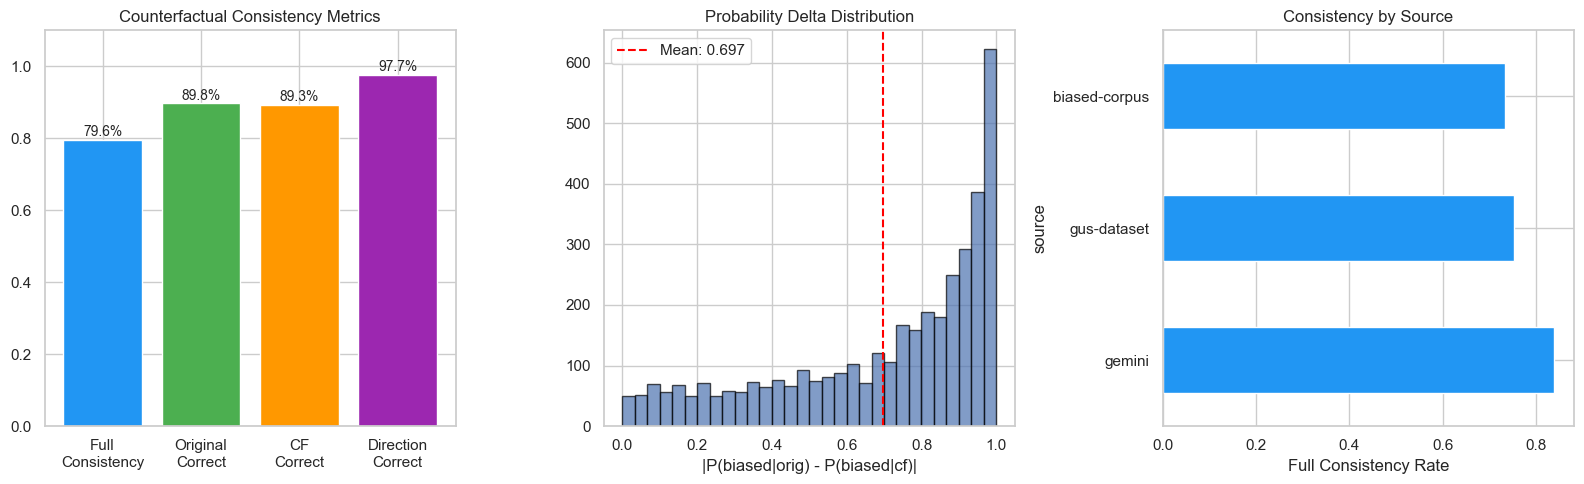

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_cc = ['both_correct', 'orig_correct', 'cf_correct', 'direction_correct']
labels_cc = ['Full\nConsistency', 'Original\nCorrect', 'CF\nCorrect', 'Direction\nCorrect']
vals_cc = [df_cc[m].mean() for m in metrics_cc]
bars = axes[0].bar(labels_cc, vals_cc, color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'])
for bar, v in zip(bars, vals_cc):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{v:.1%}', ha='center', fontsize=10)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Counterfactual Consistency Metrics')

axes[1].hist(df_cc['prob_delta'], bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(df_cc['prob_delta'].mean(), color='red', linestyle='--',
                label=f'Mean: {df_cc["prob_delta"].mean():.3f}')
axes[1].set_xlabel('|P(biased|orig) - P(biased|cf)|')
axes[1].set_title('Probability Delta Distribution')
axes[1].legend()

src_consistency = df_cc.groupby('source')['both_correct'].mean().sort_values(ascending=False)
src_consistency.plot(kind='barh', ax=axes[2], color='#2196F3')
axes[2].set_xlabel('Full Consistency Rate')
axes[2].set_title('Consistency by Source')

plt.tight_layout()
plt.show()

## 8. Residualization â€” Train-Only Fitting (Point 1)

**Critical fix from v5**: The linear regression that removes source signal is now
fitted **only on the training set** and then applied (projected) onto the test set.
This prevents information leakage from test-set source distributions.

### Procedure
1. One-hot encode the canonical source for each sample.
2. For each attention feature, fit `LinearRegression(feature ~ source_dummies)` on **train indices only**.
3. Compute residuals: `feature_residual = feature - LR.predict(source_dummies)` for both train and test.
4. The test set residuals use coefficients learned from train data only.

In [20]:
source_dummies_full = pd.get_dummies(
    df_features['source_canonical'], drop_first=False
).values

print(f'Source dummies shape: {source_dummies_full.shape}')
print(f'Original features shape: {X_final.shape}')

#  TRAIN-ONLY residualization 
# We residualize the full matrix but the LR is fitted ONLY on train_idx.
X_residual = X_final.copy()
lr = LinearRegression()

source_dummies_train = source_dummies_full[train_idx]

for col in X_final.columns:
    feature_train = X_final[col].iloc[train_idx].values.reshape(-1, 1)
    lr.fit(source_dummies_train, feature_train)
    # Apply the train-fitted model to ALL samples
    predicted_all = lr.predict(source_dummies_full)
    X_residual[col] = X_final[col].values - predicted_all.ravel()

print(f'Residualized features shape: {X_residual.shape}')
print('\n*** Residualization fitted on TRAIN only, applied to all. ***')
print(f'    Train indices used for fitting: {len(train_idx)}')
print(f'    Test indices (coefficients NOT seen): {len(test_idx)}')

Source dummies shape: (10304, 3)
Original features shape: (10304, 3238)
Residualized features shape: (10304, 3238)

*** Residualization fitted on TRAIN only, applied to all. ***
    Train indices used for fitting: 8229
    Test indices (coefficients NOT seen): 1282


In [21]:
# Verify: source classifier on residualized features
y_source_check = LabelEncoder().fit_transform(sources)

source_check_pipe = Pipeline([
    ('vt', VarianceThreshold(threshold=0.01)),
    ('s', StandardScaler()),
    ('m', LogisticRegression(solver='lbfgs', max_iter=1000)),
])

# Use the SAME split as the source classifier above for fair comparison
source_check_pipe.fit(
    X_residual.iloc[train_idx_src], y_source_check[train_idx_src]
)
src_acc_residual = accuracy_score(
    y_source_check[test_idx_src],
    source_check_pipe.predict(X_residual.iloc[test_idx_src]),
)

print('Source classifier accuracy:')
print(f'  Before residualization: {best_src_acc:.4f}')
print(f'  After residualization:  {src_acc_residual:.4f}')
print(f'  Random baseline:        {1 / len(unique_sources):.4f}')

Source classifier accuracy:
  Before residualization: 0.6897
  After residualization:  0.4035
  Random baseline:        0.3333


## 8.1. LOSO on Residualized Features (Point 2)

For each LOSO fold, we re-fit the residualization on the training sources only,
then apply it to the held-out source. This ensures no leakage per fold.

In [22]:
print('LOSO on Residualized Features (train-only fitting per fold)')
print('=' * 72 + '\n')

loso_resid_results = []

for test_source in unique_sources:
    print(f' Test on [{test_source}] ')

    test_mask = sources == test_source
    train_mask = ~test_mask
    train_pos = np.where(train_mask)[0]
    test_pos = np.where(test_mask)[0]

    # Residualize: fit LR on train sources only
    X_resid_fold = X_final.copy()
    sd_train = source_dummies_full[train_pos]
    lr_fold = LinearRegression()

    for col in X_final.columns:
        feat_train = X_final[col].iloc[train_pos].values.reshape(-1, 1)
        lr_fold.fit(sd_train, feat_train)
        predicted_all = lr_fold.predict(source_dummies_full)
        X_resid_fold[col] = X_final[col].values - predicted_all.ravel()

    X_train_r = X_resid_fold.iloc[train_pos]
    X_test_r = X_resid_fold.iloc[test_pos]
    y_train_r = y.iloc[train_pos]
    y_test_r = y.iloc[test_pos]

    print(f'  Train: {len(X_train_r)} | Test: {len(X_test_r)}')

    pipeline_r = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', XGBClassifier(
            tree_method='approx', max_depth=8, n_estimators=500,
            learning_rate=0.05, min_child_weight=1, gamma=0.1,
            reg_alpha=0.1, reg_lambda=1.0,
            eval_metric='logloss', random_state=RANDOM_STATE,
        )),
    ])

    pipeline_r.fit(X_train_r, y_train_r)
    y_pred_r = pipeline_r.predict(X_test_r)
    y_prob_r = pipeline_r.predict_proba(X_test_r)[:, 1]

    acc = accuracy_score(y_test_r, y_pred_r)
    prec = precision_score(y_test_r, y_pred_r, zero_division=0)
    rec = recall_score(y_test_r, y_pred_r, zero_division=0)
    f1_val = f1_score(y_test_r, y_pred_r, zero_division=0)
    auc = roc_auc_score(y_test_r, y_prob_r)
    cm = confusion_matrix(y_test_r, y_pred_r)

    print(f'  Acc={acc:.4f} | F1={f1_val:.4f} | AUC={auc:.4f}\n')

    loso_resid_results.append({
        'test_source': test_source,
        'n_test': len(X_test_r),
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1_val,
        'auc': auc,
        'confusion_matrix': cm.tolist(),
    })

df_loso_resid = pd.DataFrame(loso_resid_results)
print('\nLOSO Summary (residualized features, train-only fitting):')
print(df_loso_resid[['test_source', 'n_test', 'accuracy', 'f1', 'auc']].to_string(index=False))
print(f'\nMean: Acc={df_loso_resid["accuracy"].mean():.4f} | '
      f'F1={df_loso_resid["f1"].mean():.4f} | AUC={df_loso_resid["auc"].mean():.4f}')

LOSO on Residualized Features (train-only fitting per fold)

 Test on [biased-corpus] 
  Train: 7069 | Test: 3235
  Acc=0.7895 | F1=0.8424 | AUC=0.8612

 Test on [gemini] 
  Train: 5864 | Test: 4440
  Acc=0.6658 | F1=0.6301 | AUC=0.7218

 Test on [gus-dataset] 
  Train: 7675 | Test: 2629
  Acc=0.6729 | F1=0.7219 | AUC=0.7774


LOSO Summary (residualized features, train-only fitting):
  test_source  n_test  accuracy       f1      auc
biased-corpus    3235  0.789490 0.842398 0.861181
       gemini    4440  0.665766 0.630110 0.721756
  gus-dataset    2629  0.672879 0.721863 0.777409

Mean: Acc=0.7094 | F1=0.7315 | AUC=0.7868


LOSO Comparison: Original vs Residualized
  test_source  accuracy_orig  f1_orig  auc_orig  accuracy_resid  f1_resid  auc_resid  delta_auc  delta_f1
biased-corpus       0.799382 0.849035  0.876035        0.789490  0.842398   0.861181  -0.014854 -0.006637
       gemini       0.629279 0.575554  0.678041        0.665766  0.630110   0.721756   0.043715  0.054555
  gus-dataset       0.707493 0.747951  0.824172        0.672879  0.721863   0.777409  -0.046764 -0.026089


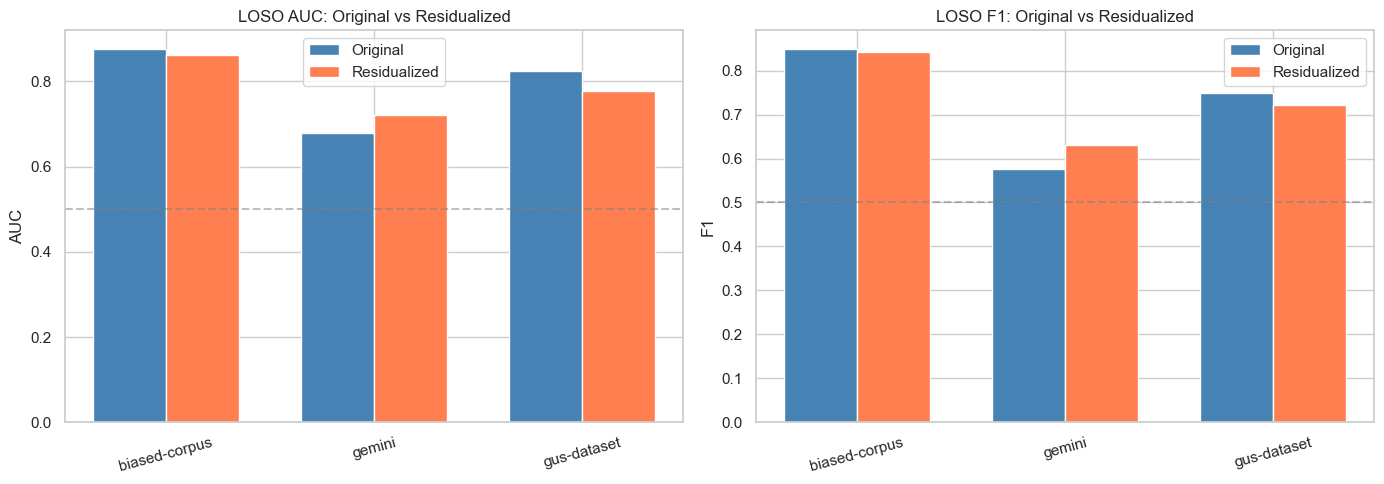

In [23]:
print('LOSO Comparison: Original vs Residualized')
print('=' * 72)

comparison = df_loso[['test_source', 'accuracy', 'f1', 'auc']].merge(
    df_loso_resid[['test_source', 'accuracy', 'f1', 'auc']],
    on='test_source', suffixes=('_orig', '_resid'),
)
comparison['delta_auc'] = comparison['auc_resid'] - comparison['auc_orig']
comparison['delta_f1'] = comparison['f1_resid'] - comparison['f1_orig']
print(comparison.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(unique_sources))
w = 0.35

axes[0].bar(x - w/2, comparison['auc_orig'], w, label='Original', color='steelblue')
axes[0].bar(x + w/2, comparison['auc_resid'], w, label='Residualized', color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(unique_sources, rotation=15)
axes[0].set_ylabel('AUC')
axes[0].set_title('LOSO AUC: Original vs Residualized')
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].legend()

axes[1].bar(x - w/2, comparison['f1_orig'], w, label='Original', color='steelblue')
axes[1].bar(x + w/2, comparison['f1_resid'], w, label='Residualized', color='coral')
axes[1].set_xticks(x)
axes[1].set_xticklabels(unique_sources, rotation=15)
axes[1].set_ylabel('F1')
axes[1].set_title('LOSO F1: Original vs Residualized')
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Bias Classifier on Residualized Features

In [24]:
X_train_res = X_residual.iloc[train_idx]
X_test_res = X_residual.iloc[test_idx]

models_res = {
    'LogReg': LogisticRegression(solver='liblinear', max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(
        tree_method='approx', max_depth=8, n_estimators=500,
        learning_rate=0.05, min_child_weight=1, gamma=0.1,
        reg_alpha=0.1, reg_lambda=1.0,
        eval_metric='logloss', random_state=RANDOM_STATE,
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(50,), max_iter=500, early_stopping=True,
        validation_fraction=0.15, n_iter_no_change=15,
        alpha=0.01, random_state=RANDOM_STATE,
    ),
}

results_res = {}
cv_res = StratifiedGroupKFold(n_splits=5)

print('Comparing models on residualized features')
for name, model in models_res.items():
    pipeline_res = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', model),
    ])
    scores = cross_validate(
        pipeline_res, X_train_res, y_train,
        cv=cv_res, scoring=['roc_auc', 'accuracy', 'f1'], groups=groups_train,
    )
    results_res[name] = {
        'auc': scores['test_roc_auc'].mean(),
        'accuracy': scores['test_accuracy'].mean(),
        'f1': scores['test_f1'].mean(),
    }
    print(
        f'{name:12} | AUC: {results_res[name]["auc"]:.4f} | '
        f'Acc: {results_res[name]["accuracy"]:.4f} | F1: {results_res[name]["f1"]:.4f}'
    )

best_res_name = max(results_res, key=lambda n: results_res[n]['auc'])
print(f'\nBest residualized model: {best_res_name} (AUC={results_res[best_res_name]["auc"]:.4f})')

Comparing models on residualized features
LogReg       | AUC: 0.9438 | Acc: 0.8694 | F1: 0.8787
RandomForest | AUC: 0.9137 | Acc: 0.8312 | F1: 0.8469
XGBoost      | AUC: 0.9426 | Acc: 0.8637 | F1: 0.8759
MLP          | AUC: 0.9485 | Acc: 0.8735 | F1: 0.8829

Best residualized model: MLP (AUC=0.9485)


In [25]:
print(f'Tuning {best_res_name} on residualized features...')
pipeline_res = Pipeline([
    ('vt', VarianceThreshold(threshold=0.01)),
    ('s', StandardScaler()),
    ('m', models_res[best_res_name]),
])

search_res = HalvingRandomSearchCV(
    pipeline_res,
    param_distributions=param_grids[best_res_name],
    cv=StratifiedGroupKFold(n_splits=5),
    scoring='roc_auc',
    n_jobs=1,
    factor=1.5,
    resource='n_samples',
    random_state=RANDOM_STATE,
)
search_res.fit(X_train_res, y_train, groups=groups_train)

print(f'Best params: {search_res.best_params_}')
final_model_res = search_res.best_estimator_

y_test_pred_res = final_model_res.predict(X_test_res)
y_test_prob_res = final_model_res.predict_proba(X_test_res)[:, 1]

auc_res = roc_auc_score(y_test, y_test_prob_res)
acc_res = accuracy_score(y_test, y_test_pred_res)
prec_res = precision_score(y_test, y_test_pred_res, zero_division=0)
rec_res = recall_score(y_test, y_test_pred_res, zero_division=0)
f1_res = f1_score(y_test, y_test_pred_res, zero_division=0)

print('\nBias Classifier â€” Residualized Features (Test Set)')
print(f'AUC:       {auc_res:.4f}')
print(f'Accuracy:  {acc_res:.4f}')
print(f'Precision: {prec_res:.4f}')
print(f'Recall:    {rec_res:.4f}')
print(f'F1:        {f1_res:.4f}')
print('\n' + classification_report(y_test, y_test_pred_res, zero_division=0))

Tuning MLP on residualized features...
Best params: {'m__validation_fraction': 0.15, 'm__solver': 'adam', 'm__n_iter_no_change': 15, 'm__learning_rate_init': 0.005, 'm__hidden_layer_sizes': (32, 16), 'm__early_stopping': True, 'm__alpha': 0.1, 'm__activation': 'tanh'}

Bias Classifier â€” Residualized Features (Test Set)
AUC:       0.9582
Accuracy:  0.8924
Precision: 0.8501
Recall:    0.9089
F1:        0.8785

              precision    recall  f1-score   support

           0       0.93      0.88      0.90       733
           1       0.85      0.91      0.88       549

    accuracy                           0.89      1282
   macro avg       0.89      0.89      0.89      1282
weighted avg       0.89      0.89      0.89      1282



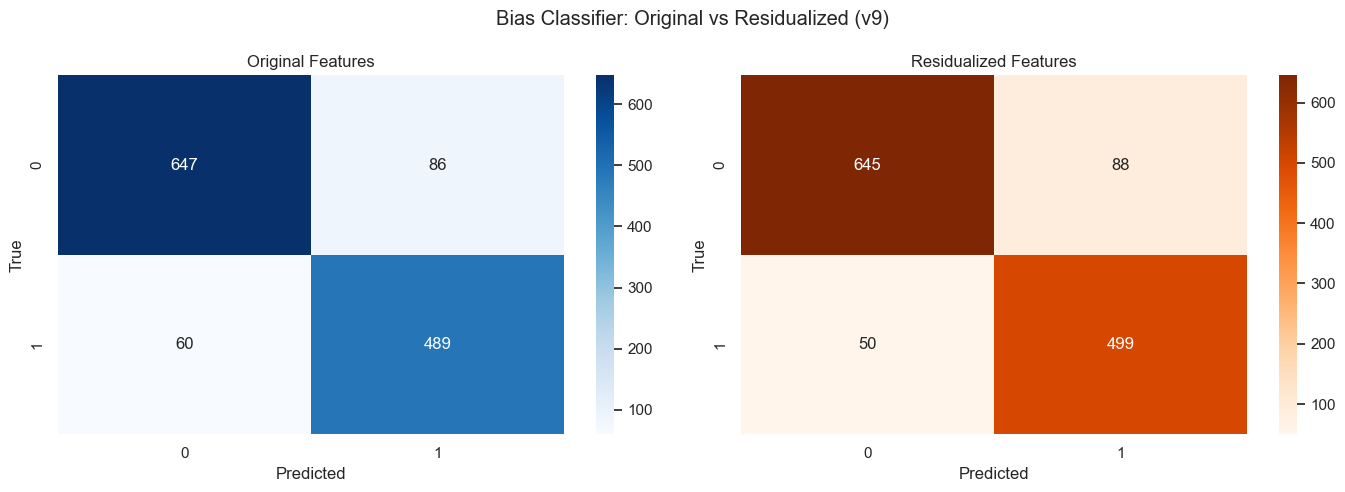

In [26]:
# Confusion matrices side by side
cm_orig = confusion_matrix(y_test, y_test_pred)
cm_res = confusion_matrix(y_test, y_test_pred_res)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Original Features')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('True')

sns.heatmap(cm_res, annot=True, fmt='d', cmap='Oranges', ax=ax2)
ax2.set_title('Residualized Features')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('True')

plt.suptitle('Bias Classifier: Original vs Residualized (v9)')
plt.tight_layout()
plt.show()

In [27]:
import numpy as np

source_train = df_features.iloc[train_idx]['source_canonical'].values
source_test  = df_features.iloc[test_idx]['source_canonical'].values

X_train     = X_final.iloc[train_idx].values.astype(np.float32)
X_test      = X_final.iloc[test_idx].values.astype(np.float32)
X_train_res = X_residual.iloc[train_idx].values.astype(np.float32)
X_test_res  = X_residual.iloc[test_idx].values.astype(np.float32)

y_train = y.iloc[train_idx].values.astype(int)
y_test  = y.iloc[test_idx].values.astype(int)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'sources train: {dict(zip(*np.unique(source_train, return_counts=True)))}')
print(f'sources test:  {dict(zip(*np.unique(source_test,  return_counts=True)))}')


X_train: (8229, 3238) | X_test: (1282, 3238)
sources train: {'biased-corpus': 2701, 'gemini': 3415, 'gus-dataset': 2113}
sources test:  {'biased-corpus': 379, 'gemini': 528, 'gus-dataset': 375}


In [28]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

def inlp_fit_transform(X_tr, X_te, s_tr, n_iters=10, min_acc_gap=0.01, C=1.0, seed=0):
    """Iterative Nullspace Projection (Ravfogel et al., 2020).

    Fits linear probes on the train fold to predict the source `s_tr`,
    projects features onto the probe's nullspace, repeats up to `n_iters`
    or until the probe accuracy drops within `min_acc_gap` of the
    majority baseline. Same projection is applied to the test fold.
    """
    le = LabelEncoder().fit(s_tr)
    s_tr_enc = le.transform(s_tr)
    baseline = np.bincount(s_tr_enc).max() / len(s_tr_enc)

    X_tr_curr, X_te_curr = X_tr.copy(), X_te.copy()
    P = np.eye(X_tr.shape[1])
    history = []

    for it in range(n_iters):
        clf = LogisticRegression(
            penalty='l2', C=C, max_iter=2000,
            multi_class='multinomial', solver='lbfgs', random_state=seed,
        ).fit(X_tr_curr, s_tr_enc)
        acc = clf.score(X_tr_curr, s_tr_enc)
        history.append(acc)
        if acc - baseline < min_acc_gap:
            break

        W = clf.coef_                                   # (k, d)
        U, _, _ = np.linalg.svd(W.T, full_matrices=False)
        P_step = np.eye(W.shape[1]) - U @ U.T          # nullspace of W
        P = P_step @ P
        X_tr_curr = X_tr_curr @ P_step
        X_te_curr = X_te_curr @ P_step

    return X_tr_curr, X_te_curr, P, history

X_train_inlp, X_test_inlp, P_inlp, inlp_hist = inlp_fit_transform(
    X_train, X_test, source_train, n_iters=15, seed=42,
)
print(f'INLP probe acc per iter: {[round(a, 3) for a in inlp_hist]}')
print(f'Stopped after {len(inlp_hist)} iterations.')


INLP probe acc per iter: [0.721, 0.694, 0.687, 0.672, 0.665, 0.65, 0.642, 0.637, 0.629, 0.624, 0.618, 0.612, 0.605, 0.6, 0.599]
Stopped after 15 iterations.


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

def source_probe(X_tr, X_te, s_tr, s_te, seed=0):
    clf = LogisticRegression(
        penalty='l2', C=1.0, max_iter=2000,
        multi_class='multinomial', solver='lbfgs', random_state=seed,
    ).fit(X_tr, s_tr)
    pred = clf.predict(X_te)
    return accuracy_score(s_te, pred), f1_score(s_te, pred, average='macro')

baseline_acc = np.bincount(LabelEncoder().fit_transform(source_train)).max() / len(source_train)

probe_results = {
    'raw'             : source_probe(X_train,      X_test,      source_train, source_test),
    'residualisation' : source_probe(X_train_res,  X_test_res,  source_train, source_test),
    f'INLP (k={len(inlp_hist)})' : source_probe(X_train_inlp, X_test_inlp, source_train, source_test),
}

print(f'Majority baseline: acc = {baseline_acc:.3f}\n')
for name, (acc, f1) in probe_results.items():
    print(f'{name:25s}  acc = {acc:.3f}   macro-F1 = {f1:.3f}')


Majority baseline: acc = 0.415

raw                        acc = 0.722   macro-F1 = 0.686
residualisation            acc = 0.412   macro-F1 = 0.194
INLP (k=15)                acc = 0.652   macro-F1 = 0.599


In [30]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, roc_auc_score

def bias_eval(X_tr, X_te, y_tr, y_te, seed=3):
    clf = MLPClassifier(
        hidden_layer_sizes=(128,), max_iter=200,
        early_stopping=True, random_state=seed,
    ).fit(X_tr, y_tr)
    pred  = clf.predict(X_te)
    proba = clf.predict_proba(X_te)[:, 1]
    return f1_score(y_te, pred), roc_auc_score(y_te, proba)

bias_results = {
    'raw'             : bias_eval(X_train,      X_test,      y_train, y_test),
    'residualisation' : bias_eval(X_train_res,  X_test_res,  y_train, y_test),
    f'INLP (k={len(inlp_hist)})' : bias_eval(X_train_inlp, X_test_inlp, y_train, y_test),
}

print(f'{"variant":25s}  {"F1":>6s}   {"AUC":>6s}')
for name, (f1, auc) in bias_results.items():
    print(f'{name:25s}  {f1:6.3f}   {auc:6.3f}')


variant                        F1      AUC
raw                         0.857    0.948
residualisation             0.910    0.973
INLP (k=15)                 0.819    0.927


## 10. Consolidated Final Table (Point 4)

All results in one place:
- 4.1 Source classifier: original vs residualized
- 4.2 Bias classifier: original vs residualized
- 4.3 LOSO by source (original + residualized)
- 4.4 Source-only baseline on v9

In [35]:
print('=' * 80)
print('CONSOLIDATED RESULTS TABLE â€” Dataset v9')
print('=' * 80)

# - 4.4 Source-Only Baseline -
print('\n 4.4 Source-Only Baseline (v9) ')
print(f'  Accuracy: {source_only_acc:.4f}')
print(f'  F1:       {source_only_f1:.4f}')
print(f'  AUC:      {source_only_auc:.4f}')

# - 4.1 Source Classifier -
print('\n 4.1 Source Classifier (Original vs Residualized) ')
print(f'{"":18} {"Accuracy":>10}')
print(f'{"Original features":18} {best_src_acc:10.4f}')
print(f'{"Residualized":18} {src_acc_residual:10.4f}')
print(f'{"Random baseline":18} {1/len(unique_sources):10.4f}')

# - 4.2 Bias Classifier -
print('\n 4.2 Bias Classifier (Original vs Residualized) ')
print(f'{"Metric":12} | {"Original":>10} | {"Residualized":>12} | {"Delta":>8}')
print('-' * 52)
for metric, vo, vr in [
    ('AUC', orig_auc, auc_res),
    ('Accuracy', orig_acc, acc_res),
    ('Precision', orig_prec, prec_res),
    ('Recall', orig_rec, rec_res),
    ('F1', orig_f1, f1_res),
]:
    print(f'{metric:12} | {vo:10.4f} | {vr:12.4f} | {vr - vo:+8.4f}')

# - 4.3 LOSO by Source -
print('\n 4.3 LOSO by Source (Original vs Residualized) ')
print(f'{"Source":18} | {"Orig AUC":>9} | {"Resid AUC":>10} | '
      f'{"Orig F1":>8} | {"Resid F1":>9} | {"Delta AUC":>10}')
print('-' * 80)
for _, row_o in df_loso.iterrows():
    src = row_o['test_source']
    row_r = df_loso_resid[df_loso_resid['test_source'] == src].iloc[0]
    print(
        f'{src:18} | {row_o["auc"]:9.4f} | {row_r["auc"]:10.4f} | '
        f'{row_o["f1"]:8.4f} | {row_r["f1"]:9.4f} | {row_r["auc"] - row_o["auc"]:+10.4f}'
    )
print('-' * 80)
print(
    f'{"MEAN":18} | {df_loso["auc"].mean():9.4f} | {df_loso_resid["auc"].mean():10.4f} | '
    f'{df_loso["f1"].mean():8.4f} | {df_loso_resid["f1"].mean():9.4f} | '
    f'{df_loso_resid["auc"].mean() - df_loso["auc"].mean():+10.4f}'
)

# - Counterfactual Consistency Summary -
print('\n Counterfactual Consistency (Point 3) ')
print(f'  Total pairs:             {len(df_cc)}')
print(f'  Held-out pairs:          {len(df_cc_heldout)}')
if len(df_cc_heldout) > 0:
    print(f'  Full consistency (held-out):  {df_cc_heldout["both_correct"].mean():.1%}')
    print(f'  Direction correct (held-out): {df_cc_heldout["direction_correct"].mean():.1%}')
print(f'  Full consistency (all):       {df_cc["both_correct"].mean():.1%}')
print(f'  Direction correct (all):      {df_cc["direction_correct"].mean():.1%}')
print(f'  Mean prob delta (all):        {df_cc["prob_delta"].mean():.3f}')

CONSOLIDATED RESULTS TABLE â€” Dataset v9

 4.4 Source-Only Baseline (v9) 
  Accuracy: 0.5536
  F1:       0.4732
  AUC:      0.5663

 4.1 Source Classifier (Original vs Residualized) 
                     Accuracy
Original features      0.6897
Residualized           0.4035
Random baseline        0.3333

 4.2 Bias Classifier (Original vs Residualized) 
Metric       |   Original | Residualized |    Delta
----------------------------------------------------
AUC          |     0.9632 |       0.9582 |  -0.0049
Accuracy     |     0.8861 |       0.8924 |  +0.0062
Precision    |     0.8504 |       0.8501 |  -0.0003
Recall       |     0.8907 |       0.9089 |  +0.0182
F1           |     0.8701 |       0.8785 |  +0.0084

 4.3 LOSO by Source (Original vs Residualized) 
Source             |  Orig AUC |  Resid AUC |  Orig F1 |  Resid F1 |  Delta AUC
--------------------------------------------------------------------------------
biased-corpus      |    0.8760 |     0.8612 |   0.8490 |    0.8424 |   

In [36]:
# - Interpretation -
delta_auc_bias = auc_res - orig_auc
delta_f1_bias = f1_res - orig_f1

print('=' * 80)
print('INTERPRETATION')
print('=' * 80)

print(f'\n1. SOURCE CONFOUNDING')
print(f'   Source-only baseline accuracy on v9: {source_only_acc:.1%}')
print(f'   (v5 reference was ~54.4%)')
print(f'   Source classifier on original features: {best_src_acc:.1%}')
print(f'   Source classifier after residualization: {src_acc_residual:.1%}')
print(f'   => Residualization removes the linear source component.')

print(f'\n2. BIAS SIGNAL ROBUSTNESS')
if abs(delta_auc_bias) < 0.05 and abs(delta_f1_bias) < 0.05:
    print('   Bias classifier is STABLE after residualization.')
    print('   The bias signal persists after removing the linear source component.')
elif delta_auc_bias < -0.05 or delta_f1_bias < -0.05:
    print('   Bias classifier DROPS after residualization.')
    print('   The model was partially relying on source artifacts.')
else:
    print('   Bias classifier IMPROVES after residualization.')
    print('   Source information was acting as noise.')

print(f'\n3. LOSO GENERALIZATION')
print(f'   Mean LOSO AUC (original):      {df_loso["auc"].mean():.4f}')
print(f'   Mean LOSO AUC (residualized):  {df_loso_resid["auc"].mean():.4f}')
weakest = df_loso_resid.loc[df_loso_resid['auc'].idxmin()]
print(f'   Weakest LOSO fold: {weakest["test_source"]} (AUC={weakest["auc"]:.4f})')
print(f'   => Non-linear domain effects likely still present for this source.')

print(f'\n4. RESIDUALIZATION PROCEDURE (Point 1 â€” confirmed)')
print(f'   LinearRegression fitted on TRAIN indices only ({len(train_idx)} samples).')
print(f'   Coefficients applied to both train and test.')
print(f'   LOSO residualization re-fitted per fold (train sources only).')
print(f'   => No leakage from test set source distributions.')

INTERPRETATION

1. SOURCE CONFOUNDING
   Source-only baseline accuracy on v9: 55.4%
   (v5 reference was ~54.4%)
   Source classifier on original features: 69.0%
   Source classifier after residualization: 40.3%
   => Residualization removes the linear source component.

2. BIAS SIGNAL ROBUSTNESS
   Bias classifier is STABLE after residualization.
   The bias signal persists after removing the linear source component.

3. LOSO GENERALIZATION
   Mean LOSO AUC (original):      0.7927
   Mean LOSO AUC (residualized):  0.7868
   Weakest LOSO fold: gemini (AUC=0.7218)
   => Non-linear domain effects likely still present for this source.

4. RESIDUALIZATION PROCEDURE (Point 1 â€” confirmed)
   LinearRegression fitted on TRAIN indices only (8229 samples).
   Coefficients applied to both train and test.
   LOSO residualization re-fitted per fold (train sources only).
   => No leakage from test set source distributions.


In [37]:
from IPython.display import display

rows = []

rows.append(('4.1 Source Classifier', 'Accuracy', f'{best_src_acc:.4f}', f'{src_acc_residual:.4f}'))
rows.append(('', 'Random baseline', f'{1/len(unique_sources):.4f}', ''))

for metric, vo, vr in [
    ('AUC', orig_auc, auc_res),
    ('Accuracy', orig_acc, acc_res),
    ('Precision', orig_prec, prec_res),
    ('Recall', orig_rec, rec_res),
    ('F1', orig_f1, f1_res),
]:
    section = '4.2 Bias Classifier' if metric == 'AUC' else ''
    rows.append((section, metric, f'{vo:.4f}', f'{vr:.4f}'))

for i, (_, row_o) in enumerate(df_loso.iterrows()):
    src = row_o['test_source']
    row_r = df_loso_resid[df_loso_resid['test_source'] == src].iloc[0]
    section = '4.3 LOSO' if i == 0 else ''
    for m in ['accuracy', 'auc', 'f1']:
        label = m.upper() if m == 'auc' else m.capitalize()
        rows.append((section, f'{src} {label}', f'{row_o[m]:.4f}', f'{row_r[m]:.4f}'))
        section = ''

for m in ['accuracy', 'auc', 'f1']:
    label = m.upper() if m == 'auc' else m.capitalize()
    rows.append(('', f'MEAN {label}', f'{df_loso[m].mean():.4f}', f'{df_loso_resid[m].mean():.4f}'))

rows.append(('4.4 Source-Only Baseline', 'Accuracy', f'{source_only_acc:.4f}', ''))
rows.append(('', 'F1', f'{source_only_f1:.4f}', ''))
rows.append(('', 'AUC', f'{source_only_auc:.4f}', ''))

df_table = pd.DataFrame(rows, columns=['Section', 'Metric', 'Original', 'Residualized'])

display(df_table.style
    .set_properties(**{'text-align': 'right'}, subset=['Original', 'Residualized'])
    .set_properties(**{'text-align': 'left'}, subset=['Section', 'Metric'])
    .set_properties(**{'font-weight': 'bold'}, subset=pd.IndexSlice[
        df_table[df_table['Section'] != ''].index, ['Section']
    ])
    .hide(axis='index')
    .set_caption('Consolidated Results â€” Dataset v9')
)


Section,Metric,Original,Residualized
4.1 Source Classifier,Accuracy,0.6897,0.4035
,Random baseline,0.3333,
4.2 Bias Classifier,AUC,0.9632,0.9582
,Accuracy,0.8861,0.8924
,Precision,0.8504,0.8501
,Recall,0.8907,0.9089
,F1,0.8701,0.8785
4.3 LOSO,biased-corpus Accuracy,0.7994,0.7895
,biased-corpus AUC,0.8760,0.8612
,biased-corpus F1,0.8490,0.8424


## Multi-Seed Stability Analysis

Rerun the main pipeline across multiple seeds to report mean Â± std.

In [32]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

def inlp_fit_transform(X_tr, X_te, s_tr, n_iters=5, min_acc_gap=0.01, C=1.0, seed=0):
    """Iterative Nullspace Projection. Pre-scales with a train-fitted scaler,
    iterates linear probes against `s_tr`, projects onto each probe's
    nullspace. Same projection applied to test."""
    sc = StandardScaler(with_mean=False).fit(X_tr)
    X_tr_curr = sc.transform(X_tr).astype(np.float32)
    X_te_curr = sc.transform(X_te).astype(np.float32)

    s_tr = np.asarray(s_tr)
    baseline = np.bincount(s_tr).max() / len(s_tr) if np.issubdtype(s_tr.dtype, np.integer) \
               else max(np.unique(s_tr, return_counts=True)[1]) / len(s_tr)

    for _ in range(n_iters):
        clf = LogisticRegression(
            penalty='l2', C=C, max_iter=1000,
            multi_class='multinomial', solver='lbfgs', random_state=seed,
        ).fit(X_tr_curr, s_tr)
        if clf.score(X_tr_curr, s_tr) - baseline < min_acc_gap:
            break
        W = clf.coef_
        U, _, _ = np.linalg.svd(W.T, full_matrices=False)
        P_step = (np.eye(W.shape[1]) - U @ U.T).astype(np.float32)
        X_tr_curr = X_tr_curr @ P_step
        X_te_curr = X_te_curr @ P_step
    return X_tr_curr, X_te_curr


In [33]:
SEEDS = [1, 2, 3, 4, 5]

all_seed_results = []
all_seed_loso = []

for seed in SEEDS:
    print(f'\n{"="*72}')
    print(f'SEED = {seed}')
    print(f'{"="*72}')

    # - 1. Pair-aware split -
    is_cf_s = (df_features['role'] == 'counterfactual').values
    non_cf_pos = np.where(~is_cf_s)[0]
    cf_pos = np.where(is_cf_s)[0]

    nc_pair_ids = df_features.iloc[non_cf_pos]['pair_id'].copy()
    mask_np = nc_pair_ids.isna()
    nc_pair_ids[mask_np] = ['unpaired_' + str(i) for i in range(mask_np.sum())]
    nc_groups = nc_pair_ids.values

    X_nc = X_final.iloc[non_cf_pos]
    y_nc = y.iloc[non_cf_pos]

    gss_s = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=seed)
    tr_local, te_local = next(gss_s.split(X_nc, y_nc, groups=nc_groups))

    tr_noncf_pos = non_cf_pos[tr_local]
    te_pos = non_cf_pos[te_local]

    tr_pair_ids = set(df_features.iloc[tr_noncf_pos]['pair_id'].dropna())
    cf_pids = df_features.iloc[cf_pos]['pair_id']
    cf_in_tr = cf_pos[cf_pids.isin(tr_pair_ids).values]

    s_train_idx = np.concatenate([tr_noncf_pos, cf_in_tr])
    s_test_idx = te_pos

    X_tr_s = X_final.iloc[s_train_idx]
    X_te_s = X_final.iloc[s_test_idx]
    y_tr_s = y.iloc[s_train_idx]
    y_te_s = y.iloc[s_test_idx]

    tr_gcol = df_features.iloc[s_train_idx]['pair_id'].copy()
    mask_g = tr_gcol.isna()
    tr_gcol[mask_g] = ['unpaired_' + str(i) for i in range(mask_g.sum())]
    groups_tr_s = tr_gcol.values

    # - 2. Bias classifier (original) -
    pipe_orig = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', MLPClassifier(
            hidden_layer_sizes=(50,), max_iter=500, early_stopping=True,
            validation_fraction=0.15, n_iter_no_change=15,
            alpha=0.01, random_state=seed,
        )),
    ])
    pipe_orig.fit(X_tr_s, y_tr_s)
    yp_orig = pipe_orig.predict(X_te_s)
    yprob_orig = pipe_orig.predict_proba(X_te_s)[:, 1]

    # - 3. Residualization (train-only) -
    sd_full = pd.get_dummies(df_features['source_canonical'], drop_first=False).values
    sd_tr = sd_full[s_train_idx]
    X_res_s = X_final.copy()
    lr_s = LinearRegression()
    for col in X_final.columns:
        feat_tr = X_final[col].iloc[s_train_idx].values.reshape(-1, 1)
        lr_s.fit(sd_tr, feat_tr)
        X_res_s[col] = X_final[col].values - lr_s.predict(sd_full).ravel()

    # - 3b. INLP (train-only) -
    le_inlp = LabelEncoder().fit(sources)
    s_src_inlp_tr = le_inlp.transform(sources[s_train_idx])
    X_tr_inlp, X_te_inlp = inlp_fit_transform(
        X_final.iloc[s_train_idx].values.astype(np.float32),
        X_final.iloc[s_test_idx].values.astype(np.float32),
        s_src_inlp_tr, n_iters=10, seed=seed,
    )

    # - 4. Source classifier (orig vs resid vs INLP) -
    le_s = LabelEncoder()
    y_src_s = le_s.fit_transform(sources)

    gss_src = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=seed)
    tr_src_idx, te_src_idx = next(gss_src.split(X_final, y_src_s, groups=groups))

    src_pipe_orig = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', LogisticRegression(solver='lbfgs', max_iter=1000)),
    ])
    src_pipe_orig.fit(X_final.iloc[tr_src_idx], y_src_s[tr_src_idx])
    s_src_acc_orig = accuracy_score(y_src_s[te_src_idx], src_pipe_orig.predict(X_final.iloc[te_src_idx]))

    src_pipe_res = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', LogisticRegression(solver='lbfgs', max_iter=1000)),
    ])
    src_pipe_res.fit(X_res_s.iloc[tr_src_idx], y_src_s[tr_src_idx])
    s_src_acc_res = accuracy_score(y_src_s[te_src_idx], src_pipe_res.predict(X_res_s.iloc[te_src_idx]))

    # INLP source-recoverability uses the same split, projected with seed-fold INLP
    X_tr_src_inlp, X_te_src_inlp = inlp_fit_transform(
        X_final.iloc[tr_src_idx].values.astype(np.float32),
        X_final.iloc[te_src_idx].values.astype(np.float32),
        y_src_s[tr_src_idx], n_iters=5, seed=seed,
    )
    src_pipe_inlp = LogisticRegression(solver='lbfgs', max_iter=1000)
    src_pipe_inlp.fit(X_tr_src_inlp, y_src_s[tr_src_idx])
    s_src_acc_inlp = accuracy_score(y_src_s[te_src_idx], src_pipe_inlp.predict(X_te_src_inlp))

    # - 5. Bias classifier (residualized) -
    pipe_res = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', MLPClassifier(
            hidden_layer_sizes=(50,), max_iter=500, early_stopping=True,
            validation_fraction=0.15, n_iter_no_change=15,
            alpha=0.01, random_state=seed,
        )),
    ])
    pipe_res.fit(X_res_s.iloc[s_train_idx], y_tr_s)
    yp_res = pipe_res.predict(X_res_s.iloc[s_test_idx])
    yprob_res = pipe_res.predict_proba(X_res_s.iloc[s_test_idx])[:, 1]

    # - 5b. Bias classifier (INLP) -
    pipe_inlp = Pipeline([
        ('s', StandardScaler()),
        ('m', MLPClassifier(
            hidden_layer_sizes=(50,), max_iter=500, early_stopping=True,
            validation_fraction=0.15, n_iter_no_change=15,
            alpha=0.01, random_state=seed,
        )),
    ])
    pipe_inlp.fit(X_tr_inlp, y_tr_s)
    yp_inlp = pipe_inlp.predict(X_te_inlp)
    yprob_inlp = pipe_inlp.predict_proba(X_te_inlp)[:, 1]

    # - 6. LOSO (orig + resid + INLP) -
    loso_aucs_orig, loso_f1s_orig, loso_accs_orig = [], [], []
    loso_aucs_res, loso_f1s_res, loso_accs_res = [], [], []
    loso_aucs_inlp, loso_f1s_inlp, loso_accs_inlp = [], [], []

    for test_src in unique_sources:
        tmask = sources == test_src
        tr_pos_l = np.where(~tmask)[0]
        te_pos_l = np.where(tmask)[0]

        # Original
        p_l = Pipeline([
            ('vt', VarianceThreshold(threshold=0.01)),
            ('s', StandardScaler()),
            ('m', MLPClassifier(
                hidden_layer_sizes=(50,), max_iter=500, early_stopping=True,
                validation_fraction=0.15, n_iter_no_change=15,
                alpha=0.01, random_state=seed,
            )),
        ])
        p_l.fit(X_final.iloc[tr_pos_l], y.iloc[tr_pos_l])
        yp_l = p_l.predict(X_final.iloc[te_pos_l])
        yprob_l = p_l.predict_proba(X_final.iloc[te_pos_l])[:, 1]
        loso_accs_orig.append(accuracy_score(y.iloc[te_pos_l], yp_l))
        loso_f1s_orig.append(f1_score(y.iloc[te_pos_l], yp_l, zero_division=0))
        loso_aucs_orig.append(roc_auc_score(y.iloc[te_pos_l], yprob_l))

        # Residualized (per-fold)
        X_res_fold = X_final.copy()
        sd_tr_l = sd_full[tr_pos_l]
        lr_l = LinearRegression()
        for col in X_final.columns:
            feat = X_final[col].iloc[tr_pos_l].values.reshape(-1, 1)
            lr_l.fit(sd_tr_l, feat)
            X_res_fold[col] = X_final[col].values - lr_l.predict(sd_full).ravel()

        p_lr = Pipeline([
            ('vt', VarianceThreshold(threshold=0.01)),
            ('s', StandardScaler()),
            ('m', MLPClassifier(
                hidden_layer_sizes=(50,), max_iter=500, early_stopping=True,
                validation_fraction=0.15, n_iter_no_change=15,
                alpha=0.01, random_state=seed,
            )),
        ])
        p_lr.fit(X_res_fold.iloc[tr_pos_l], y.iloc[tr_pos_l])
        yp_lr = p_lr.predict(X_res_fold.iloc[te_pos_l])
        yprob_lr = p_lr.predict_proba(X_res_fold.iloc[te_pos_l])[:, 1]
        loso_accs_res.append(accuracy_score(y.iloc[te_pos_l], yp_lr))
        loso_f1s_res.append(f1_score(y.iloc[te_pos_l], yp_lr, zero_division=0))
        loso_aucs_res.append(roc_auc_score(y.iloc[te_pos_l], yprob_lr))

        # INLP (per-fold)
        s_src_fold_tr = le_inlp.transform(sources[tr_pos_l])
        X_tr_fold_inlp, X_te_fold_inlp = inlp_fit_transform(
            X_final.iloc[tr_pos_l].values.astype(np.float32),
            X_final.iloc[te_pos_l].values.astype(np.float32),
            s_src_fold_tr, n_iters=5, seed=seed,
        )
        p_inlp_l = Pipeline([
            ('s', StandardScaler()),
            ('m', MLPClassifier(
                hidden_layer_sizes=(50,), max_iter=500, early_stopping=True,
                validation_fraction=0.15, n_iter_no_change=15,
                alpha=0.01, random_state=seed,
            )),
        ])
        p_inlp_l.fit(X_tr_fold_inlp, y.iloc[tr_pos_l])
        yp_inlp_l = p_inlp_l.predict(X_te_fold_inlp)
        yprob_inlp_l = p_inlp_l.predict_proba(X_te_fold_inlp)[:, 1]
        loso_accs_inlp.append(accuracy_score(y.iloc[te_pos_l], yp_inlp_l))
        loso_f1s_inlp.append(f1_score(y.iloc[te_pos_l], yp_inlp_l, zero_division=0))
        loso_aucs_inlp.append(roc_auc_score(y.iloc[te_pos_l], yprob_inlp_l))

    # Store per-source LOSO for this seed
    for s_idx, test_src in enumerate(unique_sources):
        all_seed_loso.append({
            'seed': seed,
            'source': test_src,
            'acc_orig': loso_accs_orig[s_idx],
            'auc_orig': loso_aucs_orig[s_idx],
            'f1_orig':  loso_f1s_orig[s_idx],
            'acc_resid': loso_accs_res[s_idx],
            'auc_resid': loso_aucs_res[s_idx],
            'f1_resid':  loso_f1s_res[s_idx],
            'acc_inlp':  loso_accs_inlp[s_idx],
            'auc_inlp':  loso_aucs_inlp[s_idx],
            'f1_inlp':   loso_f1s_inlp[s_idx],
        })

    seed_row = {
        'seed': seed,
        'src_acc_orig':  s_src_acc_orig,
        'src_acc_resid': s_src_acc_res,
        'src_acc_inlp':  s_src_acc_inlp,
        'bias_auc_orig':  roc_auc_score(y_te_s, yprob_orig),
        'bias_acc_orig':  accuracy_score(y_te_s, yp_orig),
        'bias_f1_orig':   f1_score(y_te_s, yp_orig, zero_division=0),
        'bias_auc_resid': roc_auc_score(y_te_s, yprob_res),
        'bias_acc_resid': accuracy_score(y_te_s, yp_res),
        'bias_f1_resid':  f1_score(y_te_s, yp_res, zero_division=0),
        'bias_auc_inlp':  roc_auc_score(y_te_s, yprob_inlp),
        'bias_acc_inlp':  accuracy_score(y_te_s, yp_inlp),
        'bias_f1_inlp':   f1_score(y_te_s, yp_inlp, zero_division=0),
        'loso_acc_orig':  np.mean(loso_accs_orig),
        'loso_f1_orig':   np.mean(loso_f1s_orig),
        'loso_auc_orig':  np.mean(loso_aucs_orig),
        'loso_acc_resid': np.mean(loso_accs_res),
        'loso_f1_resid':  np.mean(loso_f1s_res),
        'loso_auc_resid': np.mean(loso_aucs_res),
        'loso_acc_inlp':  np.mean(loso_accs_inlp),
        'loso_f1_inlp':   np.mean(loso_f1s_inlp),
        'loso_auc_inlp':  np.mean(loso_aucs_inlp),
    }
    all_seed_results.append(seed_row)

    print(f'  Bias orig  AUC={seed_row["bias_auc_orig"]:.4f}  F1={seed_row["bias_f1_orig"]:.4f}')
    print(f'  Bias resid AUC={seed_row["bias_auc_resid"]:.4f}  F1={seed_row["bias_f1_resid"]:.4f}')
    print(f'  Bias INLP  AUC={seed_row["bias_auc_inlp"]:.4f}  F1={seed_row["bias_f1_inlp"]:.4f}')
    print(f'  Source acc orig={s_src_acc_orig:.4f}  resid={s_src_acc_res:.4f}  inlp={s_src_acc_inlp:.4f}')
    print(f'  LOSO mean AUC orig={seed_row["loso_auc_orig"]:.4f}  resid={seed_row["loso_auc_resid"]:.4f}  inlp={seed_row["loso_auc_inlp"]:.4f}')

df_seeds = pd.DataFrame(all_seed_results)
df_seed_loso = pd.DataFrame(all_seed_loso)


SEED = 1
  Bias orig  AUC=0.9507  F1=0.8744
  Bias resid AUC=0.9570  F1=0.8779
  Bias INLP  AUC=0.9711  F1=0.9116
  Source acc orig=0.6676  resid=0.3942  inlp=0.4884
  LOSO mean AUC orig=0.8594  resid=0.8629  inlp=0.9037

SEED = 2
  Bias orig  AUC=0.9543  F1=0.8831
  Bias resid AUC=0.9537  F1=0.8766
  Bias INLP  AUC=0.9686  F1=0.8989
  Source acc orig=0.7145  resid=0.4029  inlp=0.5208
  LOSO mean AUC orig=0.8493  resid=0.8547  inlp=0.9064

SEED = 3
  Bias orig  AUC=0.9615  F1=0.8755
  Bias resid AUC=0.9544  F1=0.8721
  Bias INLP  AUC=0.9676  F1=0.8893
  Source acc orig=0.6970  resid=0.3931  inlp=0.5139
  LOSO mean AUC orig=0.8623  resid=0.8570  inlp=0.9008

SEED = 4
  Bias orig  AUC=0.9500  F1=0.8751
  Bias resid AUC=0.9495  F1=0.8607
  Bias INLP  AUC=0.9670  F1=0.8918
  Source acc orig=0.6892  resid=0.4041  inlp=0.5041
  LOSO mean AUC orig=0.8771  resid=0.8606  inlp=0.8967

SEED = 5
  Bias orig  AUC=0.9510  F1=0.8695
  Bias resid AUC=0.9371  F1=0.8577
  Bias INLP  AUC=0.9640  F1=0.89

In [34]:
print(f'{"="*72}')
print(f'MULTI-SEED SUMMARY — {len(SEEDS)} seeds: {SEEDS}')
print(f'{"="*72}\n')

# Bias classifier per seed
bias_metrics = [
    ('Bias AUC Original',         'bias_auc_orig'),
    ('Bias Accuracy Original',    'bias_acc_orig'),
    ('Bias F1 Original',          'bias_f1_orig'),
    ('Bias AUC Residualized',     'bias_auc_resid'),
    ('Bias Accuracy Residualized','bias_acc_resid'),
    ('Bias F1 Residualized',      'bias_f1_resid'),
    ('Bias AUC INLP',             'bias_auc_inlp'),
    ('Bias Accuracy INLP',        'bias_acc_inlp'),
    ('Bias F1 INLP',              'bias_f1_inlp'),
]

rows1 = []
for label, col in bias_metrics:
    m, s = df_seeds[col].mean(), df_seeds[col].std()
    rows1.append((label, f'{m:.4f} ± {s:.4f}'))

df_bias_summary = pd.DataFrame(rows1, columns=['Metric', 'mean ± std'])

display(df_bias_summary.style
    .set_properties(**{'text-align': 'left'})
    .hide(axis='index')
    .set_caption(f'Bias Classifier — {len(SEEDS)} seeds')
)

# Other metrics (Source classifier + LOSO)
other_metrics = [
    ('4.1 Source Classifier Acc', 'src_acc_orig',  'src_acc_resid',  'src_acc_inlp'),
    ('4.3 LOSO Mean AUC',         'loso_auc_orig', 'loso_auc_resid', 'loso_auc_inlp'),
    ('4.3 LOSO Mean Accuracy',    'loso_acc_orig', 'loso_acc_resid', 'loso_acc_inlp'),
    ('4.3 LOSO Mean F1',          'loso_f1_orig',  'loso_f1_resid',  'loso_f1_inlp'),
]

rows2 = []
for label, col_orig, col_resid, col_inlp in other_metrics:
    mo, so = df_seeds[col_orig ].mean(), df_seeds[col_orig ].std()
    mr, sr = df_seeds[col_resid].mean(), df_seeds[col_resid].std()
    mi, si = df_seeds[col_inlp ].mean(), df_seeds[col_inlp ].std()
    rows2.append((
        label,
        f'{mo:.4f} ± {so:.4f}',
        f'{mr:.4f} ± {sr:.4f}',
        f'{mi:.4f} ± {si:.4f}',
    ))

df_other_summary = pd.DataFrame(
    rows2,
    columns=['Metric', 'Original (mean ± std)', 'Residualized (mean ± std)', 'INLP (mean ± std)'],
)

display(df_other_summary.style
    .set_properties(**{'text-align': 'left'})
    .hide(axis='index')
    .set_caption(f'Source Classifier & LOSO — {len(SEEDS)} seeds')
)

# Per-seed detail
print('\nPer-seed detail:')
display(df_seeds.round(4))


MULTI-SEED SUMMARY — 5 seeds: [1, 2, 3, 4, 5]



Metric,mean ± std
Bias AUC Original,0.9535 ± 0.0047
Bias Accuracy Original,0.8805 ± 0.0052
Bias F1 Original,0.8755 ± 0.0049
Bias AUC Residualized,0.9503 ± 0.0079
Bias Accuracy Residualized,0.8741 ± 0.0095
Bias F1 Residualized,0.8690 ± 0.0093
Bias AUC INLP,0.9677 ± 0.0026
Bias Accuracy INLP,0.9039 ± 0.0080
Bias F1 INLP,0.8983 ± 0.0087


Metric,Original (mean ± std),Residualized (mean ± std),INLP (mean ± std)
4.1 Source Classifier Acc,0.6879 ± 0.0192,0.3949 ± 0.0096,0.4985 ± 0.0222
4.3 LOSO Mean AUC,0.8633 ± 0.0103,0.8591 ± 0.0033,0.8989 ± 0.0076
4.3 LOSO Mean Accuracy,0.7839 ± 0.0096,0.7777 ± 0.0029,0.8200 ± 0.0059
4.3 LOSO Mean F1,0.7865 ± 0.0102,0.7859 ± 0.0049,0.8307 ± 0.0052



Per-seed detail:


,seed,src_acc_orig,src_acc_resid,src_acc_inlp,bias_auc_orig,bias_acc_orig,bias_f1_orig,bias_auc_resid,bias_acc_resid,bias_f1_resid,...,bias_f1_inlp,loso_acc_orig,loso_f1_orig,loso_auc_orig,loso_acc_resid,loso_f1_resid,loso_auc_resid,loso_acc_inlp,loso_f1_inlp,loso_auc_inlp
0,1,0.6676,0.3942,0.4884,0.9507,0.8799,0.8744,0.9570,0.8842,0.8779,...,0.9116,0.7769,0.7785,0.8594,0.7758,0.7853,0.8629,0.8226,0.8338,0.9037
1,2,0.7145,0.4029,0.5208,0.9543,0.8854,0.8831,0.9537,0.8799,0.8766,...,0.8989,0.7719,0.7748,0.8493,0.7740,0.7852,0.8547,0.8266,0.8346,0.9064
2,3,0.6970,0.3931,0.5139,0.9615,0.8861,0.8755,0.9544,0.8774,0.8721,...,0.8893,0.7855,0.7899,0.8623,0.7803,0.7912,0.8570,0.8215,0.8328,0.9008
3,4,0.6892,0.4041,0.5041,0.9500,0.8768,0.8751,0.9495,0.8681,0.8607,...,0.8918,0.7961,0.8007,0.8771,0.7774,0.7784,0.8606,0.8185,0.8303,0.8967
4,5,0.6714,0.3803,0.4651,0.9510,0.8743,0.8695,0.9371,0.8607,0.8577,...,0.8999,0.7892,0.7885,0.8684,0.7808,0.7892,0.8605,0.8109,0.8218,0.8869


In [35]:
print(f'{"="*72}')
print(f'MULTI-SEED SUMMARY — {len(SEEDS)} seeds: {SEEDS}')
print(f'{"="*72}\n')

# --- Table 1: Bias classifier per seed (what the professor asked) ---
bias_cols = {
    'Bias AUC Original':         'bias_auc_orig',
    'Bias Accuracy Original':    'bias_acc_orig',
    'Bias F1 Original':          'bias_f1_orig',
    'Bias AUC Residualized':     'bias_auc_resid',
    'Bias Accuracy Residualized':'bias_acc_resid',
    'Bias F1 Residualized':      'bias_f1_resid',
    'Bias AUC INLP':             'bias_auc_inlp',
    'Bias Accuracy INLP':        'bias_acc_inlp',
    'Bias F1 INLP':              'bias_f1_inlp',
}

df_bias_per_seed = df_seeds[['seed'] + list(bias_cols.values())].copy()
df_bias_per_seed.columns = ['Seed'] + list(bias_cols.keys())

# Add mean ± std row
mean_row = {'Seed': 'mean ± std'}
for label, col in bias_cols.items():
    mean_row[label] = f'{df_seeds[col].mean():.4f} ± {df_seeds[col].std():.4f}'
df_bias_per_seed = pd.concat([df_bias_per_seed.round(4), pd.DataFrame([mean_row])], ignore_index=True)

display(df_bias_per_seed.style
    .set_properties(**{'text-align': 'center'})
    .set_properties(**{'text-align': 'center', 'font-weight': 'bold'}, subset=['Seed'])
    .hide(axis='index')
    .set_caption(f'Bias Classifier per Seed — Dataset v9 ({len(SEEDS)} seeds)')
)

# --- Table 2: Other metrics ---
other_metrics = [
    ('4.1 Source Classifier Acc', 'src_acc_orig',  'src_acc_resid',  'src_acc_inlp'),
    ('4.3 LOSO Mean AUC',         'loso_auc_orig', 'loso_auc_resid', 'loso_auc_inlp'),
    ('4.3 LOSO Mean Accuracy',    'loso_acc_orig', 'loso_acc_resid', 'loso_acc_inlp'),
    ('4.3 LOSO Mean F1',          'loso_f1_orig',  'loso_f1_resid',  'loso_f1_inlp'),
]

rows2 = []
for label, col_orig, col_resid, col_inlp in other_metrics:
    mo, so = df_seeds[col_orig ].mean(), df_seeds[col_orig ].std()
    mr, sr = df_seeds[col_resid].mean(), df_seeds[col_resid].std()
    mi, si = df_seeds[col_inlp ].mean(), df_seeds[col_inlp ].std()
    rows2.append((
        label,
        f'{mo:.4f} ± {so:.4f}',
        f'{mr:.4f} ± {sr:.4f}',
        f'{mi:.4f} ± {si:.4f}',
    ))

df_other_summary = pd.DataFrame(
    rows2,
    columns=['Metric', 'Original (mean ± std)', 'Residualized (mean ± std)', 'INLP (mean ± std)'],
)

display(df_other_summary.style
    .set_properties(**{'text-align': 'left'})
    .hide(axis='index')
    .set_caption(f'Source Classifier & LOSO — {len(SEEDS)} seeds')
)


MULTI-SEED SUMMARY — 5 seeds: [1, 2, 3, 4, 5]



Seed,Bias AUC Original,Bias Accuracy Original,Bias F1 Original,Bias AUC Residualized,Bias Accuracy Residualized,Bias F1 Residualized,Bias AUC INLP,Bias Accuracy INLP,Bias F1 INLP
1,0.950700,0.879900,0.874400,0.957000,0.884200,0.877900,0.971100,0.917000,0.911600
2,0.954300,0.885400,0.883100,0.953700,0.879900,0.876600,0.968600,0.902800,0.898900
3,0.961500,0.886100,0.875500,0.954400,0.877400,0.872100,0.967600,0.897800,0.889300
4,0.950000,0.876800,0.875100,0.949500,0.868100,0.860700,0.967000,0.897200,0.891800
5,0.951000,0.874300,0.869500,0.937100,0.860700,0.857700,0.964000,0.904600,0.899900
mean ± std,0.9535 ± 0.0047,0.8805 ± 0.0052,0.8755 ± 0.0049,0.9503 ± 0.0079,0.8741 ± 0.0095,0.8690 ± 0.0093,0.9677 ± 0.0026,0.9039 ± 0.0080,0.8983 ± 0.0087


Metric,Original (mean ± std),Residualized (mean ± std),INLP (mean ± std)
4.1 Source Classifier Acc,0.6879 ± 0.0192,0.3949 ± 0.0096,0.4985 ± 0.0222
4.3 LOSO Mean AUC,0.8633 ± 0.0103,0.8591 ± 0.0033,0.8989 ± 0.0076
4.3 LOSO Mean Accuracy,0.7839 ± 0.0096,0.7777 ± 0.0029,0.8200 ± 0.0059
4.3 LOSO Mean F1,0.7865 ± 0.0102,0.7859 ± 0.0049,0.8307 ± 0.0052


In [36]:
# === LOSO per-source: mean ± std across seeds ===

print('LOSO per Source — Multi-Seed (mean ± std)')
print('=' * 90)

def _fmt(series):
    return f'{series.mean():.4f} ± {series.std():.4f}'

loso_rows = []
for src in unique_sources:
    sub = df_seed_loso[df_seed_loso['source'] == src]
    loso_rows.append({
        'Source': src,
        'Acc Orig':  _fmt(sub['acc_orig']),
        'AUC Orig':  _fmt(sub['auc_orig']),
        'F1 Orig':   _fmt(sub['f1_orig']),
        'Acc Resid': _fmt(sub['acc_resid']),
        'AUC Resid': _fmt(sub['auc_resid']),
        'F1 Resid':  _fmt(sub['f1_resid']),
        'Acc INLP':  _fmt(sub['acc_inlp']),
        'AUC INLP':  _fmt(sub['auc_inlp']),
        'F1 INLP':   _fmt(sub['f1_inlp']),
    })

# Add MEAN row (mean across sources per seed, then mean ± std across seeds)
seed_means = df_seed_loso.groupby('seed').mean(numeric_only=True)
loso_rows.append({
    'Source': 'MEAN',
    'Acc Orig':  _fmt(seed_means['acc_orig']),
    'AUC Orig':  _fmt(seed_means['auc_orig']),
    'F1 Orig':   _fmt(seed_means['f1_orig']),
    'Acc Resid': _fmt(seed_means['acc_resid']),
    'AUC Resid': _fmt(seed_means['auc_resid']),
    'F1 Resid':  _fmt(seed_means['f1_resid']),
    'Acc INLP':  _fmt(seed_means['acc_inlp']),
    'AUC INLP':  _fmt(seed_means['auc_inlp']),
    'F1 INLP':   _fmt(seed_means['f1_inlp']),
})

df_loso_summary = pd.DataFrame(loso_rows)

display(df_loso_summary.style
    .set_properties(**{'text-align': 'center'})
    .set_properties(**{'text-align': 'left', 'font-weight': 'bold'}, subset=['Source'])
    .hide(axis='index')
    .set_caption(f'LOSO per Source — {len(SEEDS)} seeds (mean ± std)')
)

# Per-seed detail
print('Per-seed LOSO detail:')
display(df_seed_loso.round(4))


LOSO per Source — Multi-Seed (mean ± std)


Source,Acc Orig,AUC Orig,F1 Orig,Acc Resid,AUC Resid,F1 Resid,Acc INLP,AUC INLP,F1 INLP
biased-corpus,0.8259 ± 0.0012,0.9041 ± 0.0037,0.8665 ± 0.0014,0.8228 ± 0.0067,0.8985 ± 0.0054,0.8685 ± 0.0045,0.8581 ± 0.0041,0.9349 ± 0.0036,0.8905 ± 0.0040
gemini,0.7368 ± 0.0223,0.8158 ± 0.0326,0.6901 ± 0.0252,0.7395 ± 0.0076,0.8199 ± 0.0156,0.6977 ± 0.0130,0.7925 ± 0.0126,0.8778 ± 0.0141,0.7777 ± 0.0122
gus-dataset,0.7890 ± 0.0229,0.8700 ± 0.0284,0.8029 ± 0.0161,0.7706 ± 0.0058,0.8591 ± 0.0063,0.7914 ± 0.0048,0.8094 ± 0.0125,0.8840 ± 0.0168,0.8238 ± 0.0085
MEAN,0.7839 ± 0.0096,0.8633 ± 0.0103,0.7865 ± 0.0102,0.7777 ± 0.0029,0.8591 ± 0.0033,0.7859 ± 0.0049,0.8200 ± 0.0059,0.8989 ± 0.0076,0.8307 ± 0.0052


Per-seed LOSO detail:


,seed,source,acc_orig,auc_orig,f1_orig,acc_resid,auc_resid,f1_resid,acc_inlp,auc_inlp,f1_inlp
0,1,biased-corpus,0.8278,0.9052,0.8684,0.8158,0.9001,0.8664,0.8563,0.9348,0.8887
1,1,gemini,0.7441,0.8434,0.6869,0.7480,0.8368,0.7034,0.8135,0.9017,0.7962
2,1,gus-dataset,0.7588,0.8297,0.7802,0.7638,0.8519,0.7859,0.7980,0.8748,0.8167
3,2,biased-corpus,0.8253,0.9072,0.8643,0.8161,0.8915,0.8627,0.8615,0.9390,0.8937
4,2,gemini,0.7144,0.7796,0.6646,0.7300,0.8053,0.6965,0.7912,0.8732,0.7738
5,2,gus-dataset,0.7760,0.8610,0.7956,0.7760,0.8673,0.7963,0.8269,0.9071,0.8363
6,3,biased-corpus,0.8253,0.8978,0.8661,0.8309,0.9063,0.8746,0.8634,0.9380,0.8957
7,3,gemini,0.7286,0.8048,0.6908,0.7340,0.8013,0.7023,0.7860,0.8712,0.7759
8,3,gus-dataset,0.8026,0.8844,0.8128,0.7760,0.8634,0.7967,0.8151,0.8934,0.8267
9,4,biased-corpus,0.8263,0.9063,0.8669,0.8269,0.8980,0.8707,0.8538,0.9309,0.8865


In [22]:
# === Gemini LOSO Error Analysis (consistent with multi-seed pipeline) ===
import re
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

# ── 0. Pick the seed closest to the Gemini mean AUC ──
gemini_loso = df_seed_loso[df_seed_loso['source'] == 'gemini']
mean_auc = gemini_loso['auc_orig'].mean()
best_seed = gemini_loso.loc[(gemini_loso['auc_orig'] - mean_auc).abs().idxmin(), 'seed']
print(f'Representative seed: {best_seed}  (Gemini mean AUC orig = {mean_auc:.4f})\n')

# ── 1. Rebuild Gemini LOSO fold with MLPClassifier (same as multi-seed) ──
test_source = "gemini"
test_mask = sources == test_source
train_mask = ~test_mask

X_train_l = X_final.iloc[np.where(train_mask)[0]]
X_test_l  = X_final.iloc[np.where(test_mask)[0]]
y_train_l = y.iloc[np.where(train_mask)[0]]
y_test_l  = y.iloc[np.where(test_mask)[0]]

gemini_loso_model = Pipeline([
    ("vt", VarianceThreshold(threshold=0.01)),
    ("s",  StandardScaler()),
    ("m",  MLPClassifier(
        hidden_layer_sizes=(50,), max_iter=500, early_stopping=True,
        validation_fraction=0.15, n_iter_no_change=15,
        alpha=0.01, random_state=int(best_seed),
    )),
])
gemini_loso_model.fit(X_train_l, y_train_l)
y_pred = gemini_loso_model.predict(X_test_l)
y_prob = gemini_loso_model.predict_proba(X_test_l)[:, 1]

# ── 2. Build evaluation DataFrame ──
idx_test = np.where(test_mask)[0]
df_eval = df_features.iloc[idx_test].copy()
df_eval["y_true"]  = y_test_l.values
df_eval["y_pred"]  = y_pred
df_eval["p_bias"]  = y_prob
df_eval["is_error"] = df_eval["y_true"] != df_eval["y_pred"]
df_eval["error_type"] = np.where(
    (df_eval["y_true"] == 0) & (df_eval["y_pred"] == 1), "FP",
    np.where((df_eval["y_true"] == 1) & (df_eval["y_pred"] == 0), "FN", "OK")
)

# ── 3. Linguistic / style markers ──
#   question        → contains "?"
#   hedged statement → cautious/attenuated language (maybe, perhaps, seems, ...)
#   explicit generalization → absolute quantifiers or group nouns (all, never, women, ...)
#   plain statement  → none of the above

hedge_pattern = re.compile(
    r"\b("
    r"maybe|perhaps|possibly|probably|likely|seems?|appears?|tends?\s+to|"
    r"i\s+think|i\s+guess|it\s+seems|it\s+appears|some|often|sometimes|generally|"
    r"talvez|possivelmente|provavelmente|parece|acho\s+que|em\s+geral|às\s+vezes|as\s+vezes"
    r")\b", flags=re.IGNORECASE
)
generalization_pattern = re.compile(
    r"\b(all|always|never|every|everyone|nobody|none|anyone|"
    r"men|women|boys|girls|"
    r"todos|todas|sempre|nunca|ninguem|ninguém|homens|mulheres)\b",
    flags=re.IGNORECASE
)

df_eval["text"]  = df_eval["text"].fillna("")
df_eval["topic"] = df_eval["topic"].fillna("unknown")
df_eval["n_tokens"]           = df_eval["text"].str.split().str.len()
df_eval["is_question"]        = df_eval["text"].str.contains(r"\?")
df_eval["has_hedge"]          = df_eval["text"].str.contains(hedge_pattern)
df_eval["has_generalization"] = df_eval["text"].str.contains(generalization_pattern)

def formulation_type(row):
    if row["is_question"] and row["has_hedge"]:
        return "question+hedge"
    if row["is_question"]:
        return "question"
    if row["has_hedge"]:
        return "hedged statement"
    if row["has_generalization"]:
        return "explicit generalization"
    return "plain statement"

df_eval["formulation_type"] = df_eval.apply(formulation_type, axis=1)

# ── 4. Error tables ──
df_err = df_eval[df_eval["is_error"]].copy()

bins   = [0, 8, 14, 22, np.inf]
labels = ["short (≤8)", "medium (9-14)", "long (15-22)", "very long (23+)"]
df_err["length_bin"] = pd.cut(df_err["n_tokens"], bins=bins, labels=labels, right=True)

len_table = df_err.groupby(["error_type", "length_bin"], observed=False).size().unstack(fill_value=0)

topic_table = (
    df_err.groupby(["error_type", "topic"])
    .size().reset_index(name="n_errors")
    .sort_values(["error_type", "n_errors"], ascending=[True, False])
)
top_topics = topic_table.groupby("error_type").head(12)

form_table = df_err.groupby(["error_type", "formulation_type"]).size().unstack(fill_value=0)

flag_rates = (
    df_err.groupby("error_type")[["is_question", "has_hedge", "has_generalization"]]
    .mean()
    .rename(columns={
        "is_question": "question_rate",
        "has_hedge": "hedge_rate",
        "has_generalization": "generalization_rate",
    })
)

# ── 5. Representative examples (2 FP + 2 FN) ──
train_topics = (
    df_features.iloc[np.where(train_mask)[0]]["topic"]
    .fillna("unknown").value_counts().to_dict()
)

def interpret_error(row):
    topic_seen = train_topics.get(row["topic"], 0)
    if row["error_type"] == "FP":
        if row["is_question"]:
            return "style error: factual question flagged as bias"
        if row["has_hedge"]:
            return "style error: cautious wording over-penalized"
        if topic_seen == 0:
            return "domain transfer error: unseen topic in training"
        return "lexical trigger without true bias"
    else:
        if row["has_hedge"]:
            return "hedging too subtle for the model"
        if (not row["has_generalization"]) and (not row["is_question"]):
            return "bias too implicit (low lexical salience)"
        if topic_seen == 0:
            return "domain transfer error: weak topic transfer"
        return "implicit stereotype missed"

def pick_examples(err_df, err_type, n=2):
    d = err_df[err_df["error_type"] == err_type].copy()
    if d.empty:
        return d
    picks = []
    if err_type == "FP":
        c1 = d[d["is_question"]].sort_values("p_bias", ascending=False).head(1)
        c2 = d[d["has_hedge"] & ~d.index.isin(c1.index)].sort_values("p_bias", ascending=False).head(1)
    else:
        c1 = d[d["has_hedge"]].sort_values("p_bias", ascending=True).head(1)
        c2 = d[(~d["has_generalization"]) & (~d["is_question"]) & ~d.index.isin(c1.index)].sort_values("p_bias", ascending=True).head(1)
    picks.extend([c1, c2])
    out = pd.concat([x for x in picks if len(x) > 0], axis=0)
    if len(out) < n:
        remaining = d[~d.index.isin(out.index)]
        out = pd.concat([out, remaining.head(n - len(out))], axis=0)
    return out.head(n)

fp_examples = pick_examples(df_err, "FP", 2)
fn_examples = pick_examples(df_err, "FN", 2)
examples = pd.concat([fp_examples, fn_examples], axis=0).copy()
examples["interpretation"] = examples.apply(interpret_error, axis=1)

# ── 6. Report ──
cm   = confusion_matrix(df_eval["y_true"], df_eval["y_pred"])
n_fp = int((df_eval["error_type"] == "FP").sum())
n_fn = int((df_eval["error_type"] == "FN").sum())

print("=== Gemini LOSO Error Analysis (MLPClassifier, same as multi-seed) ===")
print(f"Seed used: {best_seed}")
print(f"Confusion matrix [rows=true, cols=pred]:\n{cm}")
print(f"\nTotal test samples: {len(df_eval)}")
print(f"Errors: {int(df_eval['is_error'].sum())} ({df_eval['is_error'].mean():.1%}) | FP={n_fp} | FN={n_fn}")
print("\n=== Errors by sentence length ===")
print(len_table)
print("\n=== Errors by topic (top 12 per error type) ===")
print(top_topics.to_string(index=False))
print("\n=== Errors by formulation type ===")
print(form_table)
print("\n=== Linguistic marker rates within errors ===")
print((100 * flag_rates).round(1).astype(str) + "%")
print("\n=== 4 Representative Examples (2 FP + 2 FN) ===")
for i, r in examples.reset_index(drop=True).iterrows():
    print(f"\n[{i+1}] {r['error_type']} | true={r['y_true']} pred={r['y_pred']} p_bias={r['p_bias']:.3f}")
    print(f"    topic={r['topic']} | n_tokens={int(r['n_tokens'])} | formulation={r['formulation_type']}")
    print(f"    text: {r['text']}")
    print(f"    interpretation: {r['interpretation']}")

Representative seed: 3  (Gemini mean AUC orig = 0.8158)

=== Gemini LOSO Error Analysis (MLPClassifier, same as multi-seed) ===
Seed used: 3
Confusion matrix [rows=true, cols=pred]:
[[1889  388]
 [ 817 1346]]

Total test samples: 4440
Errors: 1205 (27.1%) | FP=388 | FN=817

=== Errors by sentence length ===
length_bin  short (≤8)  medium (9-14)  long (15-22)  very long (23+)
error_type                                                          
FN                  65            459           275               18
FP                 297             76            15                0

=== Errors by topic (top 12 per error type) ===
error_type       topic  n_errors
        FN     general       195
        FN    everyday       161
        FN     economy        78
        FN  technology        67
        FN   education        57
        FN         law        56
        FN     culture        48
        FN    politics        39
        FN     science        38
        FN      health        36
   

## Point 5: Edited-text artefact check

Compare **real text** (`original` + `relabelled_only`) vs **edited text** (`strengthened` + `counterfactual`).

Measures:
1. Mean length (tokens)
2. Type-Token Ratio (TTR)
3. Perplexity (GPT-2 language model)
4. TF-IDF + LogReg classifier (real vs edited) — if accuracy >> majority baseline, artefacts exist

In [ ]:
# === Point 5: Edited-text artefact check (comprehensive) ===
import json, re, warnings, gc
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")

# -- 0. Load dataset and split into real vs edited --
with open(dataset_path, encoding='utf-8') as f:
    raw_pt5 = json.load(f)
df_all = pd.DataFrame(raw_pt5['entries'])
df_all['text'] = df_all['text'].fillna('')

real_types   = ['original', 'relabelled_only']
edited_types = ['strengthened', 'counterfactual']

df_all['group'] = np.where(
    df_all['edit_type'].isin(real_types), 'real',
    np.where(df_all['edit_type'].isin(edited_types), 'edited', 'other')
)
df_art = df_all[df_all['group'].isin(['real', 'edited'])].copy()
df_art['is_edited'] = (df_art['group'] == 'edited').astype(int)

n_real = (df_art['group'] == 'real').sum()
n_edited = (df_art['group'] == 'edited').sum()
print(f"Real: {n_real}  |  Edited: {n_edited}")
print(f"  real = original ({(df_art['edit_type']=='original').sum()}) + relabelled_only ({(df_art['edit_type']=='relabelled_only').sum()})")
print(f"  edited = strengthened ({(df_art['edit_type']=='strengthened').sum()}) + counterfactual ({(df_art['edit_type']=='counterfactual').sum()})")

# -- 1. Sentence length --
df_art['n_tokens'] = df_art['text'].str.split().str.len()
df_art['n_chars'] = df_art['text'].str.len()
df_art['avg_word_len'] = df_art['n_chars'] / df_art['n_tokens'].replace(0, np.nan)

print("\n" + "="*70)
print("1. SENTENCE LENGTH")
print("="*70)
for metric, label in [('n_tokens', 'Token count'), ('avg_word_len', 'Avg word length (chars)')]:
    stats = df_art.groupby('group')[metric].agg(['mean', 'median', 'std']).round(3)
    real_vals = df_art.loc[df_art['group']=='real', metric].dropna()
    edit_vals = df_art.loc[df_art['group']=='edited', metric].dropna()
    u_stat, p_val = mannwhitneyu(real_vals, edit_vals, alternative='two-sided')
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'
    print(f"\n{label}:")
    print(stats.to_string())
    print(f"  Mann-Whitney U p-value: {p_val:.2e} {sig}")

# -- 2. Type-Token Ratio (TTR) --
print("\n" + "="*70)
print("2. TYPE-TOKEN RATIO (TTR)")
print("="*70)

def ttr(text):
    tokens = text.lower().split()
    if len(tokens) == 0:
        return np.nan
    return len(set(tokens)) / len(tokens)

df_art['ttr'] = df_art['text'].apply(ttr)
ttr_stats = df_art.groupby('group')['ttr'].agg(['mean', 'median', 'std']).round(4)
print(ttr_stats.to_string())

real_ttr = df_art.loc[df_art['group']=='real', 'ttr'].dropna()
edit_ttr = df_art.loc[df_art['group']=='edited', 'ttr'].dropna()
u_stat, p_val = mannwhitneyu(real_ttr, edit_ttr, alternative='two-sided')
sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'
print(f"  Mann-Whitney U p-value: {p_val:.2e} {sig}")

# -- 3. Additional surface features --
print("\n" + "="*70)
print("3. ADDITIONAL SURFACE FEATURES")
print("="*70)

df_art['has_question'] = df_art['text'].str.contains(r'\?').astype(int)
df_art['has_exclamation'] = df_art['text'].str.contains(r'!').astype(int)
df_art['n_commas'] = df_art['text'].str.count(',')
df_art['n_sentences'] = df_art['text'].str.count(r'[.!?]+')
df_art['uppercase_ratio'] = df_art['text'].apply(
    lambda t: sum(1 for c in t if c.isupper()) / max(len(t), 1)
)

for feat, label in [
    ('has_question', 'Question rate (%)'),
    ('has_exclamation', 'Exclamation rate (%)'),
    ('n_commas', 'Commas per sentence'),
    ('n_sentences', 'Clauses per entry'),
    ('uppercase_ratio', 'Uppercase char ratio'),
]:
    real_v = df_art.loc[df_art['group']=='real', feat].dropna()
    edit_v = df_art.loc[df_art['group']=='edited', feat].dropna()
    u_stat, p_val = mannwhitneyu(real_v, edit_v, alternative='two-sided')
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'
    print(f"  {label:<28} real={real_v.mean():.4f}  edited={edit_v.mean():.4f}  p={p_val:.2e} {sig}")

# -- 4. Perplexity (3 language models) --
print("\n" + "="*70)
print("4. PERPLEXITY (multiple language models)")
print("="*70)

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Subsample once for all models
sample_size = min(1000, df_art.groupby('group').size().min())
df_ppl = df_art.groupby('group', group_keys=False).apply(
    lambda g: g.sample(sample_size, random_state=42)
).reset_index(drop=True)

ppl_models = [
    ('gpt2',                    'GPT-2 (124M)'),
    ('gpt2-medium',             'GPT-2 Medium (355M)'),
    ('EleutherAI/gpt-neo-125M', 'GPT-Neo (125M)'),
]

for model_name, display_name in ppl_models:
    print(f"\n  Computing perplexity with {display_name}...")
    try:
        tok = AutoTokenizer.from_pretrained(model_name)
        lm = AutoModelForCausalLM.from_pretrained(model_name).to(device)
        lm.eval()

        def calc_ppl(text, max_len=256):
            enc = tok(text, return_tensors='pt', truncation=True, max_length=max_len)
            input_ids = enc['input_ids'].to(device)
            if input_ids.shape[1] < 2:
                return np.nan
            with torch.no_grad():
                out = lm(input_ids, labels=input_ids)
            return float(torch.exp(out.loss).cpu())

        col = f'ppl_{model_name.split("/")[-1]}'
        df_ppl[col] = df_ppl['text'].apply(calc_ppl)
        df_clean = df_ppl.dropna(subset=[col]).copy()
        cap = df_clean[col].quantile(0.99)
        df_clean[col] = df_clean[col].clip(upper=cap)

        stats = df_clean.groupby('group')[col].agg(['mean', 'median', 'std']).round(2)
        real_p = df_clean.loc[df_clean['group']=='real', col]
        edit_p = df_clean.loc[df_clean['group']=='edited', col]
        u_stat, p_val = mannwhitneyu(real_p, edit_p, alternative='two-sided')
        sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'

        print(f"  {display_name}:")
        print(f"    {stats.to_string()}")
        print(f"    Mann-Whitney U p-value: {p_val:.2e} {sig}")

        del lm, tok
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    except Exception as e:
        print(f"  {display_name} skipped: {e}")

# -- 5. TF-IDF + LogReg classifier (real vs edited) --
print("\n" + "="*70)
print("5. ARTEFACT CLASSIFIER (TF-IDF + LogReg, real vs edited)")
print("="*70)

clf_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
    ('lr', LogisticRegression(solver='liblinear', max_iter=1000)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(clf_pipe, df_art['text'], df_art['is_edited'], cv=cv, scoring='accuracy')
f1_scores = cross_val_score(clf_pipe, df_art['text'], df_art['is_edited'], cv=cv, scoring='f1')
auc_scores = cross_val_score(clf_pipe, df_art['text'], df_art['is_edited'], cv=cv, scoring='roc_auc')

majority = max(df_art['is_edited'].mean(), 1 - df_art['is_edited'].mean())

print(f"  Majority baseline:    {majority:.4f}")
print(f"  Accuracy (5-fold CV): {scores.mean():.4f} +/- {scores.std():.4f}")
print(f"  F1       (5-fold CV): {f1_scores.mean():.4f} +/- {f1_scores.std():.4f}")
print(f"  AUC      (5-fold CV): {auc_scores.mean():.4f} +/- {auc_scores.std():.4f}")
print(f"  Lift over baseline:   +{(scores.mean() - majority)*100:.1f} pp")

# Top discriminative features
clf_pipe.fit(df_art['text'], df_art['is_edited'])
feature_names = clf_pipe.named_steps['tfidf'].get_feature_names_out()
coefs = clf_pipe.named_steps['lr'].coef_[0]
top_edited = np.argsort(coefs)[-10:][::-1]
top_real = np.argsort(coefs)[:10]

print("\n  Top 10 features -> edited:")
for idx in top_edited:
    print(f"    {feature_names[idx]:<30} coef={coefs[idx]:.3f}")
print("\n  Top 10 features -> real:")
for idx in top_real:
    print(f"    {feature_names[idx]:<30} coef={coefs[idx]:.3f}")

# -- 6. Within-source analysis (artefacts vs source confound) --
print("\n" + "="*70)
print("6. WITHIN-SOURCE CLASSIFIER (control for source confound)")
print("="*70)
print("If accuracy stays high within each source, artefacts are real.")
print("If accuracy drops to baseline, the signal was mostly source-confounded.\n")

within_scores = {}
for src in sorted(df_art['source'].unique()):
    sub = df_art[df_art['source'] == src]
    if sub['is_edited'].nunique() < 2:
        continue
    n_real = (sub['is_edited'] == 0).sum()
    n_edit = (sub['is_edited'] == 1).sum()
    baseline = max(sub['is_edited'].mean(), 1 - sub['is_edited'].mean())

    if min(n_real, n_edit) < 50:
        print(f"  {src:<22} skipped (too few samples)")
        continue

    clf_src = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
        ('lr', LogisticRegression(solver='liblinear', max_iter=1000)),
    ])
    cv_src = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    sc = cross_val_score(clf_src, sub['text'], sub['is_edited'], cv=cv_src, scoring='accuracy')
    auc_src = cross_val_score(clf_src, sub['text'], sub['is_edited'], cv=cv_src, scoring='roc_auc')

    lift = (sc.mean() - baseline) * 100
    within_scores[src] = {'acc': sc.mean(), 'auc': auc_src.mean(),
                          'baseline': baseline, 'lift': lift,
                          'n_real': n_real, 'n_edit': n_edit}
    print(f"  {src:<22} n_real={n_real:4d}  n_edit={n_edit:4d}  "
          f"baseline={baseline:.3f}  acc={sc.mean():.4f} +/- {sc.std():.4f}  "
          f"AUC={auc_src.mean():.4f}  lift=+{lift:.1f} pp")

# Compare global vs within-source
print("\n--- Comparison: global vs within-source lift ---")
global_lift = (scores.mean() - majority) * 100
print(f"  Global classifier lift:      +{global_lift:.1f} pp")
if within_scores:
    avg_within_lift = np.mean([v['lift'] for v in within_scores.values()])
    print(f"  Average within-source lift:  +{avg_within_lift:.1f} pp")
    drop = global_lift - avg_within_lift
    print(f"  Drop after controlling for source: {drop:+.1f} pp")
    if drop > 5:
        print("  => A substantial part of the artefact signal was source-confounded.")
    else:
        print("  => The artefact signal persists within-source (real editing signature).")

# -- 7. Gemini deep-dive: separate strengthened vs counterfactual --
print("\n" + "="*70)
print("7. GEMINI DEEP-DIVE — separate edit types")
print("="*70)
print("counterfactuals flip the label (content MUST change). Strengthened only amplify bias.")
print("If signal is concentrated in counterfactuals, it is expected (content change), not style artefact.\n")

df_gem = df_art[df_art['source'] == 'gemini_only'].copy()
df_gem_str = df_gem[df_gem['edit_type'].isin(['original', 'relabelled_only', 'strengthened'])].copy()
df_gem_str['is_edited'] = (df_gem_str['edit_type'] == 'strengthened').astype(int)
df_gem_cf = df_gem[df_gem['edit_type'].isin(['original', 'relabelled_only', 'counterfactual'])].copy()
df_gem_cf['is_edited'] = (df_gem_cf['edit_type'] == 'counterfactual').astype(int)

for name, sub in [('Gemini: real vs STRENGTHENED', df_gem_str),
                  ('Gemini: real vs COUNTERFACTUAL', df_gem_cf)]:
    if sub['is_edited'].nunique() < 2 or min((sub['is_edited']==0).sum(), (sub['is_edited']==1).sum()) < 50:
        print(f"  {name}: skipped (too few samples)")
        continue
    baseline = max(sub['is_edited'].mean(), 1 - sub['is_edited'].mean())
    clf = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
        ('lr', LogisticRegression(solver='liblinear', max_iter=1000)),
    ])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    sc = cross_val_score(clf, sub['text'], sub['is_edited'], cv=cv, scoring='accuracy')
    auc = cross_val_score(clf, sub['text'], sub['is_edited'], cv=cv, scoring='roc_auc')
    lift = (sc.mean() - baseline) * 100
    print(f"  {name:<40} n={len(sub):5d}  baseline={baseline:.3f}  "
          f"acc={sc.mean():.4f}  AUC={auc.mean():.4f}  lift=+{lift:.1f} pp")

# -- 8. Stratify by label (within Gemini) --
print("\n" + "="*70)
print("8. GEMINI — stratified by has_bias (remove label confound)")
print("="*70)
print("Counterfactuals flip the label -> real/edited groups have different label dists.")
print("Training within each label isolates style from label-driven content.\n")

for label_val, label_name in [(True, 'biased'), (False, 'neutral')]:
    sub = df_gem[df_gem['has_bias'] == label_val].copy()
    if sub['is_edited'].nunique() < 2:
        print(f"  has_bias={label_name}: skipped")
        continue
    n_r = (sub['is_edited'] == 0).sum()
    n_e = (sub['is_edited'] == 1).sum()
    if min(n_r, n_e) < 50:
        print(f"  has_bias={label_name}: skipped (n_real={n_r}, n_edit={n_e})")
        continue
    baseline = max(sub['is_edited'].mean(), 1 - sub['is_edited'].mean())
    clf = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
        ('lr', LogisticRegression(solver='liblinear', max_iter=1000)),
    ])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    sc = cross_val_score(clf, sub['text'], sub['is_edited'], cv=cv, scoring='accuracy')
    auc = cross_val_score(clf, sub['text'], sub['is_edited'], cv=cv, scoring='roc_auc')
    lift = (sc.mean() - baseline) * 100
    print(f"  has_bias={label_name:<8} n_real={n_r:5d}  n_edit={n_e:5d}  "
          f"baseline={baseline:.3f}  acc={sc.mean():.4f}  AUC={auc.mean():.4f}  lift=+{lift:.1f} pp")

# -- 9. Style-only classifier (no content) --
print("\n" + "="*70)
print("9. STYLE-ONLY CLASSIFIER (no lexical content)")
print("="*70)
print("Features: length, punctuation, function-word ratios, TTR, uppercase.")
print("If this still distinguishes groups -> real STYLE artefact.")
print("If this fails -> signal was content (expected for counterfactuals).\n")

# Precomputed style features already in df_art
style_feats_all = ['n_tokens', 'avg_word_len', 'ttr',
                   'has_question', 'has_exclamation',
                   'n_commas', 'n_sentences', 'uppercase_ratio']

# Add function-word ratio (common English stopwords)
FUNCTION_WORDS = set("the a an of in on at to for with by from as is are was were be been being "
                     "have has had do does did will would could should may might must can and or but "
                     "not no nor if then than that this these those which who whom whose what where "
                     "when why how it its he she they we i you".split())

def fw_ratio(text):
    tokens = text.lower().split()
    if not tokens:
        return 0.0
    return sum(1 for t in tokens if t.strip('.,!?;:"()') in FUNCTION_WORDS) / len(tokens)

df_art['fw_ratio'] = df_art['text'].apply(fw_ratio)
style_feats_all.append('fw_ratio')

from sklearn.preprocessing import StandardScaler as _SS

# Global style-only
def style_classifier_eval(df_sub, label_col='is_edited'):
    X_style = df_sub[style_feats_all].fillna(0).values
    y_style = df_sub[label_col].values
    baseline = max(y_style.mean(), 1 - y_style.mean())
    pipe_style = Pipeline([
        ('s', _SS()),
        ('lr', LogisticRegression(solver='lbfgs', max_iter=1000)),
    ])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    sc = cross_val_score(pipe_style, X_style, y_style, cv=cv, scoring='accuracy')
    auc = cross_val_score(pipe_style, X_style, y_style, cv=cv, scoring='roc_auc')
    return sc.mean(), auc.mean(), baseline

acc_g, auc_g, bl_g = style_classifier_eval(df_art)
print(f"  Global (style-only):     baseline={bl_g:.3f}  acc={acc_g:.4f}  "
      f"AUC={auc_g:.4f}  lift=+{(acc_g-bl_g)*100:.1f} pp")

for src in sorted(df_art['source'].unique()):
    sub = df_art[df_art['source'] == src]
    if sub['is_edited'].nunique() < 2 or min((sub['is_edited']==0).sum(), (sub['is_edited']==1).sum()) < 50:
        continue
    acc_s, auc_s, bl_s = style_classifier_eval(sub)
    print(f"  {src:<22} (style-only):  baseline={bl_s:.3f}  acc={acc_s:.4f}  "
          f"AUC={auc_s:.4f}  lift=+{(acc_s-bl_s)*100:.1f} pp")

# Compare content classifier lift vs style-only lift (Gemini)
df_gemi = df_art[df_art['source']=='gemini_only']
acc_gstyle, auc_gstyle, bl_gstyle = style_classifier_eval(df_gemi)
gemini_content_lift = within_scores['gemini_only']['lift'] if 'gemini_only' in within_scores else None
gemini_style_lift = (acc_gstyle - bl_gstyle) * 100

print(f"\n--- Gemini: content vs style decomposition ---")
if gemini_content_lift is not None:
    print(f"  Content-based (TF-IDF) lift: +{gemini_content_lift:.1f} pp")
print(f"  Style-only lift:             +{gemini_style_lift:.1f} pp")
if gemini_content_lift is not None:
    share_style = gemini_style_lift / gemini_content_lift if gemini_content_lift > 0 else 0
    print(f"  Style share of signal:       {share_style*100:.0f}%")
    if share_style < 0.3:
        print("  => Most of the Gemini signal is CONTENT-driven (expected for counterfactuals).")
    elif share_style < 0.6:
        print("  => Mixed: partial style artefact.")
    else:
        print("  => Strong style artefact — discuss as limitation.")

# -- 10. Final summary --
print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)
print(f"Global (all sources) classifier lift:   +{(scores.mean() - majority)*100:.1f} pp")
if within_scores:
    print(f"Within-source (content) lifts:")
    for src, v in within_scores.items():
        print(f"  {src:<22} +{v['lift']:.1f} pp")
if gemini_content_lift is not None:
    print(f"\nGemini style-only lift:                +{gemini_style_lift:.1f} pp")
    print(f"Gemini content-based lift:             +{gemini_content_lift:.1f} pp")
    if gemini_style_lift < 10:
        print("\n=> The Gemini signal is largely CONTENT-driven (counterfactuals flip the label,")
        print("   so content necessarily changes). Style artefacts are limited.")
    else:
        print("\n=> There is a measurable Gemini style signature — report as a limitation.")

## Point 6: Calibration (Platt, Temperature, Isotonic — Multi-Seed)

Calibration fitted on a held-out calibration set (20% of train), **never on test**.

Methods:
1. **Platt scaling** — logistic regression on uncalibrated probabilities
2. **Temperature scaling** — single parameter T that softens/sharpens logits
3. **Isotonic regression** — non-parametric monotonic mapping

Reports (mean +/- std across 5 seeds):
- Brier score, Log Loss, ECE
- Accuracy and F1 at threshold 0.5
- Reliability plots with prediction histograms

In [ ]:
# === Point 6: Calibration — Multi-Seed, 3 Methods ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss, log_loss, accuracy_score, f1_score
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from scipy.optimize import minimize_scalar

# ── 0. Config ──
CAL_SEEDS = [1, 2, 3, 4, 5]

def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    bin_data = []
    for i in range(n_bins):
        mask = (y_prob >= bins_edges[i]) & (y_prob < bins_edges[i + 1])
        if i == n_bins - 1:
            mask = mask | (y_prob == bins_edges[i + 1])
        if mask.sum() == 0:
            bin_data.append((0, 0, 0))
            continue
        avg_conf = y_prob[mask].mean()
        avg_acc  = y_true[mask].mean()
        n = mask.sum()
        ece += (n / len(y_true)) * abs(avg_acc - avg_conf)
        bin_data.append((avg_conf, avg_acc, n))
    return ece, bin_data

all_metrics = []
# Store bin data from representative seed for plot
plot_data = {}
repr_seed = 3

for seed in CAL_SEEDS:
    print(f"Seed {seed}...", end=" ")

    # ── 1. Pair-aware split (same as multi-seed cell) ──
    is_cf_s = (df_features['role'] == 'counterfactual').values
    non_cf_pos = np.where(~is_cf_s)[0]
    cf_pos = np.where(is_cf_s)[0]

    nc_pair_ids = df_features.iloc[non_cf_pos]['pair_id'].copy()
    mask_np = nc_pair_ids.isna()
    nc_pair_ids[mask_np] = ['unpaired_' + str(i) for i in range(mask_np.sum())]
    nc_groups = nc_pair_ids.values

    X_nc = X_final.iloc[non_cf_pos]
    y_nc = y.iloc[non_cf_pos]

    gss_s = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=seed)
    tr_local, te_local = next(gss_s.split(X_nc, y_nc, groups=nc_groups))

    tr_noncf_pos = non_cf_pos[tr_local]
    te_pos = non_cf_pos[te_local]

    tr_pair_ids = set(df_features.iloc[tr_noncf_pos]['pair_id'].dropna())
    cf_pids = df_features.iloc[cf_pos]['pair_id']
    cf_in_tr = cf_pos[cf_pids.isin(tr_pair_ids).values]

    s_train_idx = np.concatenate([tr_noncf_pos, cf_in_tr])
    s_test_idx = te_pos

    X_tr = X_final.iloc[s_train_idx]
    X_te = X_final.iloc[s_test_idx]
    y_tr = y.iloc[s_train_idx]
    y_te = y.iloc[s_test_idx]

    # ── 2. Split train → train_proper (80%) + calibration (20%) ──
    tr_gcol = df_features.iloc[s_train_idx]['pair_id'].copy()
    mask_g = tr_gcol.isna()
    tr_gcol[mask_g] = ['unpaired_' + str(i) for i in range(mask_g.sum())]

    gss_cal = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=seed)
    tr_proper, cal_idx = next(gss_cal.split(X_tr, y_tr, groups=tr_gcol.values))

    X_train_proper = X_tr.iloc[tr_proper]
    y_train_proper = y_tr.iloc[tr_proper]
    X_cal = X_tr.iloc[cal_idx]
    y_cal = y_tr.iloc[cal_idx]

    # ── 3. Train model ──
    pipe = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', MLPClassifier(
            hidden_layer_sizes=(50,), max_iter=500, early_stopping=True,
            validation_fraction=0.15, n_iter_no_change=15,
            alpha=0.01, random_state=seed,
        )),
    ])
    pipe.fit(X_train_proper, y_train_proper)

    p_cal  = pipe.predict_proba(X_cal)[:, 1]
    p_test = pipe.predict_proba(X_te)[:, 1]
    y_te_np = y_te.values.astype(float)
    y_cal_np = y_cal.values.astype(float)

    # ── 4a. Platt scaling ──
    platt = LogisticRegression(solver='lbfgs', max_iter=1000)
    platt.fit(p_cal.reshape(-1, 1), y_cal)
    p_test_platt = platt.predict_proba(p_test.reshape(-1, 1))[:, 1]

    # ── 4b. Temperature scaling ──
    def temp_nll(T):
        logits = np.log(np.clip(p_cal, 1e-10, 1-1e-10)) - np.log(np.clip(1-p_cal, 1e-10, 1-1e-10))
        scaled = 1 / (1 + np.exp(-logits / T))
        return -np.mean(y_cal_np * np.log(scaled + 1e-10) + (1-y_cal_np) * np.log(1-scaled + 1e-10))

    res = minimize_scalar(temp_nll, bounds=(0.1, 10.0), method='bounded')
    T_opt = res.x

    logits_test = np.log(np.clip(p_test, 1e-10, 1-1e-10)) - np.log(np.clip(1-p_test, 1e-10, 1-1e-10))
    p_test_temp = 1 / (1 + np.exp(-logits_test / T_opt))

    # ── 4c. Isotonic regression ──
    iso = IsotonicRegression(y_min=0, y_max=1, out_of_bounds='clip')
    iso.fit(p_cal, y_cal_np)
    p_test_iso = iso.predict(p_test)

    # ── 5. Metrics ──
    methods = {
        'Uncalibrated': p_test,
        'Platt': p_test_platt,
        f'Temperature': p_test_temp,
        'Isotonic': p_test_iso,
    }

    for mname, probs in methods.items():
        brier = brier_score_loss(y_te_np, probs)
        ll    = log_loss(y_te_np, np.clip(probs, 1e-10, 1-1e-10))
        ece, bin_data = expected_calibration_error(y_te_np, probs)
        acc   = accuracy_score(y_te_np, (probs >= 0.5).astype(int))
        f1    = f1_score(y_te_np, (probs >= 0.5).astype(int), zero_division=0)

        all_metrics.append({
            'seed': seed, 'method': mname,
            'brier': brier, 'log_loss': ll, 'ece': ece,
            'acc': acc, 'f1': f1, 'T': T_opt if mname == 'Temperature' else np.nan,
        })

        if seed == repr_seed:
            plot_data[mname] = bin_data

    print(f"T={T_opt:.3f}")

# ── 6. Summary table (mean +/- std across seeds) ──
df_cal = pd.DataFrame(all_metrics)

print("\n" + "="*80)
print(f"CALIBRATION RESULTS — {len(CAL_SEEDS)} seeds (mean +/- std)")
print("="*80)
print(f"{'Method':<18} {'Brier':>14} {'Log Loss':>14} {'ECE':>14} {'Acc@0.5':>14} {'F1@0.5':>14}")
print("-"*90)

for method in ['Uncalibrated', 'Platt', 'Temperature', 'Isotonic']:
    sub = df_cal[df_cal['method'] == method]
    row = f"{method:<18}"
    for col in ['brier', 'log_loss', 'ece', 'acc', 'f1']:
        row += f" {sub[col].mean():.4f}+/-{sub[col].std():.4f}"
    print(row)

# Temperature values
temp_vals = df_cal[df_cal['method']=='Temperature']['T'].dropna()
print(f"\nOptimal temperature: {temp_vals.mean():.3f} +/- {temp_vals.std():.3f}")

# ── 7. Improvement summary ──
uncal = df_cal[df_cal['method']=='Uncalibrated']
print("\n--- Improvement over Uncalibrated (mean delta) ---")
for method in ['Platt', 'Temperature', 'Isotonic']:
    sub = df_cal[df_cal['method'] == method]
    d_brier = sub['brier'].mean() - uncal['brier'].mean()
    d_ece   = sub['ece'].mean() - uncal['ece'].mean()
    d_ll    = sub['log_loss'].mean() - uncal['log_loss'].mean()
    print(f"  {method:<15} Brier: {d_brier:+.4f}  ECE: {d_ece:+.4f}  LogLoss: {d_ll:+.4f}")

# ── 8. Reliability plot (representative seed) ──
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, (method, bin_data) in zip(axes, plot_data.items()):
    confs  = [b[0] for b in bin_data if b[2] > 0]
    accs   = [b[1] for b in bin_data if b[2] > 0]
    counts = [b[2] for b in bin_data if b[2] > 0]
    gaps   = [abs(a - c) for c, a in zip(confs, accs)]

    ece_val = sum((n / sum(counts)) * g for n, g in zip(counts, gaps))

    # Reliability bars + gap
    ax.bar(confs, accs, width=0.08, alpha=0.6, color='steelblue',
           edgecolor='black', label='Observed')
    ax.bar(confs, gaps, bottom=[min(a, c) for c, a in zip(confs, accs)],
           width=0.08, alpha=0.3, color='red', label='Gap')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_title(f'{method}\nECE = {ece_val:.4f}')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(loc='upper left', fontsize=8)

    # Histogram inset
    ax2 = ax.inset_axes([0.55, 0.05, 0.4, 0.2])
    ax2.bar(confs, counts, width=0.08, color='gray', alpha=0.5)
    ax2.set_ylabel('Count', fontsize=7)
    ax2.tick_params(labelsize=6)
    ax2.set_xlim(-0.05, 1.05)

plt.suptitle(f'Reliability Diagrams — BERT (seed={repr_seed})', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(notebook_dir / 'calibration_reliability_plot_bert.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nPlot saved to {notebook_dir / 'calibration_reliability_plot_bert.png'}")

In [42]:
# Source × Label Distribution (v9) 
# For recalculating the source-only baseline

print('Source × Label Distribution — Dataset v9')
print('=' * 60)

ct = pd.crosstab(
    df_sentences['source_canonical'],
    df_sentences['label'].map({0: 'neutral', 1: 'biased'}),
    margins=True,
)
ct['% biased'] = (ct['biased'] / ct['All'] * 100).round(1)
ct['majority'] = ct.apply(
    lambda r: 'biased' if r.get('biased', 0) >= r.get('neutral', 0) else 'neutral',
    axis=1
)
ct['majority_acc'] = ct.apply(
    lambda r: (max(r.get('biased', 0), r.get('neutral', 0)) / r['All'] * 100
              if r['All'] > 0 else 0),
    axis=1
).round(1)

display(ct.style.set_caption('Source × Label — Dataset v9'))

print(f'Source-only baseline (majority vote per source): {source_only_acc:.4f}')
print(f'Theoretical ceiling if source were a perfect proxy: '
      f'{ct.loc["All", "majority_acc"]:.1f}%')

Source × Label Distribution — Dataset v9


label,biased,neutral,All,% biased,majority,majority_acc
source_canonical,,,,,,
biased-corpus,2066,1169,3235,63.900000,biased,63.900000
gemini,2163,2277,4440,48.700000,neutral,51.300000
gus-dataset,1268,1361,2629,48.200000,neutral,51.800000
All,5497,4807,10304,53.300000,biased,53.300000


Source-only baseline (majority vote per source): 0.5536
Theoretical ceiling if source were a perfect proxy: 53.3%


# External Baselines (Multi-Seed)

Two standard baselines that any reviewer would expect:

1. **TF-IDF + Logistic Regression** — bag-of-words baseline on raw text
2. **Fine-tuned BERT sentence classifier** — `bert-base-uncased` fine-tuned for direct bias classification

Both use the **same pair-aware split** protocol (CFs in train only, test = originals + unpaired)
and run across **5 seeds** to report mean ± std for Accuracy, F1, AUC, and LOSO mean F1.

In [7]:
# ── Baseline 1: TF-IDF + Logistic Regression (fixed split, deterministic) ──
# Uses the same fixed split as Fine-tuned BERT/GPT-2 (loaded from .npz).
# TF-IDF + LogReg is deterministic under a fixed split, so a single run
# suffices — std = 0 by construction.

from sklearn.feature_extraction.text import TfidfVectorizer

texts = df_features['text'].values

SPLIT_NPZ = root_dir / 'attention_app' / 'bias' / 'models' / 'bert_bias_classifier_v9_split.npz'
_split = np.load(SPLIT_NPZ)
b_train_idx = _split['train_idx']
b_test_idx  = _split['test_idx']

print(f'{"="*60}')
print(f'TF-IDF + LogReg — fixed split (same as Fine-tuned BERT/GPT-2)')
print(f'{"="*60}')
print(f'  Train={len(b_train_idx)}  Test={len(b_test_idx)}')

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)
X_tr_tfidf = tfidf.fit_transform(texts[b_train_idx])
X_te_tfidf = tfidf.transform(texts[b_test_idx])
y_tr_b = y.iloc[b_train_idx]
y_te_b = y.iloc[b_test_idx]

lr = LogisticRegression(solver='liblinear', max_iter=1000, C=1.0, random_state=0)
lr.fit(X_tr_tfidf, y_tr_b)
yp_lr = lr.predict(X_te_tfidf)
yprob_lr = lr.predict_proba(X_te_tfidf)[:, 1]

acc_lr = accuracy_score(y_te_b, yp_lr)
f1_lr  = f1_score(y_te_b, yp_lr, zero_division=0)
auc_lr = roc_auc_score(y_te_b, yprob_lr)
print(f'  Acc={acc_lr:.4f}  F1={f1_lr:.4f}  AUC={auc_lr:.4f}')

# LOSO per source (already deterministic — splits defined by source label)
tfidf_loso_rows = []
loso_accs, loso_f1s, loso_aucs = [], [], []
for test_src in unique_sources:
    tmask = sources == test_src
    tr_l = np.where(~tmask)[0]
    te_l = np.where(tmask)[0]

    tfidf_l = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)
    X_tr_l = tfidf_l.fit_transform(texts[tr_l])
    X_te_l = tfidf_l.transform(texts[te_l])

    lr_l = LogisticRegression(solver='liblinear', max_iter=1000, C=1.0, random_state=0)
    lr_l.fit(X_tr_l, y.iloc[tr_l])
    yp_l = lr_l.predict(X_te_l)
    yprob_l = lr_l.predict_proba(X_te_l)[:, 1]

    acc_l = accuracy_score(y.iloc[te_l], yp_l)
    f1_l  = f1_score(y.iloc[te_l], yp_l, zero_division=0)
    auc_l = roc_auc_score(y.iloc[te_l], yprob_l)
    loso_accs.append(acc_l)
    loso_f1s.append(f1_l)
    loso_aucs.append(auc_l)

    tfidf_loso_rows.append({
        'seed': 0, 'source': test_src,
        'accuracy': acc_l, 'f1': f1_l, 'auc': auc_l,
    })

loso_mean_acc = float(np.mean(loso_accs))
loso_mean_f1  = float(np.mean(loso_f1s))
loso_mean_auc = float(np.mean(loso_aucs))
print(f'  LOSO mean  Acc={loso_mean_acc:.4f}  F1={loso_mean_f1:.4f}  AUC={loso_mean_auc:.4f}')

df_tfidf = pd.DataFrame([{
    'seed': 0,
    'accuracy': acc_lr,
    'f1': f1_lr,
    'auc': auc_lr,
    'loso_mean_f1': loso_mean_f1,
}])
df_tfidf_loso = pd.DataFrame(tfidf_loso_rows)

print(f'\n{"="*60}')
print(f'TF-IDF + LogReg SUMMARY — deterministic (fixed split, 1 run)')
print(f'{"="*60}')
for col in ['accuracy', 'f1', 'auc', 'loso_mean_f1']:
    m = df_tfidf[col].iloc[0]
    print(f'  {col:15s}: {m:.4f}')

TF-IDF + LogReg — fixed split (same as Fine-tuned BERT/GPT-2)
  Train=8229  Test=1282
  Acc=0.9275  F1=0.9135  AUC=0.9787
  LOSO mean  Acc=0.8486  F1=0.8518  AUC=0.9298

TF-IDF + LogReg SUMMARY — deterministic (fixed split, 1 run)
  accuracy       : 0.9275
  f1             : 0.9135
  auc            : 0.9787
  loso_mean_f1   : 0.8518


In [36]:
# -- TF-IDF + LogReg: LOSO per source (biased-corpus / gemini / gus-dataset) --
import pandas as pd
import numpy as np
from IPython.display import display

_metric_cols = [c for c in ['accuracy', 'f1', 'precision', 'recall', 'auc']
                if c in df_tfidf_loso.columns]

_per_src = (
    df_tfidf_loso
    .groupby('source')[_metric_cols]
    .agg(['mean', 'std'])
)

_rows = []
for src, row in _per_src.iterrows():
    r = {'Source': src}
    for m in _metric_cols:
        mean, std = row[(m, 'mean')], row[(m, 'std')]
        if pd.isna(mean):
            r[m.capitalize()] = '—'
        elif pd.isna(std):
            r[m.capitalize()] = f'{mean:.4f}'
        else:
            r[m.capitalize()] = f'{mean:.4f} ± {std:.4f}'
    _rows.append(r)

df_tfidf_loso_per_src = pd.DataFrame(_rows)

print(f'\nTF-IDF + LogReg LOSO per Source — {len(df_tfidf_loso["seed"].unique())} seeds (mean ± std)')
print('=' * 60)
display(
    df_tfidf_loso_per_src.style
    .set_properties(**{'text-align': 'center'})
    .set_properties(**{'text-align': 'left'}, subset=['Source'])
    .hide(axis='index')
    .set_caption('TF-IDF + LogReg — LOSO per source')
)



TF-IDF + LogReg LOSO per Source — 5 seeds (mean ± std)


Source,Accuracy,F1,Auc
biased-corpus,0.8705 ± 0.0000,0.8932 ± 0.0000,0.9500 ± 0.0000
gemini,0.8149 ± 0.0000,0.8002 ± 0.0000,0.8926 ± 0.0000
gus-dataset,0.8604 ± 0.0000,0.8621 ± 0.0000,0.9468 ± 0.0000


In [34]:
# -- Baseline 2: Fine-tuned BERT Sentence Classifier --
# Pre-computed on Colab (5 seeds, pair-aware split + early stopping).
# We load the saved results instead of re-running the fine-tuning.
import pandas as pd
import numpy as np
from IPython.display import display

ft_path = notebook_dir / 'df_bert_ft.csv'
loso_path = notebook_dir / 'df_bert_loso.csv'

df_bert_ft = pd.read_csv(ft_path)
_loso_raw = pd.read_csv(loso_path)

# Recompute loso_mean_f1 per seed from the per-source LOSO CSV so the summary
# is always in sync (and filled in even when the main CSV has it blank).
_loso_mean_by_seed = (
    _loso_raw.groupby('seed')['f1']
    .mean()
    .rename('loso_mean_f1')
)
df_bert_ft = (
    df_bert_ft
    .drop(columns=['loso_mean_f1'], errors='ignore')
    .merge(_loso_mean_by_seed, on='seed', how='left')
)

print(f'Loaded Fine-tuned BERT results: {len(df_bert_ft)} seeds')
print(df_bert_ft)

print(f'\nFine-tuned BERT SUMMARY — {len(df_bert_ft)} seeds')
print('=' * 60)
for col in ['accuracy', 'f1', 'auc', 'loso_mean_f1']:
    if col in df_bert_ft.columns and df_bert_ft[col].notna().any():
        m, s = df_bert_ft[col].mean(), df_bert_ft[col].std()
        print(f'  {col:15s}: {m:.4f} ± {s:.4f}')

# -- LOSO per source (biased-corpus / gemini / gus-dataset) --
_metric_cols = [c for c in ['accuracy', 'f1', 'precision', 'recall', 'auc']
                if c in _loso_raw.columns]

_per_src = (
    _loso_raw
    .groupby('source')[_metric_cols]
    .agg(['mean', 'std'])
)

# Build a display table: one row per source, one column per metric "mean ± std"
_rows = []
for src, row in _per_src.iterrows():
    r = {'Source': src}
    for m in _metric_cols:
        mean, std = row[(m, 'mean')], row[(m, 'std')]
        if pd.isna(mean):
            r[m.capitalize()] = '—'
        elif pd.isna(std):
            r[m.capitalize()] = f'{mean:.4f}'
        else:
            r[m.capitalize()] = f'{mean:.4f} ± {std:.4f}'
    _rows.append(r)

df_ft_loso_per_src = pd.DataFrame(_rows)

print(f'\nFine-tuned BERT LOSO per Source — {len(_loso_raw["seed"].unique())} seeds (mean ± std)')
print('=' * 60)
display(
    df_ft_loso_per_src.style
    .set_properties(**{'text-align': 'center'})
    .set_properties(**{'text-align': 'left'}, subset=['Source'])
    .hide(axis='index')
    .set_caption(f'Fine-tuned BERT — LOSO per source')
)


Loaded Fine-tuned BERT results: 5 seeds
   seed  accuracy        f1  precision    recall       auc    val_f1  \
0     1  0.962559  0.956679   0.948122  0.965392  0.991767  0.964166   
1     2  0.955538  0.948602   0.939286  0.958106  0.991094  0.960446   
2     3  0.964119  0.957486   0.971857  0.943534  0.993795  0.967521   
3     4  0.968019  0.962693   0.961818  0.963570  0.991362  0.966873   
4     5  0.961778  0.954672   0.969925  0.939891  0.990885  0.963512   

   loso_mean_accuracy  loso_mean_precision  loso_mean_recall  loso_mean_auc  \
0            0.918191             0.924523          0.918902       0.970223   
1            0.898349             0.902534          0.902111       0.968211   
2            0.904847             0.910985          0.905260       0.964649   
3            0.880736             0.897283          0.874606       0.958949   
4            0.911623             0.914615          0.915094       0.970593   

   loso_mean_f1  
0      0.920945  
1      0.900131 

Source,Accuracy,F1,Precision,Recall,Auc
biased-corpus,0.9240 ± 0.0067,0.9414 ± 0.0058,0.9271 ± 0.0208,0.9572 ± 0.0265,0.9807 ± 0.0025
gemini,0.8681 ± 0.0212,0.8550 ± 0.0264,0.9174 ± 0.0069,0.8011 ± 0.0419,0.9391 ± 0.0126
gus-dataset,0.9162 ± 0.0188,0.9166 ± 0.0163,0.8855 ± 0.0378,0.9513 ± 0.0159,0.9798 ± 0.0039


In [35]:
# === LOSO per-source comparison — Attention vs TF-IDF vs Fine-tuned BERT ===

import pandas as pd
from IPython.display import display

# ── 1. Attention-based per-source (from df_seed_loso, computed in Cell 44) ──
attn_per_src = (
    df_seed_loso
    .groupby('source')
    .agg(acc_mean=('acc_orig', 'mean'), acc_std=('acc_orig', 'std'),
         auc_mean=('auc_orig', 'mean'), auc_std=('auc_orig', 'std'),
         f1_mean =('f1_orig',  'mean'), f1_std =('f1_orig',  'std'))
    .reset_index()
)
attn_per_src['model'] = 'Attention (MLP)'

# ── 2. TF-IDF per-source ──
tfidf_per_src = (
    df_tfidf_loso
    .groupby('source')
    .agg(acc_mean=('accuracy', 'mean'), acc_std=('accuracy', 'std'),
         auc_mean=('auc', 'mean'),      auc_std=('auc', 'std'),
         f1_mean =('f1',  'mean'),       f1_std =('f1', 'std'))
    .reset_index()
)
tfidf_per_src['model'] = 'TF-IDF + LogReg'

# ── 3. Fine-tuned BERT per-source (CSV only has F1 currently) ──
ft_per_src = (
    _loso_raw
    .groupby('source')
    .agg(f1_mean=('f1', 'mean'), f1_std=('f1', 'std'))
    .reset_index()
)
ft_per_src['acc_mean'] = np.nan
ft_per_src['acc_std']  = np.nan
ft_per_src['auc_mean'] = np.nan
ft_per_src['auc_std']  = np.nan
ft_per_src['model'] = 'Fine-tuned BERT'

# Normalise source names (CSV uses 'biased-corpus', 'gemini', 'gus-dataset';
# the notebook uses 'biased_corpus_only', 'gemini_only', 'gus_only')
src_rename = {
    'biased-corpus':      'biased_corpus_only',
    'gemini':             'gemini_only',
    'gus-dataset':        'gus_only',
}
ft_per_src['source'] = ft_per_src['source'].replace(src_rename)

# ── 4. Build comparison rows ──
all_rows = pd.concat([attn_per_src, tfidf_per_src, ft_per_src], ignore_index=True)

def fmt(m, s):
    if pd.isna(m):
        return '—'
    return f'{m:.4f} ± {s:.4f}' if not pd.isna(s) else f'{m:.4f}'

rows = []
for src in sorted(all_rows['source'].unique()):
    sub = all_rows[all_rows['source'] == src]
    for model in ['Attention (MLP)', 'TF-IDF + LogReg', 'Fine-tuned BERT']:
        r = sub[sub['model'] == model]
        if r.empty:
            continue
        r = r.iloc[0]
        rows.append({
            'Source':   src,
            'Model':    model,
            'Accuracy': fmt(r['acc_mean'], r['acc_std']),
            'AUC':      fmt(r['auc_mean'], r['auc_std']),
            'F1':       fmt(r['f1_mean'],  r['f1_std']),
        })

df_loso_comparison = pd.DataFrame(rows)

print('LOSO Per-Source Comparison — 5 seeds (mean ± std)')
print('=' * 90)
display(df_loso_comparison.style
    .set_properties(**{'text-align': 'center'})
    .set_properties(**{'text-align': 'left'}, subset=['Source', 'Model'])
    .hide(axis='index')
    .set_caption('LOSO per Source — Attention vs TF-IDF vs Fine-tuned BERT'))

# ── 5. Pivot view: metric by (source, model) ──
print('\n\nF1 by source/model:')
pivot_f1 = all_rows.pivot(index='source', columns='model', values='f1_mean').round(4)
display(pivot_f1)

print('\nAccuracy by source/model:')
pivot_acc = all_rows.pivot(index='source', columns='model', values='acc_mean').round(4)
display(pivot_acc)

print('\nAUC by source/model:')
pivot_auc = all_rows.pivot(index='source', columns='model', values='auc_mean').round(4)
display(pivot_auc)

# ── 6. Degradation under source shift (global vs LOSO mean) ──
print('\n--- Degradation under source shift (global test -> LOSO mean) ---')
try:
    global_attn_f1 = df_seeds['bias_f1_orig'].mean()
    global_tfidf_f1 = df_tfidf['f1'].mean()
    global_ft_f1 = df_bert_ft['f1'].mean()

    loso_attn_f1 = df_seed_loso['f1_orig'].mean()
    loso_tfidf_f1 = df_tfidf_loso['f1'].mean()
    loso_ft_f1 = _loso_raw['f1'].mean()

    print(f"  {'Model':<22} {'Global F1':>12} {'LOSO F1':>12} {'Drop':>10}")
    print('-' * 60)
    for name, g, l in [('Attention (MLP)',  global_attn_f1, loso_attn_f1),
                        ('TF-IDF + LogReg',  global_tfidf_f1, loso_tfidf_f1),
                        ('Fine-tuned BERT',  global_ft_f1,   loso_ft_f1)]:
        print(f"  {name:<22} {g:>12.4f} {l:>12.4f} {(l-g)*100:>+9.1f} pp")
except Exception as e:
    print(f"  (could not compute degradation table: {e})")

print('\nNote: Fine-tuned BERT Acc/AUC per-source require re-running the Colab notebook')
print('      with extra metrics saved. Currently only F1 is available in df_bert_loso.csv.')

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:8                                                                                    │
│                                                                                                  │
│     5                                                                                            │
│     6 # ── 1. Attention-based per-source (from df_seed_loso, computed in Cell 44) ──             │
│     7 attn_per_src = (                                                                           │
│ ❱   8 │   df_seed_loso                                                                           │
│     9 │   .groupby('source')                                                                     │
│    10 │   .agg(acc_mean=('acc_orig', 'mean'), acc_std=('acc_orig', 'std'),                       │
│    11 │   │    auc_mean=('auc_orig', 'mean'), auc_std=('auc_orig', 'std'),                       │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
NameError: name 'df_seed_loso' is not defined

In [ ]:
# ── External Baselines vs Attention-Based Model — Comparison Table ──

from IPython.display import display

rows_cmp = []

for col_nice, col_tf, att_orig, att_res in [
    ('Accuracy',      'accuracy',      'bias_acc_orig',  'bias_acc_resid'),
    ('F1',            'f1',            'bias_f1_orig',   'bias_f1_resid'),
    ('AUC',           'auc',           'bias_auc_orig',  'bias_auc_resid'),
    ('LOSO Mean F1',  'loso_mean_f1',  'loso_f1_orig',   'loso_f1_resid'),
]:
    m_tf, s_tf = df_tfidf[col_tf].mean(), df_tfidf[col_tf].std()
    m_bf, s_bf = df_bert_ft[col_tf].mean(), df_bert_ft[col_tf].std()
    m_att, s_att = df_seeds[att_orig].mean(), df_seeds[att_orig].std()
    m_res, s_res = df_seeds[att_res].mean(), df_seeds[att_res].std()

    rows_cmp.append({
        'Metric': col_nice,
        'TF-IDF + LogReg': f'{m_tf:.4f} \u00b1 {s_tf:.4f}',
        'Fine-tuned BERT': f'{m_bf:.4f} \u00b1 {s_bf:.4f}',
        'Attention (Original)': f'{m_att:.4f} \u00b1 {s_att:.4f}',
        'Attention (Residualized)': f'{m_res:.4f} \u00b1 {s_res:.4f}',
    })

df_comparison = pd.DataFrame(rows_cmp)
display(
    df_comparison.style
    .set_properties(**{'text-align': 'center'})
    .hide(axis='index')
    .set_caption(
        f'External Baselines vs Attention-Based Model \u2014 '
        f'{len(BASELINE_SEEDS)} seeds (mean \u00b1 std)'
    )
)

In [44]:
from IPython.display import display

rows_cmp = []

for col_nice, col_tf, att_orig, att_res in [
    ('Accuracy',      'accuracy',      'bias_acc_orig',  'bias_acc_resid'),
    ('F1',            'f1',            'bias_f1_orig',   'bias_f1_resid'),
    ('AUC',           'auc',           'bias_auc_orig',  'bias_auc_resid'),
    ('LOSO Mean F1',  'loso_mean_f1',  'loso_f1_orig',   'loso_f1_resid'),
]:
    m_tf, s_tf = df_tfidf[col_tf].mean(), df_tfidf[col_tf].std()
    m_att, s_att = df_seeds[att_orig].mean(), df_seeds[att_orig].std()
    m_res, s_res = df_seeds[att_res].mean(), df_seeds[att_res].std()

    rows_cmp.append({
        'Metric': col_nice,
        'TF-IDF + LogReg': f'{m_tf:.4f} \u00b1 {s_tf:.4f}',
        'Attention (Original)': f'{m_att:.4f} \u00b1 {s_att:.4f}',
        'Attention (Residualized)': f'{m_res:.4f} \u00b1 {s_res:.4f}',
    })

df_comparison = pd.DataFrame(rows_cmp)
display(
    df_comparison.style
    .set_properties(**{'text-align': 'center'})
    .hide(axis='index')
    .set_caption(
        f'External Baselines vs Attention-Based Model \u2014 '
        f'{len(BASELINE_SEEDS)} seeds (mean \u00b1 std)'
    )
)

Metric,TF-IDF + LogReg,Attention (Original),Attention (Residualized)
Accuracy,0.9243 ± 0.0049,0.8805 ± 0.0052,0.8741 ± 0.0095
F1,0.9083 ± 0.0042,0.8755 ± 0.0049,0.8690 ± 0.0093
AUC,0.9785 ± 0.0032,0.9535 ± 0.0047,0.9503 ± 0.0079
LOSO Mean F1,0.8518 ± 0.0000,0.7865 ± 0.0102,0.7859 ± 0.0049


In [11]:
import pandas as pd
from IPython.display import display
# 1. Load the computed BERT Fine-Tuned results (from the 5 seeds)
df_ft = pd.read_csv('df_bert_ft.csv')
df_loso = pd.read_csv('df_bert_loso.csv')
ft_means = df_ft.mean() * 100
ft_std = df_ft.std() * 100
loso_means = df_loso.groupby('source')['f1'].mean() * 100
loso_std = df_loso.groupby('source')['f1'].std() * 100
loso_overall_mean = df_loso['f1'].mean() * 100
loso_overall_std = df_loso['f1'].std() * 100
# Format the BERT Fine-Tuned string explicitly (Mean ± Std)
bert_ft_metrics = [
    f"{ft_means['accuracy']:.2f} ± {ft_std['accuracy']:.2f}",
    f"{ft_means['f1']:.2f} ± {ft_std['f1']:.2f}",
    f"{ft_means['auc']:.2f} ± {ft_std['auc']:.2f}",
    f"{loso_means['biased-corpus']:.2f} ± {loso_std['biased-corpus']:.2f}",
    f"{loso_means['gus-dataset']:.2f} ± {loso_std['gus-dataset']:.2f}",
    f"{loso_means['gemini']:.2f} ± {loso_std['gemini']:.2f}",
    f"{loso_overall_mean:.2f} ± {loso_overall_std:.2f}"
]
# 2. Insert the Baseline numbers here (from your other notebooks)
# Format them identically: "Mean ± Std" (e.g., "89.78 ± 0.50")
baselines_data = {
    "TF-IDF": [
        "0.00 ± 0.00", # Accuracy
        "0.00 ± 0.00", # F1-Score
        "0.00 ± 0.00", # AUC
        "0.00 ± 0.00", # LOSO biased-corpus
        "0.00 ± 0.00", # LOSO gus-dataset
        "0.00 ± 0.00", # LOSO gemini
        "0.00 ± 0.00"  # LOSO Overall Mean
    ],
    "Attention Original": [
        "0.00 ± 0.00", # Accuracy
        "0.00 ± 0.00", # F1-Score
        "0.00 ± 0.00", # AUC
        "0.00 ± 0.00", # LOSO biased-corpus
        "0.00 ± 0.00", # LOSO gus-dataset
        "0.00 ± 0.00", # LOSO gemini
        "0.00 ± 0.00"  # LOSO Overall Mean
    ],
    "Attention Residualized (GUS-Net)": [
        "0.00 ± 0.00", # Accuracy
        "0.00 ± 0.00", # F1-Score
        "0.00 ± 0.00", # AUC
        "0.00 ± 0.00", # LOSO biased-corpus
        "0.00 ± 0.00", # LOSO gus-dataset
        "0.00 ± 0.00", # LOSO gemini
        "0.00 ± 0.00"  # LOSO Overall Mean
    ]
}
# 3. Create the Complete Summary Dataframe
summary_dict = {
    "Metric (%)": [
        "Accuracy (Global)", 
        "F1-Score (Global)", 
        "AUC (Global)", 
        "LOSO F1 (Test on biased-corpus)", 
        "LOSO F1 (Test on gus-dataset)", 
        "LOSO F1 (Test on gemini)",
        "LOSO F1 (Overall Cross-Domain Mean)"
    ],
    "TF-IDF Baseline": baselines_data["TF-IDF"],
    "Attention Original": baselines_data["Attention Original"],
    "Attention Residualized (GUS-Net)": baselines_data["Attention Residualized (GUS-Net)"],
    "BERT Fine-Tuned (Full)": bert_ft_metrics
}
df_complete = pd.DataFrame(summary_dict)
# 4. Display the table styled for the thesis
styled_df = df_complete.style.hide(axis="index").set_properties(**{
    'text-align': 'center', 
    'font-size': '14px',
    'border': '1px solid black'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold'), ('background-color', '#f4f4f4')]}
])
display(styled_df)

Metric (%),TF-IDF Baseline,Attention Original,Attention Residualized (GUS-Net),BERT Fine-Tuned (Full)
Accuracy (Global),0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,96.24 ± 0.45
F1-Score (Global),0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,95.60 ± 0.51
AUC (Global),0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,99.18 ± 0.12
LOSO F1 (Test on biased-corpus),0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,94.14 ± 0.58
LOSO F1 (Test on gus-dataset),0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,91.66 ± 1.63
LOSO F1 (Test on gemini),0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,85.50 ± 2.64
LOSO F1 (Overall Cross-Domain Mean),0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,90.43 ± 4.12


In [10]:
import pandas as pd
from IPython.display import display
# 1. Carregar os dados
df_ft = pd.read_csv('df_bert_ft.csv')
df_loso = pd.read_csv('df_bert_loso.csv')
# 2. Preparar as métricas gerais (Fine-Tuning)
# Colocamos as métricas nas linhas e as seeds nas colunas
ft_metrics = df_ft.set_index('seed')[['accuracy', 'f1', 'auc']].T
ft_metrics.index = ['Accuracy (Global)', 'F1-Score (Global)', 'AUC (Global)']
# 3. Preparar as métricas LOSO (Generalização entre domínios)
# O pivot cruza a fonte (source) com a seed para extrair o valor F1 correspondente
loso_metrics = df_loso.pivot(index='source', columns='seed', values='f1')
loso_metrics.index = [
    'LOSO F1 (Teste em biased-corpus)', 
    'LOSO F1 (Teste em gemini)', 
    'LOSO F1 (Teste em gus-dataset)'
]
# 4. Juntar as duas tabelas
df_seeds = pd.concat([ft_metrics, loso_metrics])
# 5. Limpar os nomes das colunas e do índice
df_seeds.columns = [f'Seed {int(c)}' for c in df_seeds.columns]
df_seeds.index.name = 'Métrica (BERT)'
# 6. Transformar os valores em percentagens e exibir a tabela
# Multiplicamos por 100 e formatamos com 2 casas decimais e o símbolo %
tabela_formatada = (df_seeds * 100).style.format("{:.2f}%").set_properties(**{'text-align': 'center'})
display(tabela_formatada)

,Seed 1,Seed 2,Seed 3,Seed 4,Seed 5
Métrica (BERT),,,,,
Accuracy (Global),96.26%,95.55%,96.41%,96.80%,96.18%
F1-Score (Global),95.67%,94.86%,95.75%,96.27%,95.47%
AUC (Global),99.18%,99.11%,99.38%,99.14%,99.09%
LOSO F1 (Teste em biased-corpus),94.35%,94.02%,94.21%,93.27%,94.87%
LOSO F1 (Teste em gemini),88.96%,85.15%,84.67%,81.86%,86.84%
LOSO F1 (Teste em gus-dataset),92.97%,90.87%,92.94%,89.18%,92.35%


# Threshold Sweep & Calibration Analysis

Threshold Selection via CV on Training Set

  Fold 1: best threshold = 0.40 (val F1 = 0.8825)
  Fold 2: best threshold = 0.34 (val F1 = 0.8829)
  Fold 3: best threshold = 0.37 (val F1 = 0.9020)
  Fold 4: best threshold = 0.45 (val F1 = 0.8861)
  Fold 5: best threshold = 0.42 (val F1 = 0.8844)

  Mean optimal threshold across folds: 0.396
  Std: 0.038
  Final threshold used: 0.4

Test Set Results
                          Acc       F1     Prec      Rec      AUC
------------------------------------------------------------
Default (0.50)         0.8836   0.8786   0.8696   0.8877   0.9606
CV-optimal (0.40)      0.8879   0.8879   0.8445   0.9360   0.9606


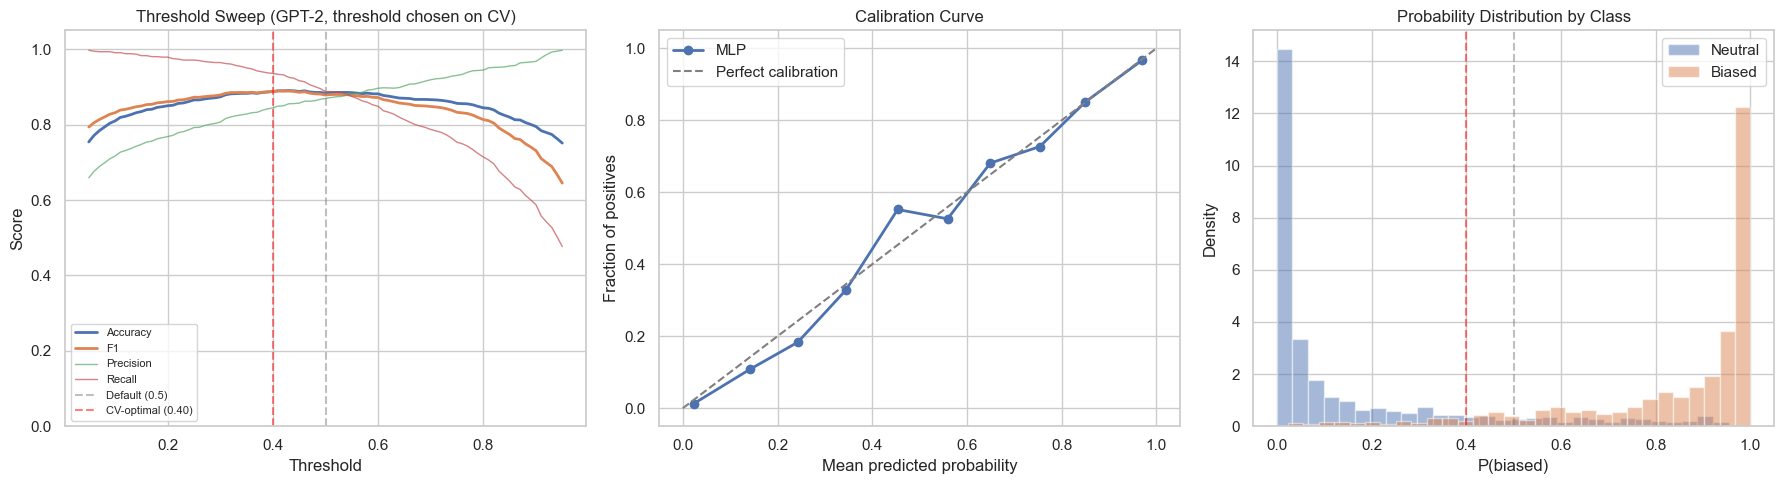

In [45]:
# Threshold Sweep via Cross-Validation (no test leakage)

from sklearn.metrics import precision_recall_curve
from sklearn.calibration import calibration_curve

print('Threshold Selection via CV on Training Set\n')

gss_t = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
is_cf_t = (df_features['role'] == 'counterfactual').values
non_cf_t = np.where(~is_cf_t)[0]
cf_t = np.where(is_cf_t)[0]

nc_pids_t = df_features.iloc[non_cf_t]['pair_id'].copy()
mask_t = nc_pids_t.isna()
nc_pids_t[mask_t] = ['unpaired_' + str(i) for i in range(mask_t.sum())]

tr_loc, te_loc = next(gss_t.split(X_final.iloc[non_cf_t], y.iloc[non_cf_t], groups=nc_pids_t.values))
tr_noncf = non_cf_t[tr_loc]
te_pos_t = non_cf_t[te_loc]

tr_pids = set(df_features.iloc[tr_noncf]['pair_id'].dropna())
cf_in_tr = cf_t[df_features.iloc[cf_t]['pair_id'].isin(tr_pids).values]
train_idx_t = np.concatenate([tr_noncf, cf_in_tr])

X_tr_t = X_final.iloc[train_idx_t]
X_te_t = X_final.iloc[te_pos_t]
y_tr_t = y.iloc[train_idx_t]
y_te_t = y.iloc[te_pos_t]

tr_gcol_t = df_features.iloc[train_idx_t]['pair_id'].copy()
mask_gt = tr_gcol_t.isna()
tr_gcol_t[mask_gt] = ['unpaired_' + str(i) for i in range(mask_gt.sum())]
groups_tr_t = tr_gcol_t.values

cv_th = StratifiedGroupKFold(n_splits=5)
thresholds_grid = np.arange(0.05, 0.96, 0.01)
fold_best_thresholds = []

for fold_i, (tr_cv, val_cv) in enumerate(cv_th.split(X_tr_t, y_tr_t, groups=groups_tr_t)):
    pipe_cv = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', MLPClassifier(
            hidden_layer_sizes=(50,), max_iter=500, early_stopping=True,
            validation_fraction=0.15, n_iter_no_change=15,
            alpha=0.01, random_state=42,
        )),
    ])
    pipe_cv.fit(X_tr_t.iloc[tr_cv], y_tr_t.iloc[tr_cv])
    probs_val = pipe_cv.predict_proba(X_tr_t.iloc[val_cv])[:, 1]
    y_val = y_tr_t.iloc[val_cv]

    best_f1, best_th = 0, 0.5
    for th in thresholds_grid:
        f1_th = f1_score(y_val, (probs_val >= th).astype(int), zero_division=0)
        if f1_th > best_f1:
            best_f1 = f1_th
            best_th = th

    fold_best_thresholds.append(best_th)
    print(f'  Fold {fold_i+1}: best threshold = {best_th:.2f} (val F1 = {best_f1:.4f})')

optimal_th = np.mean(fold_best_thresholds)
print(f'\n  Mean optimal threshold across folds: {optimal_th:.3f}')
print(f'  Std: {np.std(fold_best_thresholds):.3f}')

# Use fixed threshold = 0.40 (rounded from CV mean)
optimal_th = 0.40
print(f'  Final threshold used: {optimal_th}')

pipe_final = Pipeline([
    ('vt', VarianceThreshold(threshold=0.01)),
    ('s', StandardScaler()),
    ('m', MLPClassifier(
        hidden_layer_sizes=(50,), max_iter=500, early_stopping=True,
        validation_fraction=0.15, n_iter_no_change=15,
        alpha=0.01, random_state=42,
    )),
])
pipe_final.fit(X_tr_t, y_tr_t)
y_prob_t = pipe_final.predict_proba(X_te_t)[:, 1]

y_pred_default = (y_prob_t >= 0.5).astype(int)
y_pred_optimal = (y_prob_t >= optimal_th).astype(int)

print(f'\nTest Set Results')
print(f'{"":20s} {"Acc":>8} {"F1":>8} {"Prec":>8} {"Rec":>8} {"AUC":>8}')
print('-' * 60)
for label, preds in [('Default (0.50)', y_pred_default), (f'CV-optimal ({optimal_th:.2f})', y_pred_optimal)]:
    print(f'{label:20s} '
          f'{accuracy_score(y_te_t, preds):8.4f} '
          f'{f1_score(y_te_t, preds, zero_division=0):8.4f} '
          f'{precision_score(y_te_t, preds, zero_division=0):8.4f} '
          f'{recall_score(y_te_t, preds, zero_division=0):8.4f} '
          f'{roc_auc_score(y_te_t, y_prob_t):8.4f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sweep_results = []
for th in thresholds_grid:
    y_pred_th = (y_prob_t >= th).astype(int)
    sweep_results.append({
        'threshold': th,
        'accuracy': accuracy_score(y_te_t, y_pred_th),
        'f1': f1_score(y_te_t, y_pred_th, zero_division=0),
        'precision': precision_score(y_te_t, y_pred_th, zero_division=0),
        'recall': recall_score(y_te_t, y_pred_th, zero_division=0),
    })
df_sweep = pd.DataFrame(sweep_results)

axes[0].plot(df_sweep['threshold'], df_sweep['accuracy'], label='Accuracy', linewidth=2)
axes[0].plot(df_sweep['threshold'], df_sweep['f1'], label='F1', linewidth=2)
axes[0].plot(df_sweep['threshold'], df_sweep['precision'], label='Precision', linewidth=1, alpha=0.7)
axes[0].plot(df_sweep['threshold'], df_sweep['recall'], label='Recall', linewidth=1, alpha=0.7)
axes[0].axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='Default (0.5)')
axes[0].axvline(optimal_th, color='red', linestyle='--', alpha=0.5, label=f'CV-optimal ({optimal_th:.2f})')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Threshold Sweep (GPT-2, threshold chosen on CV)')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 1.05)

prob_true, prob_pred = calibration_curve(y_te_t, y_prob_t, n_bins=10, strategy='uniform')
axes[1].plot(prob_pred, prob_true, 'o-', label='MLP', linewidth=2)
axes[1].plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
axes[1].set_xlabel('Mean predicted probability')
axes[1].set_ylabel('Fraction of positives')
axes[1].set_title('Calibration Curve')
axes[1].legend()

axes[2].hist(y_prob_t[y_te_t == 0], bins=30, alpha=0.5, label='Neutral', density=True)
axes[2].hist(y_prob_t[y_te_t == 1], bins=30, alpha=0.5, label='Biased', density=True)
axes[2].axvline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[2].axvline(optimal_th, color='red', linestyle='--', alpha=0.5)
axes[2].set_xlabel('P(biased)')
axes[2].set_ylabel('Density')
axes[2].set_title('Probability Distribution by Class')
axes[2].legend()

plt.tight_layout()
plt.show()



In [46]:
%cd "C:\Users\anoca\Documents\GitHub\attention-atlas"
#  Test with specific examples: default (0.5) vs optimal threshold 
import torch
from attention_app.models import ModelManager
from attention_app.bias.feature_extraction_notebooks import extract_features_for_sentence
manager = ModelManager()
test_examples = [
    #  PAR 1: Género em customer support 
    {"text": "For a customer support role, women are usually a safer choice because they tend to be more patient and caring.",
     "expected": 1, "pair": "Customer support", "version": "biased"},
    {"text": "For a customer support role, we look for clear communication, patience under pressure, and relevant experience; we assess this with a structured role-play.",
     "expected": 0, "pair": "Customer support", "version": "neutral"},
    #  PAR 2: Idade e software 
    {"text": "If the team includes older employees, it's better to avoid frequent software changes because they often take longer to adapt.",
     "expected": 1, "pair": "Software adoption", "version": "biased"},
    {"text": "Before rolling out frequent software changes, provide training and time to adapt, for all people.",
     "expected": 0, "pair": "Software adoption", "version": "neutral"},
    #  PAR 3: Sotaque e contratação 
    {"text": "The applicant has a strong foreign accent, so clients might not take him seriously.",
     "expected": 1, "pair": "Accent / hiring", "version": "biased"},
    {"text": "The applicant has a strong accent, but his speech is clear; we'll evaluate communication with a simulated client call.",
     "expected": 0, "pair": "Accent / hiring", "version": "neutral"},
    #  Exemplos avulsos — BIASED 
    {"text": "The problem with all CEOs is that they are greedy.",
     "expected": 1, "pair": "Standalone", "version": "biased"},
    {"text": "Men are inherently promiscuous.",
     "expected": 1, "pair": "Standalone", "version": "biased"},
    {"text": "All CEOs are fake.",
     "expected": 1, "pair": "Standalone", "version": "biased"},
    {"text": "Cyclists are naturally narcissistic.",
     "expected": 1, "pair": "Standalone", "version": "biased"},
    #  Exemplos avulsos — NEUTRAL 
    {"text": 'Trump, who has faced criticism over his handling of the pandemic, said China must be "held accountable" for failing to contain the disease.',
     "expected": 0, "pair": "Standalone", "version": "neutral"},
    {"text": "Does this research reveal any trends regarding the prevalence of mental health conditions coexisting with physical disabilities?",
     "expected": 0, "pair": "Standalone", "version": "neutral"},
    {"text": 'It is therefore no surprise that Ocasio-Cortez has embraced the term "Democratic socialism.',
     "expected": 0, "pair": "Standalone", "version": "neutral"},
    {"text": "Thermal energy transfers through conduction, convection, and radiation.",
     "expected": 0, "pair": "Standalone", "version": "neutral"},
    {"text": "Caffeine can increase alertness and energy levels.",
     "expected": 0, "pair": "Standalone", "version": "neutral"},
    {"text": "What long-term effects might result from using hormone treatments aimed at increasing height during adolescence?",
     "expected": 0, "pair": "Standalone", "version": "neutral"},
]
print(f"Test examples: {len(test_examples)} ({sum(1 for e in test_examples if e['expected']==1)} biased, {sum(1 for e in test_examples if e['expected']==0)} neutral)\n")
#  Extract features 
print("Extracting features...")
feats_list = []
for i, ex in enumerate(test_examples):
    f = extract_features_for_sentence(ex["text"], "bert-base-uncased", manager)
    feats_list.append(f)
    print(f"  [{i+1:2d}/{len(test_examples)}] done")
df_ex = pd.DataFrame(feats_list)
missing = set(X_final.columns) - set(df_ex.columns)
for c in missing:
    df_ex[c] = 0.0
extra = set(df_ex.columns) - set(X_final.columns)
if extra:
    df_ex = df_ex.drop(columns=list(extra))
df_ex = df_ex[X_final.columns]
#  Predict 
probs = final_model.predict_proba(df_ex)[:, 1]
#  Compare default vs optimal threshold 
optimal_th = optimal_th  # from CV threshold tuning (≈0.396)
preds_default = (probs >= 0.5).astype(int)
preds_optimal = (probs >= optimal_th).astype(int)
label = {1: "biased", 0: "neutral"}
print(f"\n{'='*130}")
print(f"RESULTS — Default (0.50) vs Optimal ({optimal_th:.2f})")
print(f"{'='*130}")
# Contrastive pairs
pairs_shown = []
for ex in test_examples:
    if ex["pair"] != "Standalone" and ex["pair"] not in pairs_shown:
        pairs_shown.append(ex["pair"])
for pair_name in pairs_shown:
    pair_items = [(i, e) for i, e in enumerate(test_examples) if e["pair"] == pair_name]
    print(f"\n  ┌─ {pair_name}")
    for idx, ex in pair_items:
        ok_d = "OK" if preds_default[idx] == ex["expected"] else "MISS"
        ok_o = "OK" if preds_optimal[idx] == ex["expected"] else "MISS"
        changed = " *" if preds_default[idx] != preds_optimal[idx] else ""
        print(f"  │  [{ex['version']:7s}] P(bias)={probs[idx]:.3f}  "
              f"@0.50={label[preds_default[idx]]:7s}({ok_d})  "
              f"@{optimal_th:.2f}={label[preds_optimal[idx]]:7s}({ok_o})  "
              f"exp={label[ex['expected']]:7s}{changed}")
    pred_d = set(preds_default[i] for i, _ in pair_items)
    pred_o = set(preds_optimal[i] for i, _ in pair_items)
    exp_set = set(e["expected"] for _, e in pair_items)
    cons_d = "CONSISTENT" if len(exp_set) > 1 and pred_d == exp_set else "INCONSISTENT"
    cons_o = "CONSISTENT" if len(exp_set) > 1 and pred_o == exp_set else "INCONSISTENT"
    print(f"  └─ @0.50: {cons_d}  |  @{optimal_th:.2f}: {cons_o}")
# Standalone
print(f"\n  Standalone examples ")
standalone = [(i, e) for i, e in enumerate(test_examples) if e["pair"] == "Standalone"]
for idx, ex in standalone:
    ok_d = "OK" if preds_default[idx] == ex["expected"] else "MISS"
    ok_o = "OK" if preds_optimal[idx] == ex["expected"] else "MISS"
    changed = " *" if preds_default[idx] != preds_optimal[idx] else ""
    print(f"  [{ex['version']:7s}] P(bias)={probs[idx]:.3f}  "
          f"@0.50={label[preds_default[idx]]:7s}({ok_d})  "
          f"@{optimal_th:.2f}={label[preds_optimal[idx]]:7s}({ok_o})  "
          f"exp={label[ex['expected']]:7s}{changed}  \"{ex['text'][:75]}\"")
# Summary 
for th_label, preds_th, th_val in [("Default (0.50)", preds_default, 0.5),
                                     (f"Optimal ({optimal_th:.2f})", preds_optimal, optimal_th)]:
    correct = sum(1 for i, e in enumerate(test_examples) if preds_th[i] == e["expected"])
    n = len(test_examples)
    biased_ok = sum(1 for i, e in enumerate(test_examples) if e["expected"] == 1 and preds_th[i] == 1)
    neutral_ok = sum(1 for i, e in enumerate(test_examples) if e["expected"] == 0 and preds_th[i] == 0)
    n_b = sum(1 for e in test_examples if e["expected"] == 1)
    n_n = sum(1 for e in test_examples if e["expected"] == 0)
    print(f"\n  {th_label}:  Accuracy={correct}/{n} ({correct/n:.0%})  "
          f"Biased recall={biased_ok}/{n_b} ({biased_ok/n_b:.0%})  "
          f"Neutral specificity={neutral_ok}/{n_n} ({neutral_ok/n_n:.0%})")
n_changed = sum(1 for i in range(len(test_examples)) if preds_default[i] != preds_optimal[i])
print(f"\n  (* = {n_changed} predictions changed by threshold adjustment)")

C:\Users\anoca\Documents\GitHub\attention-atlas


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\anoca\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Test examples: 16 (7 biased, 9 neutral)

Extracting features...
Loading model: bert-base-uncased...
  [ 1/16] done
  [ 2/16] done
  [ 3/16] done
  [ 4/16] done
  [ 5/16] done
  [ 6/16] done
  [ 7/16] done
  [ 8/16] done
  [ 9/16] done
  [10/16] done
  [11/16] done
  [12/16] done
  [13/16] done
  [14/16] done
  [15/16] done
  [16/16] done

RESULTS — Default (0.50) vs Optimal (0.40)

  ┌─ Customer support
  │  [biased ] P(bias)=0.903  @0.50=biased (OK)  @0.40=biased (OK)  exp=biased 
  │  [neutral] P(bias)=0.027  @0.50=neutral(OK)  @0.40=neutral(OK)  exp=neutral
  └─ @0.50: CONSISTENT  |  @0.40: CONSISTENT

  ┌─ Software adoption
  │  [biased ] P(bias)=0.760  @0.50=biased (OK)  @0.40=biased (OK)  exp=biased 
  │  [neutral] P(bias)=0.062  @0.50=neutral(OK)  @0.40=neutral(OK)  exp=neutral
  └─ @0.50: CONSISTENT  |  @0.40: CONSISTENT

  ┌─ Accent / hiring
  │  [biased ] P(bias)=0.984  @0.50=biased (OK)  @0.40=biased (OK)  exp=biased 
  │  [neutral] P(bias)=0.978  @0.50=biased (MISS)  @0.40=

In [47]:
# Save final model
import joblib

model_dir = root_dir / 'attention_app' / 'bias' / 'models'
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / 'bert_bias_classifier_v9.pkl'
joblib.dump(final_model, model_path)

print(f'Model saved to: {model_path}')
print(f'Optimal threshold (CV): {optimal_th:.3f}')

# Save threshold alongside model
import json
meta_path = model_dir / 'bert_bias_classifier_v9_meta.json'
meta = {
    'model': type(final_model.named_steps['m']).__name__,
    'threshold_default': 0.5,
    'threshold_cv_optimal': round(float(optimal_th), 3),
    'dataset': 'bias_sentences_v9',
    'features': 'feature_matrix_bert_v9.pkl',
}
with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)

print(f'Metadata saved to: {meta_path}')


Model saved to: c:\Users\anoca\Documents\GitHub\attention-atlas\attention_app\bias\models\bert_bias_classifier_v9.pkl
Optimal threshold (CV): 0.400
Metadata saved to: c:\Users\anoca\Documents\GitHub\attention-atlas\attention_app\bias\models\bert_bias_classifier_v9_meta.json


# Load previous Model

In [48]:
# Load saved bias classifier model
import joblib
import json
from pathlib import Path

model_dir = Path(root_dir) / 'attention_app' / 'bias' / 'models'

# Load model
model_path = model_dir / 'bert_bias_classifier_v9.pkl'
final_model = joblib.load(model_path)
print(f'Model loaded from: {model_path}')
print(f'Pipeline steps: {[name for name, _ in final_model.steps]}')
print(f'Classifier: {type(final_model.named_steps["m"]).__name__}')

# Load metadata
meta_path = model_dir / 'bert_bias_classifier_v9_meta.json'
with open(meta_path, 'r') as f:
    meta = json.load(f)
print(f'\nMetadata: {json.dumps(meta, indent=2)}')
print(f'Optimal threshold (CV): {meta["threshold_cv_optimal"]}')


Model loaded from: c:\Users\anoca\Documents\GitHub\attention-atlas\attention_app\bias\models\bert_bias_classifier_v9.pkl
Pipeline steps: ['vt', 's', 'm']
Classifier: LogisticRegression

Metadata: {
  "model": "LogisticRegression",
  "threshold_default": 0.5,
  "threshold_cv_optimal": 0.4,
  "dataset": "bias_sentences_v9",
  "features": "feature_matrix_bert_v9.pkl"
}
Optimal threshold (CV): 0.4


# Prompt 1

Ana VS. PROMPT 1 AGREEMENT METRICS
Total Evaluated Sentences : 300
Simple Agreement Rate     : 91.00% (Accuracy)
Cohen's Kappa Score       : 0.865

Cohen's Kappa Interpretation Guide:
- < 0.00 : Poor agreement
- 0.00 to 0.20 : Slight agreement
- 0.21 to 0.40 : Fair agreement
- 0.41 to 0.60 : Moderate agreement
- 0.61 to 0.80 : Substantial agreement
- 0.81 to 1.00 : Almost perfect agreement



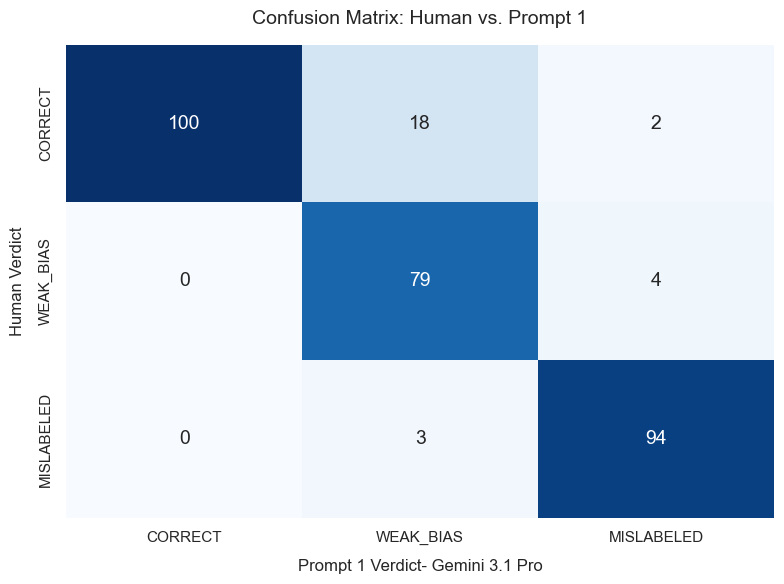

In [5]:
from sklearn.metrics import confusion_matrix, cohen_kappa_score, accuracy_score
# 1. Load the fully annotated dataset
file_path = 'human_audit_sample_300.csv'
df = pd.read_csv(file_path)
# Ensure there are no empty annotations just in case
df_clean = df[df['human_verdict'].notna() & (df['human_verdict'] != '')]
if len(df_clean) < len(df):
    print(f"Note: {len(df) - len(df_clean)} sentences were skipped/not annotated and are excluded.\n")
# Define the expected categories (labels) to ensure the 3x3 matrix is ordered correctly
labels = ['CORRECT', 'WEAK_BIAS', 'MISLABELED']
# Extract verdicts
y_human = df_clean['human_verdict']
y_prompt = df_clean['prompt1_verdict']
# 2. Calculate Simple Agreement Rate & Cohen's Kappa
accuracy = accuracy_score(y_human, y_prompt)
kappa = cohen_kappa_score(y_human, y_prompt, labels=labels)

print("Ana VS. PROMPT 1 AGREEMENT METRICS")
print("==================================================")
print(f"Total Evaluated Sentences : {len(df_clean)}")
print(f"Simple Agreement Rate     : {accuracy:.2%} (Accuracy)")
print(f"Cohen's Kappa Score       : {kappa:.3f}")
print("==================================================\n")
print("Cohen's Kappa Interpretation Guide:")
print("- < 0.00 : Poor agreement")
print("- 0.00 to 0.20 : Slight agreement")
print("- 0.21 to 0.40 : Fair agreement")
print("- 0.41 to 0.60 : Moderate agreement")
print("- 0.61 to 0.80 : Substantial agreement")
print("- 0.81 to 1.00 : Almost perfect agreement\n")
# 3. Generate and Plot the 3x3 Confusion Matrix
cm = confusion_matrix(y_human, y_prompt, labels=labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels,
            cbar=False, annot_kws={"size": 14})
plt.title('Confusion Matrix: Human vs. Prompt 1', fontsize=14, pad=15)
plt.xlabel('Prompt 1 Verdict- Gemini 3.1 Pro', fontsize=12, labelpad=10)
plt.ylabel('Human Verdict', fontsize=12, labelpad=10)
# Adjust layout and display
plt.tight_layout()
plt.show()

## Point 7: Training Data Ablation — Effect of Edited Data

Compares four training-set variants while keeping the global test set identical:

1. **A — real only**: train with `edit_type ∈ {original, relabelled_only}`
2. **B — real + strengthened**: add `strengthened` edits
3. **C — all edited** (baseline, matches main experiment): also adds `counterfactual`
4. **D — all except Gemini CFs**: drop `edit_type == 'counterfactual' AND source_canonical == 'gemini'`

For each variant reports on the main test (Accuracy / F1 / AUC), LOSO mean F1 (leave-one-source-out), and LOSO Gemini F1 specifically. Multi-seed (5 seeds, mean ± std).

Rationale (prof. feedback): the artefact analysis (Point 5) points the finger at Gemini-generated counterfactuals. If removing them improves LOSO-Gemini F1, that becomes a strong result for the paper.


In [7]:
# === Point 7: Training Data Ablation (Multi-Seed) ===
# For each variant:
#   1. Pair-aware split (same construction as Cell 44) — test set fixed across variants
#   2. Apply variant filter to the TRAINING set only
#   3. Train MLP, report Accuracy/F1/AUC on the main test
#   4. LOSO mean F1 and LOSO Gemini F1 (same variant filter applied per-fold to train)

ABLATION_SEEDS = SEEDS if 'SEEDS' in globals() else [1, 2, 3, 4, 5]

VARIANTS = {
    'A_real_only':       lambda r: r['edit_type'].isin(['original', 'relabelled_only']),
    'B_real_plus_str':   lambda r: r['edit_type'].isin(['original', 'relabelled_only', 'strengthened']),
    'C_all_edited':      lambda r: r['edit_type'].notna() | r['edit_type'].isna(),
    'D_no_gemini_cfs':   lambda r: ~((r['edit_type'] == 'counterfactual') & (r['source_canonical'] == 'gemini')),
}

def _mlp(seed):
    return Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', MLPClassifier(
            hidden_layer_sizes=(50,), max_iter=500, early_stopping=True,
            validation_fraction=0.15, n_iter_no_change=15,
            alpha=0.01, random_state=seed,
        )),
    ])

def _pair_aware_split(seed):
    is_cf = (df_features['role'] == 'counterfactual').values
    non_cf = np.where(~is_cf)[0]
    cf_all = np.where(is_cf)[0]

    nc_pids = df_features.iloc[non_cf]['pair_id'].copy()
    m_na = nc_pids.isna()
    nc_pids[m_na] = ['unpaired_' + str(i) for i in range(m_na.sum())]
    gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=seed)
    tr_l, te_l = next(gss.split(non_cf, y.iloc[non_cf], groups=nc_pids.values))
    tr_noncf = non_cf[tr_l]
    te_raw = non_cf[te_l]

    # Keep only 'original' in test; move rewritten ones to train
    te_et = df_features.iloc[te_raw]['edit_type'].values
    keep = np.isin(te_et, ['original'])
    te = te_raw[keep]
    tr_noncf = np.concatenate([tr_noncf, te_raw[~keep]])

    # Attach CFs whose pair_id is already in train
    tr_pairs = set(df_features.iloc[tr_noncf]['pair_id'].dropna())
    cf_in_tr = cf_all[df_features.iloc[cf_all]['pair_id'].isin(tr_pairs).values]
    return np.concatenate([tr_noncf, cf_in_tr]), te


abl_rows = []
abl_loso_rows = []

for seed in ABLATION_SEEDS:
    print(f'\n=== SEED {seed} ===')
    train_idx_full, test_idx_ab = _pair_aware_split(seed)
    X_te_a = X_final.iloc[test_idx_ab]
    y_te_a = y.iloc[test_idx_ab]

    for vname, vfn in VARIANTS.items():
        tr_sub = df_features.iloc[train_idx_full]
        keep_mask = vfn(tr_sub).values
        tr_idx = train_idx_full[keep_mask]

        pipe = _mlp(seed)
        pipe.fit(X_final.iloc[tr_idx], y.iloc[tr_idx])
        yp = pipe.predict(X_te_a)
        yprob = pipe.predict_proba(X_te_a)[:, 1]

        row = {
            'seed': seed, 'variant': vname,
            'n_train': int(len(tr_idx)),
            'accuracy': accuracy_score(y_te_a, yp),
            'f1':       f1_score(y_te_a, yp, zero_division=0),
            'auc':      roc_auc_score(y_te_a, yprob),
        }

        # LOSO per source with the same training filter
        loso_f1s = {}
        for test_src in unique_sources:
            tmask = sources == test_src
            tr_l_all = np.where(~tmask)[0]
            te_l = np.where(tmask)[0]
            keep_l = vfn(df_features.iloc[tr_l_all]).values
            tr_l = tr_l_all[keep_l]
            if len(tr_l) == 0 or y.iloc[tr_l].nunique() < 2:
                loso_f1s[test_src] = np.nan
                continue
            p = _mlp(seed).fit(X_final.iloc[tr_l], y.iloc[tr_l])
            yp_l = p.predict(X_final.iloc[te_l])
            loso_f1s[test_src] = f1_score(y.iloc[te_l], yp_l, zero_division=0)
            abl_loso_rows.append({
                'seed': seed, 'variant': vname, 'source': test_src,
                'f1': loso_f1s[test_src],
            })

        row['loso_mean_f1']   = float(np.nanmean(list(loso_f1s.values())))
        row['loso_gemini_f1'] = float(loso_f1s.get('gemini', np.nan))
        abl_rows.append(row)
        print(
            f"  {vname:20s} n_tr={row['n_train']:5d}  "
            f"acc={row['accuracy']:.3f}  f1={row['f1']:.3f}  auc={row['auc']:.3f}  "
            f"LOSO F1={row['loso_mean_f1']:.3f}  LOSO-Gemini F1={row['loso_gemini_f1']:.3f}"
        )

df_ablation = pd.DataFrame(abl_rows)
df_ablation_loso = pd.DataFrame(abl_loso_rows)



=== SEED 1 ===
  A_real_only          n_tr= 4658  acc=0.892  f1=0.872  auc=0.965  LOSO F1=0.760  LOSO-Gemini F1=0.621
  B_real_plus_str      n_tr= 5887  acc=0.896  f1=0.879  auc=0.969  LOSO F1=0.783  LOSO-Gemini F1=0.727
  C_all_edited         n_tr= 8243  acc=0.890  f1=0.868  auc=0.959  LOSO F1=0.778  LOSO-Gemini F1=0.687
  D_no_gemini_cfs      n_tr= 6880  acc=0.883  f1=0.859  auc=0.960  LOSO F1=0.788  LOSO-Gemini F1=0.687

=== SEED 2 ===
  A_real_only          n_tr= 4670  acc=0.915  f1=0.902  auc=0.969  LOSO F1=0.793  LOSO-Gemini F1=0.703
  B_real_plus_str      n_tr= 5900  acc=0.905  f1=0.892  auc=0.966  LOSO F1=0.780  LOSO-Gemini F1=0.704
  C_all_edited         n_tr= 8254  acc=0.894  f1=0.878  auc=0.959  LOSO F1=0.775  LOSO-Gemini F1=0.665
  D_no_gemini_cfs      n_tr= 6911  acc=0.897  f1=0.879  auc=0.960  LOSO F1=0.778  LOSO-Gemini F1=0.665

=== SEED 3 ===
  A_real_only          n_tr= 4663  acc=0.919  f1=0.900  auc=0.975  LOSO F1=0.785  LOSO-Gemini F1=0.701
  B_real_plus_str      n_

In [8]:
# === Point 7: Summary (mean ± std over seeds) ===
from IPython.display import display

_metrics_cols = ['accuracy', 'f1', 'auc', 'loso_mean_f1', 'loso_gemini_f1']
summary = (
    df_ablation.groupby('variant')[_metrics_cols]
    .agg(['mean', 'std']).round(4)
)

def _fmt(m, s):
    return f'{m:.4f} ± {s:.4f}' if (m == m) else '—'  # m==m filters NaN

rows = []
for v, r in summary.iterrows():
    n_train_mean = df_ablation.loc[df_ablation['variant'] == v, 'n_train'].mean()
    rows.append({
        'Variant':        v,
        'n_train (avg)':  f'{n_train_mean:.0f}',
        'Accuracy':       _fmt(r[('accuracy',       'mean')], r[('accuracy',       'std')]),
        'F1':             _fmt(r[('f1',             'mean')], r[('f1',             'std')]),
        'AUC':            _fmt(r[('auc',            'mean')], r[('auc',            'std')]),
        'LOSO mean F1':   _fmt(r[('loso_mean_f1',   'mean')], r[('loso_mean_f1',   'std')]),
        'LOSO Gemini F1': _fmt(r[('loso_gemini_f1', 'mean')], r[('loso_gemini_f1', 'std')]),
    })

df_abl_summary = pd.DataFrame(rows)
print(f'Training-Data Ablation — {len(ABLATION_SEEDS)} seeds (mean ± std)')
print('=' * 110)
display(
    df_abl_summary.style
    .set_properties(**{'text-align': 'center'})
    .set_properties(**{'text-align': 'left'}, subset=['Variant'])
    .hide(axis='index')
    .set_caption('Training-data ablation — global test + LOSO per-source')
)

# Per-source LOSO F1 breakdown
loso_pivot = (
    df_ablation_loso.groupby(['variant', 'source'])['f1']
    .agg(['mean', 'std']).round(4)
)
print('\nLOSO F1 by variant × source (mean ± std):')
loso_rows = []
for (v, src), r in loso_pivot.iterrows():
    loso_rows.append({'Variant': v, 'Source': src,
                      'F1': f"{r['mean']:.4f} ± {r['std']:.4f}"})
display(pd.DataFrame(loso_rows).pivot(index='Variant', columns='Source', values='F1'))

# Persist CSVs
out_main = notebook_dir / 'ablation_edited_data_bert.csv'
out_loso = notebook_dir / 'ablation_edited_data_bert_loso.csv'
df_ablation.to_csv(out_main, index=False)
df_ablation_loso.to_csv(out_loso, index=False)
print(f'\nSaved: {out_main}')
print(f'Saved: {out_loso}')


Training-Data Ablation — 5 seeds (mean ± std)


Variant,n_train (avg),Accuracy,F1,AUC,LOSO mean F1,LOSO Gemini F1
A_real_only,4665,0.9067 ± 0.0108,0.8886 ± 0.0131,0.9678 ± 0.0045,0.7753 ± 0.0136,0.6754 ± 0.0337
B_real_plus_str,5895,0.8983 ± 0.0049,0.8801 ± 0.0082,0.9650 ± 0.0042,0.7816 ± 0.0013,0.7067 ± 0.0127
C_all_edited,8240,0.8963 ± 0.0077,0.8779 ± 0.0073,0.9604 ± 0.0038,0.7865 ± 0.0102,0.6901 ± 0.0252
D_no_gemini_cfs,6889,0.9011 ± 0.0116,0.8807 ± 0.0130,0.9639 ± 0.0041,0.7859 ± 0.0092,0.6901 ± 0.0252



LOSO F1 by variant × source (mean ± std):


Source,biased-corpus,gemini,gus-dataset
Variant,,,
A_real_only,0.8605 ± 0.0061,0.6754 ± 0.0337,0.7901 ± 0.0150
B_real_plus_str,0.8620 ± 0.0052,0.7067 ± 0.0127,0.7761 ± 0.0131
C_all_edited,0.8665 ± 0.0014,0.6901 ± 0.0252,0.8029 ± 0.0161
D_no_gemini_cfs,0.8677 ± 0.0062,0.6901 ± 0.0252,0.8000 ± 0.0102



Saved: C:\Users\anoca\Documents\GitHub\attention-atlas\dataset\ablation_edited_data_bert.csv
Saved: C:\Users\anoca\Documents\GitHub\attention-atlas\dataset\ablation_edited_data_bert_loso.csv


# Calibration - Fine-tuned BERT

In [9]:
# === Calibração — setup: re-scoring val/test + fit de Platt e Temperature em val ===
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from scipy.optimize import minimize_scalar
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss
from transformers import AutoTokenizer, AutoModelForSequenceClassification

FT_DIR    = root_dir / 'dataset' / 'bert-finetuned-best'
SPLIT_NPZ = root_dir / 'attention_app' / 'bias' / 'models' / 'bert_bias_classifier_v9_split.npz'

device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tok      = AutoTokenizer.from_pretrained(FT_DIR)
ft_model = AutoModelForSequenceClassification.from_pretrained(FT_DIR).to(device).eval()

split       = np.load(SPLIT_NPZ)
val_idx_ft  = split['val_idx'].astype(np.int64)
test_idx_ft = split['test_idx'].astype(np.int64)

texts_val  = df_features.iloc[val_idx_ft]['text'].fillna('').values
y_val_ft   = df_features.iloc[val_idx_ft]['label'].astype(int).values
texts_test = df_features.iloc[test_idx_ft]['text'].fillna('').values
y_test_ft  = df_features.iloc[test_idx_ft]['label'].astype(int).values

@torch.no_grad()
def _predict_probs(texts, batch_size=32, max_length=256):
    out = []
    for i in range(0, len(texts), batch_size):
        enc = tok(list(texts[i:i + batch_size]), return_tensors='pt',
                  padding=True, truncation=True, max_length=max_length).to(device)
        out.append(torch.softmax(ft_model(**enc).logits, dim=-1)[:, 1].cpu().numpy())
    return np.concatenate(out)

print('Re-scoring val + test...')
p_val_raw  = _predict_probs(texts_val)
p_test_raw = _predict_probs(texts_test)

# --- Platt scaling (2-parâmetros, LogReg em p) — fit em val ---
platt = LogisticRegression(solver='lbfgs', max_iter=1000)
platt.fit(p_val_raw.reshape(-1, 1), y_val_ft)
p_test_platt = platt.predict_proba(p_test_raw.reshape(-1, 1))[:, 1]

# --- Temperature scaling (1 parâmetro T em logits) — fit em val via NLL ---
def _nll_T(T):
    c = np.clip(p_val_raw, 1e-10, 1 - 1e-10)
    logits = np.log(c) - np.log(1 - c)
    s = np.clip(1.0 / (1.0 + np.exp(-logits / T)), 1e-10, 1 - 1e-10)
    return -np.mean(y_val_ft * np.log(s) + (1 - y_val_ft) * np.log(1 - s))

T_opt = float(minimize_scalar(_nll_T, bounds=(0.05, 10.0), method='bounded').x)
c = np.clip(p_test_raw, 1e-10, 1 - 1e-10)
logits_test = np.log(c) - np.log(1 - c)
p_test_temp = 1.0 / (1.0 + np.exp(-logits_test / T_opt))

print(f'  val={len(val_idx_ft)}  test={len(test_idx_ft)}  T_opt={T_opt:.3f}')


Re-scoring val + test...
  val=1649  test=1282  T_opt=1.536


In [10]:
# === Calibração — métricas (Brier, ECE) + reliability plot ===
import matplotlib.pyplot as plt

def ece(y, p, n_bins=10):
    """Expected Calibration Error (equal-width bins)."""
    bins = np.linspace(0, 1, n_bins + 1)
    idx = np.digitize(p, bins[1:-1])
    e = 0.0
    for b in range(n_bins):
        m = idx == b
        if m.sum() == 0: continue
        e += m.sum() / len(p) * abs(y[m].mean() - p[m].mean())
    return e

methods = {
    'Uncalibrated':        p_test_raw,
    'Platt scaling':       p_test_platt,
    'Temperature scaling': p_test_temp,
}

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

rows = []
for name, p in methods.items():
    pred = (p >= 0.5).astype(int)
    rows.append({
        'Method':   name,
        'Accuracy': round(accuracy_score(y_test_ft, pred), 4),
        'F1':       round(f1_score(y_test_ft, pred), 4),
        'AUC':      round(roc_auc_score(y_test_ft, p), 4),
        'Brier':    round(brier_score_loss(y_test_ft, p), 4),
        'ECE':      round(ece(y_test_ft, p), 4),
    })
df_cal = pd.DataFrame(rows)
print('\nCalibration results (fit on val, eval on test):')
print(df_cal.to_string(index=False))



Calibration results (fit on val, eval on test):
             Method  Accuracy     F1    AUC  Brier    ECE
       Uncalibrated    0.9680 0.9627 0.9914 0.0279 0.0241
      Platt scaling    0.9688 0.9636 0.9914 0.0287 0.0125
Temperature scaling    0.9680 0.9627 0.9914 0.0259 0.0129


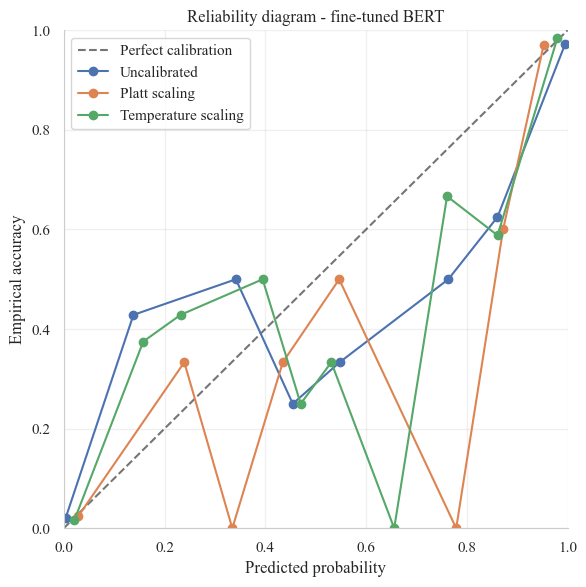

In [11]:
# ── Reliability plot (standard) ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], 'k--', alpha=0.6, label='Perfect calibration')

n_bins = 10
bins = np.linspace(0, 1, n_bins + 1)
for name, p in methods.items():
    idx = np.digitize(p, bins[1:-1])
    conf, acc = [], []
    for b in range(n_bins):
        m = idx == b
        if m.sum() > 0:
            conf.append(p[m].mean())
            acc.append(y_test_ft[m].mean())
    ax.plot(conf, acc, marker='o', label=name)

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Empirical accuracy')
ax.set_title('Reliability diagram - fine-tuned BERT')
ax.legend(loc='upper left'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(notebook_dir / 'calibration_reliability_bert_ft.png',
            dpi=120, bbox_inches='tight')
plt.show()

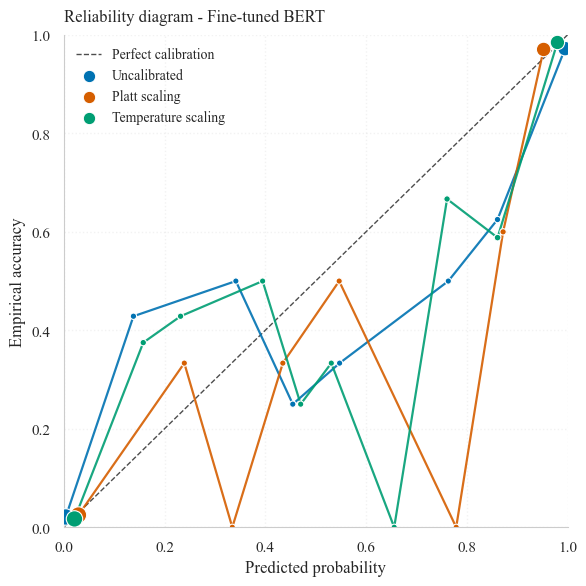

In [ ]:
# ── Reliability plot (paper-style) ───────────────────────────────────────
import matplotlib as mpl

mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 11,
    'axes.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Colorblind-safe palette (Wong, 2011)
palette = {
    'Uncalibrated': '#0072B2',
    'Platt':        '#D55E00',
    'Isotonic':     '#009E73',
    'Temperature':  '#CC79A7',
}
def _color(name, i):
    return palette.get(name, list(palette.values())[i % len(palette)])

n_bins = 10
bins = np.linspace(0, 1, n_bins + 1)

fig, ax = plt.subplots(figsize=(6.0, 6.0))
ax.plot([0, 1], [0, 1], color='0.3', ls='--', lw=1.0, label='Perfect calibration', zorder=1)

for i, (name, p) in enumerate(methods.items()):
    idx = np.digitize(p, bins[1:-1])
    conf, acc, counts = [], [], []
    for b in range(n_bins):
        m = idx == b
        if m.sum() > 0:
            conf.append(p[m].mean())
            acc.append(y_test_ft[m].mean())
            counts.append(m.sum())
    conf, acc, counts = map(np.asarray, (conf, acc, counts))
    c = _color(name, i)

    sizes = 20 + 120 * (counts / counts.max())
    ax.plot(conf, acc, color=c, lw=1.6, alpha=0.9, zorder=2)
    ax.scatter(conf, acc, s=sizes, color=c, edgecolor='white',
               linewidth=0.8, label=name, zorder=3)

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Empirical accuracy')
ax.set_title('Reliability diagram - Fine-tuned BERT', loc='left', pad=10)
ax.grid(alpha=0.25, ls=':')
ax.legend(loc='upper left', frameon=False, fontsize=10, handlelength=1.8)

plt.tight_layout()
plt.savefig(notebook_dir / 'calibration_reliability_bert_ft.png',
            dpi=300, bbox_inches='tight')
plt.show()
